In [1]:
# CELULA 01
# ============================================================================
# SETUP & IMPORTS 
# ============================================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuração de exibição do Pandas
pd.options.display.float_format = '{:,.2f}'.format

def formatar_moeda(valor):
    if isinstance(valor, (int, float)):
        return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return valor

def formatar_pct(valor):
    return f"{valor:.1f}%"

print("✅ Ambiente configurado")
print("📦 Bibliotecas: pandas, numpy, plotly, scipy")
print("🎨 Cores: Movidas para PREMISSAS (Célula 02)")

✅ Ambiente configurado
📦 Bibliotecas: pandas, numpy, plotly, scipy
🎨 Cores: Movidas para PREMISSAS (Célula 02)


In [2]:
# CÉLULA 02 - PREMISSAS V9.0 - PAINEL DE CONTROLE MASTER (HUMAN READABLE)
# ============================================================================
# DOCUMENTAÇÃO E ESTRATÉGIA
# ============================================================================
# CENÁRIO: BOOTSTRAPPING (Validação com Recursos Próprios)
#
# 4. CAPEX: R$ 0,00 (Hardware/PC assumido na Pessoa Física)
#
# REGRAS DE GROWTH:
# 1. Metas são definidas MENSALMENTE.
# 2. A taxa SEMANAL é calculada matematicamente no final desta célula.
# ============================================================================

PREMISSAS = {
    # ========================================================================
    # 1. METADADOS & CONTROLE DE TEMPO
    # ========================================================================
    'meta_version': '9.0-full-documented',
    'meta_updated_at': '2025-12-01',
    
    'data_inicio': '2025-11-01',
    'meses_projecao': 36,       # 3 anos de visão
    'seed_fixa': 42,            # Para reprodutibilidade (Monte Carlo)
    
    # Convenções de Tempo
    'semanas_por_mes': 4.33,
    'meses_por_ano': 12,

    # ========================================================================
    # 2. SAZONALIDADE DO MERCADO (CALENDÁRIO B3)
    # ========================================================================
    # Fator multiplicador sobre o tráfego base.
    # Jan (1.30) é forte (começo de ano), Dez (0.75) é fraco (festas).
    'sazonalidade_trafego': {
        1: 1.30,  2: 1.10,  3: 1.15, 
        4: 1.00,  5: 1.05,  6: 1.00,
        7: 0.85,  8: 1.00,  9: 1.00, 
        10: 1.05, 11: 1.10, 12: 0.75
    },

    # ========================================================================
    # 3. AQUISIÇÃO, GROWTH & METAS
    # ========================================================================
    'usuarios_pagos_iniciais': 5,  # Começamos pequenos
    'trafego_inicial': 300,        # Visitas no site/app
    
    # --- METAS DE CRESCIMENTO MENSAL (DRIVERS) ---
    # A meta semanal será calculada baseada nestes números no final do script.
    'crescimento_trafego_mes_1_6': 0.25,      # 25% ao mês (Fase Validação)
    'crescimento_trafego_mes_7_12': 0.07,     # 7% ao mês (Fase Consolidação)
    'crescimento_trafego_mes_13_plus': 0.04,  # 4% ao mês (Fase Escala)

    # Parâmetros de Mercado
    'mercado_potencial_traders': 150000,        # [usuários] TAM para curva S viral
    
    # Configuração da Validação Semanal
    'semanas_validacao_m0_m6': 26,            # Duração da fase crítica (6 meses)

    # --- FUNIL DE VENDAS ---
    'taxa_visitante_para_trial': 0.05,        # 5% dos visitantes testam
    'taxa_trial_para_pagante': 0.12,          # 12% dos testers pagam
    
    # Eficiência do Time (Ramp-up)
    'ramp_up_inicial': 0.50,                  # Começamos com 50% de eficiência
    'ramp_up_incremento': 0.06,               # Melhora 6% ao mês até 100%
    
    # --- CRESCIMENTO ORGÂNICO (SEO/INDICAÇÃO) ---
    'fator_visitas_organicas_por_pagante': 2.5, # Cada cliente atrai 2.5 visitantes
    'taxa_crescimento_organico_base': 0.02,     # SEO melhora 2% ao mês
    'elasticidade_organico': 0.60,              # Fator de viralidade
    'alerta_dependencia_organica_pct': 50.0,    # Alerta se depender <50% de orgânico

    # ========================================================================
    # 4. CHURN & RETENÇÃO (CANCELAMENTO)
    # ========================================================================
    # Traders trocam muito de plataforma no início.
    'churn_inicial': 0.12,                    # 12% ao mês (Mês 1)
    'churn_maturidade': 0.06,                 # 6% ao mês (Meta Longo Prazo)
    'churn_base': 0.07,                       # Média para cálculos simples
    'churn_decaimento_mensal': 0.0015,        # Melhora 0.15% a cada mês
    'taxa_reativacao_base_cancelada': 0.01,   # 1% dos cancelados voltam

    # ========================================================================
    # 5. PRICING & MIX DE PRODUTOS
    # ========================================================================
    # Preços das Assinaturas
    'preco_lite': 69.90, 
    'preco_trader': 99.90, 
    'preco_pro': 169.90,
    
    # Distribuição dos Clientes (Mix)
    'mix_lite': 0.50,                         # 50% no plano básico
    'mix_trader': 0.35,                       # 35% no intermediário
    'mix_pro': 0.15,                          # 15% no avançado
    'taxa_upgrade_lite_trader': 0.02,         # 2% sobem de plano/mês
    
    # --- MEIOS DE PAGAMENTO ---
    'mix_pagamento_cartao': 0.55, 
    'mix_pagamento_pix': 0.40, 
    'mix_pagamento_boleto': 0.05,
    
    # Custos Financeiros (Taxas)
    'taxa_processamento_cartao': 0.045,       # 4.5%
    'taxa_processamento_pix': 0.01,           # 1.0%
    'taxa_processamento_boleto': 0.035,       # 3.5%
    'taxa_chargeback': 0.005,                 # 0.5% fraude/estorno
    
    # Inadimplência Realista
    'taxa_inadimplencia_cartao': 0.04,
    'taxa_inadimplencia_pix': 0.08,           # Pix agendado que não paga
    'taxa_inadimplencia_boleto': 0.02,
    
    # Regime Tributário
    'imposto_simples_inicial': 0.06,          # 6% (Anexo III)
    'imposto_lucro_presumido': 0.1633,        # 16.33% (Se estourar o teto)
    'threshold_regime_tributario': 4800000.00,# Teto Simples Nacional

    # ========================================================================
    # 6. INFRAESTRUTURA & CUSTOS VARIÁVEIS (TIERS)
    # ========================================================================
    # Custo Variável por Usuário (IA Tokens + Server Load)
    'custo_ia_lite': 2.50, 
    'custo_ia_trader': 4.50, 
    'custo_ia_pro': 13.00,
    
    'custo_ferramentas_base': 1.00,         # Ferramentas fixas (Jira, etc), já está nos custos de ferramentas do tier 1!!!
    'custo_suporte_por_1000_users': 1.00,   # Zendesk variável - não tem agoagora eu o fundador vou dar suporte e vou automatizar!!!
    
    # Limites para Mudança de Tier (Escalabilidade)
    'infra_tier_1_limite': 500,
    'infra_tier_2_limite': 1500,
    'infra_tier_3_limite': 5000,
    'infra_tier_4_limite': 10000,

    # --- TIER 1: VALIDAÇÃO (0 - 500 usuários) ---
    't1_vps_app_api': 120.00, 
    't1_vps_windows_mt5': 180.00, 
    't1_database_managed': 80.00,
    't1_storage_s3': 20.00, 
    't1_ferramentas_dev': 300.00, 
    't1_observability': 0.00,
    't1_scraping_news': 100.00, 
    't1_dominio_dns': 10.00, 
    't1_email_transacional': 50.00,
    
    # --- TIER 2: GROWTH (501 - 1500 usuários) ---
    't2_api_dados_b3': 5000.00, 
    't2_compute_app': 450.00, 
    't2_database_primary': 350.00,
    't2_cache_redis': 120.00, 
    't2_storage_s3': 100.00, 
    't2_security_waf': 120.00,
    't2_ferramentas_dev': 600.00, 
    't2_observability': 250.00, 
    't2_suporte_ticket': 300.00,
    
    # --- TIER 3: SCALE (1501 - 5000 usuários) ---
    't3_api_dados_b3_pro': 7000.00, 
    't3_load_balancer': 200.00, 
    't3_compute_cluster': 1500.00,
    't3_db_primary_replica': 1200.00, 
    't3_cache_cluster': 400.00, 
    't3_data_warehouse': 500.00,
    't3_security_advanced': 500.00, 
    't3_ci_cd_pipeline': 300.00, 
    't3_observability_pro': 1000.00,
    
    # --- TIER 4: ENTERPRISE (5001+ usuários) ---
    't4_api_dados_institutional': 10000.00, 
    't4_k8s_cluster': 4500.00,
    't4_db_aurora_serverless': 3000.00, 
    't4_data_lake_engineering': 2000.00,
    't4_security_soc': 2500.00, 
    't4_support_enterprise': 1500.00, 
    't4_multi_region_backup': 1000.00,

    # ========================================================================
    # 7. MARKETING (REALIDADE BOOTSTRAPPING)
    # ========================================================================
    # R$ 2.000 é o teto máximo.
    # O script de validação vai checar se isso paga o CAC.
    'marketing_fixo_mensal': 1500.00,
    'marketing_perc_receita': 0.40,           # Reinveste 40% da receita em ads
    'marketing_teto': 25000.00,               # Teto futuro

    # Parâmetros de Growth
    'marketing_budget_ref_brand_lift': 3000.0,  # [R$] Budget onde Brand Lift atinge 50%
    'limite_inventario_mensal': 50000,          # [visitas] Máximo de visitas pagas (saturação)
    
    # Mix de Canais (Onde gastamos o dinheiro)
    'canal_instagram_pct': 0.35, 'cpc_instagram': 0.60, 'conv_instagram': 0.03,
    'canal_facebook_pct': 0.20,  'cpc_facebook': 0.80,  'conv_facebook': 0.02,
    'canal_youtube_pct': 0.35,   'cpc_youtube': 3.00,   'conv_youtube': 0.09,
    'canal_google_pct': 0.10,    'cpc_google': 6.00,    'conv_google': 0.12,

    # ========================================================================
    # 8. PROGRAMA DE AFILIADOS
    # ========================================================================
    'modelo_afiliado_habilitado': False,
    'pct_usuarios_via_afiliado': 0.15,        # 15% das vendas vêm daqui
    'comissao_afiliado_tipo': 'primeira_mensalidade', # Paga só a 1ª
    'comissao_afiliado_fixo': 50.00, 
    'comissao_afiliado_pct': 0.20, 
    'comissao_afiliado_meses': 12,

    # ========================================================================
    # 9. RH & EQUIPE (GATILHOS DE CONTRATAÇÃO)
    # ========================================================================
    # Só contrata se atingir gatilhos de Receita ou Usuários
    'salario_fundador': 5000.00,    'trigger_fundador': 25000.00, # MRR > 25k
    'salario_dev_senior': 10000.00, 'trigger_dev': 750,           # Users > 750
    'salario_cs': 4500.00,          'trigger_cs': 1000,           # Users > 1000
    'encargos_trabalhistas': 0.70,  # CLT + Benefícios

    # ========================================================================
    # 10. GOVERNANÇA, ADMIN & B2B
    # ========================================================================
    'custo_escritorio_base': 3500.00, 
    'trigger_escritorio': 150000.00,           # Só aluga sala se faturar 150k
    
    'custo_contabilidade_adv': 1000.00,       # Contador
    'custo_juridico_compliance': 100.00,
    'trigger_contabilidade': 85000.00,      #adicionado agora, precisa corrigir motor e outras celular
    
    'verba_viagens_base': 1.00, 
    'verba_viagens_pct_receita': 0.02,
    'trigger_viagens_receita': 45000.00,
    
    'conselho_jeton': 3000.00, 
    'trigger_conselho_mrr': 120000.00,
    
    'freelancers_trimestral': 1000.00,
    'trigger_freelancer_receita': 30000.00,
    
    'beneficios_executivos': 5000.00, 
    'trigger_beneficios_lucro': 100000.00, 
    
    # B2B (Venda para Escolas/Mesas)
    'b2b_probabilidade_anual': 0.10, 
    'b2b_setup_fee': 15000.00,
    'b2b_custo_implantacao': 5000.00,


  
    # ========================================================================
    # 11. CAPITAL & CONTABILIDADE (REALIDADE DO CLIENTE)
    # ========================================================================
    'caixa_inicial': 4000.00,       # Dinheiro na conta hoje
    'aporte_mensal': 2000.00,       # Quanto entra por mês
    'meses_aporte': 10,             # Garantia de aporte por 6 meses, não mexe nisso!!!

    # --- NOVAS VARIÁVEIS OBRIGATÓRIAS (V12.0) ---
    # Parâmetros de Segurança
    'threshold_caixa_quebra': -3000.0,          # [R$] Nível de caixa que define falência técnica
    'caixa_reserva_operacional': 500.0,        # [R$] Mínimo de caixa antes de cortar MKT
    
    'capex_inicial': 1.00,          # PC comprado na PF (Zero custo empresa)
    'capex_recorrente_24m': 12000.00,     
    'tempo_depreciacao_equipamento_meses': 24,

    # ========================================================================
    # 12. DISTRIBUIÇÃO DE LUCROS
    # ========================================================================
    'percentual_distribuicao': 0.00, # 0% - Reinvestimento total na fase inicial
    'split_fundador': 0.50,
    'split_investidor': 0.50,

    # ========================================================================
    # 13. BENCHMARKS & TRADUÇÕES (OBRIGATÓRIOS)
    # ========================================================================
    # Benchmarks Fintech B2C (Validação M0-M6)
    'benchmark_cac_m0': 500.0,
    'benchmark_cac_m6': 250.0,
    'benchmark_cac_m12': 250.0,
    'benchmark_cac_m36': 200.0,
    
    'benchmark_churn_m0': 0.12,
    'benchmark_churn_m6': 0.075,
    
    'benchmark_ltv_cac_m0': 2.0,
    'benchmark_ltv_cac_m6': 4.0,

    # Benchmarks para Validação Final (Status Report)
    'benchmark_churn_atencao_pct': 5.0,
    'benchmark_churn_critico_pct': 7.0,
    'benchmark_margem_alvo_pct': 80.0,
    'benchmark_margem_critica_pct': 70.0,
    'benchmark_ltv_cac_excelente': 5.0,
    'benchmark_ltv_cac_atencao': 3.0,
    'benchmark_ltv_cac_critico': 1.0,
    'benchmark_ltv_cac_suspeito': 10.0,
    
    # Traduções Obrigatórias (Zero Jargão)
    'traducoes': {
        'Runway': 'Runway (Sobrevivência / Pista de Pouso)',
        'Burn Rate': 'Burn Rate (Taxa de Queima / Queima de Caixa)',
        'Churn': 'Churn (Cancelamento / Evasão)',
        'LTV': 'LTV (Valor Vitalício do Cliente)',
        'CAC': 'CAC (Custo de Aquisição)',
        'Payback': 'Payback (Tempo de Retorno)',
        'Margem Contrib': 'Margem de Contribuição',
        'MRR': 'MRR (Receita Recorrente Mensal)',
        'ARR': 'ARR (Receita Anual Recorrente)',
        'ARPU': 'ARPU (Receita Média por Usuário)',
    },

    # ========================================================================
    # 14. METAS DO NEGÓCIO (OBJETIVOS)
    # ========================================================================
    'meta_caixa_seguranca': 50000.0,
    'meta_caixa_ideal': 100000.0,
    'meta_runway_minimo_meses': 6,

    # ========================================================================
    # 15. MONTE CARLO (SIMULAÇÃO DE RISCO)
    # ========================================================================
    #'mc_n_simulacoes': 1,
    #'mc_prob_atraso_aporte': 0.20,
    #'mc_std_churn': 0.30,
    #'mc_std_vis_trial': 0.30,
    #'mc_std_trial_pag': 0.30,
    #'mc_std_cresc_traf': 0.35,
    #'mc_std_marketing': 0.15,
    #'mc_std_infra': 0.15,
    #'mc_std_taxa_pag': 0.005,
    #'mc_std_mix_lite': 0.10,
    #'mc_var_ia_otimista': 0.80,
    #'mc_var_ia_pessimista': 1.50,
    
    # ========================================================================
    # 16. DESIGN SYSTEM (CORES COMPLETAS)
    # ========================================================================
    'cores': {
        'primary': '#0F172A',    # Navy Blue (Principal)
        'secondary': '#64748B',  # Slate (Secundário)
        'background': '#FFFFFF', # Branco (Fundo)
        'grid': '#F1F5F9',       # Cinza Claro (Linhas)
        
        # Cores Semânticas
        'receita': '#10B981',    # Verde (Entrada)
        'despesa': '#EF4444',    # Vermelho (Saída)
        'lucro': '#3B82F6',      # Azul (Resultado)
        'ebitda': '#6366F1',     # Indigo (Operacional)
        'caixa': '#8B5CF6',      # Roxo (Acumulado)
        
        # Status
        'success': '#10B981',    # Sucesso
        'danger': '#EF4444',     # Perigo
        'warning': '#F59E0B',    # Atenção
        'info': '#3B82F6',       # Informativo
        
        # Categorias
        'marketing_pago': '#3B82F6',
        'marketing_organico': '#10B981',
        'infra': '#64748B',
        'cogs': '#E05D44',
        'opex': '#2684FF'

    }
}

# ============================================================================
# CONFIGURAÇÃO DO MONTE CARLO (CÉLULA 05C)
# ============================================================================
#PREMISSAS['mc_n_simulacoes'] = 1  # Quantidade de cenários

#PREMISSAS['mc_variaveis'] = {
    # VARIÁVEIS DE GROWTH
#    'marketing_fixo_mensal': {'dist': 'normal', 'std': 0.15, 'min': 500}, # Pode variar +/- 15%
#    'cpc_instagram':         {'dist': 'scale',  'std': 0.20, 'min': 0.10, 'max': 3.0}, # CPC flutua
#    'taxa_visitante_para_trial': {'dist': 'normal', 'std': 0.10, 'min': 0.01, 'max': 0.15},
#    'taxa_trial_para_pagante':   {'dist': 'normal', 'std': 0.15, 'min': 0.05, 'max': 0.20},
    
    # VARIÁVEIS DE RETENÇÃO
#    'churn_base':            {'dist': 'normal', 'std': 0.20, 'min': 0.03, 'max': 0.15},
    
    # VARIÁVEIS FINANCEIRAS
#    'b2b_probabilidade_anual': {'dist': 'uniform', 'min': 0.10, 'max': 0.50}, # Incerteza alta no B2B
#    'aporte_mensal':         {'dist': 'normal', 'std': 0.05, 'min': 1500}, # Risco baixo no aporte
    
    # VARIÁVEIS MACRO
#    'crescimento_trafego_mes_1_6': {'dist': 'normal', 'std': 0.20, 'min': 0.05, 'max': 0.30},
#}



# ============================================================================
# CÁLCULOS AUTOMÁTICOS (PÓS-CONFIGURAÇÃO)
# ============================================================================
# Aqui transformamos a meta mensal em meta semanal matematicamente.
# Não há "outra meta", é a MESMA meta, convertida.

taxa_mensal_meta = PREMISSAS['crescimento_trafego_mes_1_6']
semanas_no_mes = PREMISSAS['semanas_por_mes']

# Fórmula de juros compostos: (1 + Mensal) = (1 + Semanal) ^ Semanas
# Logo: Semanal = (1 + Mensal)^(1/Semanas) - 1
taxa_semanal_calc = (1 + taxa_mensal_meta) ** (1 / semanas_no_mes) - 1

# Atualiza no dicionário
PREMISSAS['taxa_crescimento_semanal_m0_m6'] = taxa_semanal_calc

print("="*80)
print("✅ PREMISSAS V9.0 CARREGADAS E CALCULADAS")
print("="*80)
print(f"💰 RESUMO FINANCEIRO:")
print(f"   • Caixa Inicial:        R$ {PREMISSAS['caixa_inicial']:,.2f}")
print(f"   • Aporte Mensal:        R$ {PREMISSAS['aporte_mensal']:,.2f}")
print(f"   • Budget Mkt Mensal:    R$ {PREMISSAS['marketing_fixo_mensal']:,.2f}")

print(f"\n📈 METAS TRAFEGO CONVERTIDAS:")
print(f"   • Meta Mensal Definida: {taxa_mensal_meta*100:.1f}%")
print(f"   • Meta Semanal Calc.:   {taxa_semanal_calc*100:.2f}% (Matematicamente equivalente)")

print(f"\n🎨 CORES CARREGADAS: {len(PREMISSAS['cores'])} definições.")
print("⭐ PRONTO PARA EXECUÇÃO.")

✅ PREMISSAS V9.0 CARREGADAS E CALCULADAS
💰 RESUMO FINANCEIRO:
   • Caixa Inicial:        R$ 4,000.00
   • Aporte Mensal:        R$ 2,000.00
   • Budget Mkt Mensal:    R$ 1,500.00

📈 METAS TRAFEGO CONVERTIDAS:
   • Meta Mensal Definida: 25.0%
   • Meta Semanal Calc.:   5.29% (Matematicamente equivalente)

🎨 CORES CARREGADAS: 18 definições.
⭐ PRONTO PARA EXECUÇÃO.


In [ ]:
# 2-B. MONTE CARLO - CONFIGURAÇÃO COMPLETA (ENTERPRISE GRADE)
# ============================================================================
# Esta seção define TODOS os parâmetros da simulação Monte Carlo.
# ZERO valores hardcoded no código da Célula 05C.
# ============================================================================

PREMISSAS['monte_carlo'] = {
    # ------------------------------------------------------------------------
    # CONFIGURAÇÃO GERAL
    # ------------------------------------------------------------------------
    'n_simulacoes': 50,              # Número de simulações por cenário
    'enable_scenarios': True,         # Roda Pessimista/Base/Otimista
    'enable_correlations': True,      # Ativa correlações entre variáveis
    'save_timeseries': True,         # Economiza memória (não salva séries)
    'timeout_seconds': 30,            # Timeout por simulação (evita travamento)
    'checkpoint_every': 50,           # Salva a cada N simulações
    'save_folder': 'mc_outputs',      # Pasta de saída
    'random_seed': 42,                # Seed base (reprodutibilidade)
    
    # ------------------------------------------------------------------------
    # CENÁRIOS (MÚLTIPLOS FUTUROS)
    # ------------------------------------------------------------------------
    # Cada cenário aplica multiplicadores sobre as premissas base
    'cenarios': {
        'pessimista': {
            'nome': 'Recessão / Crise',
            'descricao': 'CAC alto, churn elevado, conversão baixa',
            'multiplicadores': {
                'churn_inicial': 1.30,           # +30% churn
                'taxa_trial_para_pagante': 0.75, # -25% conversão
                'marketing_fixo_mensal': 0.70,   # -30% budget
                'cpc_instagram': 1.25,           # +25% CPC
                'cpc_facebook': 1.25,
                'cpc_google': 1.25,
                'cpc_youtube': 1.25,
            }
        },
        'base': {
            'nome': 'Expectativa Realista',
            'descricao': 'Condições esperadas com variação estocástica',
            'multiplicadores': {
                # Todos os multiplicadores = 1.0 (sem alteração)
            }
        },
        'otimista': {
            'nome': 'Bull Market / PMF Forte',
            'descricao': 'Viralidade alta, retenção excelente',
            'multiplicadores': {
                'churn_inicial': 0.70,           # -30% churn
                'taxa_trial_para_pagante': 1.35, # +35% conversão
                'marketing_fixo_mensal': 1.30,   # +30% budget
                'cpc_instagram': 0.80,           # -20% CPC
                'cpc_facebook': 0.80,
                'cpc_google': 0.80,
                'cpc_youtube': 0.80,
                'fator_visitas_organicas_por_pagante': 1.50,  # +50% viralidade
            }
        }
    },
    
    # ------------------------------------------------------------------------
    # VARIÁVEIS ESTOCÁSTICAS (O QUE VARIA EM CADA SIMULAÇÃO)
    # ------------------------------------------------------------------------
    # Cada variável define:
    # - 'std': Desvio padrão relativo (ex: 0.15 = ±15% do valor base)
    # - 'min': Limite inferior (proteção contra valores absurdos)
    # - 'max': Limite superior (proteção contra valores absurdos)
    # - 'dist': Tipo de distribuição ('normal', 'lognormal', 'uniform')
    # ------------------------------------------------------------------------
    'variaveis': {
        # GROWTH
        'marketing_fixo_mensal': {
            'std': 0.15,          # ±15% variação
            'min': 500,           # Mínimo R$ 500
            'max': 10000,         # Máximo R$ 10k (fase bootstrap)
            'dist': 'normal'
        },
        'taxa_trial_para_pagante': {
            'std': 0.30,          # ±30% variação (alta incerteza)
            'min': 0.01,          # 1% mínimo
            'max': 0.60,          # 60% máximo (muito otimista)
            'dist': 'normal'
        },
        'taxa_visitante_para_trial': {
            'std': 0.25,
            'min': 0.01,
            'max': 0.15,
            'dist': 'normal'
        },
        
        # RETENÇÃO
        'churn_inicial': {
            'std': 0.30,          # ±30% variação
            'min': 0.005,         # 0.5% mínimo (mundo perfeito)
            'max': 0.50,          # 50% máximo (desastre)
            'dist': 'normal'
        },
        
        # CPC (CANAIS)
        'cpc_instagram': {
            'std': 0.20,          # ±20% (mercado de ads flutua)
            'min': 0.10,
            'max': 5.0,
            'dist': 'lognormal'   # CPC tende a ter cauda longa
        },
        'cpc_facebook': {
            'std': 0.20,
            'min': 0.10,
            'max': 5.0,
            'dist': 'lognormal'
        },
        'cpc_google': {
            'std': 0.25,          # Google varia mais
            'min': 0.50,
            'max': 15.0,
            'dist': 'lognormal'
        },
        'cpc_youtube': {
            'std': 0.25,
            'min': 0.50,
            'max': 10.0,
            'dist': 'lognormal'
        },
        
        # MIX DE PLANOS
        'mix_lite': {
            'std': 0.10,          # ±10%
            'min': 0.20,
            'max': 0.80,
            'dist': 'normal'
        },
        
        # CUSTOS VARIÁVEIS
        'custo_ia_lite': {
            'std': 0.20,          # Custo de IA pode variar (otimizações)
            'min': 0.50,
            'max': 10.0,
            'dist': 'normal'
        },
        'custo_ia_trader': {
            'std': 0.20,
            'min': 1.0,
            'max': 15.0,
            'dist': 'normal'
        },
        'custo_ia_pro': {
            'std': 0.25,
            'min': 5.0,
            'max': 30.0,
            'dist': 'normal'
        },
        
        # IMPOSTOS
        'imposto_simples_inicial': {
            'std': 0.10,          # Variação pequena (lei)
            'min': 0.03,
            'max': 0.15,
            'dist': 'normal'
        },
        
        # B2B (ALTA INCERTEZA)
        'b2b_probabilidade_anual': {
            'std': 0.50,          # ±50% (muito incerto)
            'min': 0.0,
            'max': 0.80,
            'dist': 'uniform'     # Não sabemos a distribuição
        },
        
        # CRESCIMENTO ORGÂNICO
        'crescimento_trafego_mes_1_6': {
            'std': 0.30,
            'min': 0.05,
            'max': 0.40,
            'dist': 'normal'
        },
    },
    
    # ------------------------------------------------------------------------
    # MATRIZ DE CORRELAÇÃO (COPULAS)
    # ------------------------------------------------------------------------
    # Define como as variáveis se movem juntas.
    # Valores: -1.0 (correlação negativa perfeita) a +1.0 (correlação positiva perfeita)
    # 
    # LÓGICA ECONÔMICA:
    # - CAC ↑ → Churn ↑ (clientes caros são piores)
    # - Conversão ↓ → CAC ↑ (precisa mais budget para mesmo resultado)
    # - Churn ↑ → Custos IA ↑ (clientes ruins consomem mais suporte)
    # ------------------------------------------------------------------------
    'correlacoes': {
        # Formato: ('var1', 'var2'): correlação
        ('churn_inicial', 'cpc_instagram'): 0.60,          # CAC alto → Churn alto
        ('churn_inicial', 'cpc_google'): 0.55,
        ('taxa_trial_para_pagante', 'cpc_instagram'): -0.45,  # Conversão ↓ → CAC ↑
        ('taxa_trial_para_pagante', 'churn_inicial'): -0.40,  # Boa conversão → Baixo churn
        ('custo_ia_lite', 'churn_inicial'): 0.30,          # Clientes problemáticos gastam mais IA
        ('marketing_fixo_mensal', 'crescimento_trafego_mes_1_6'): 0.70,  # + Budget → + Growth
    },
    
    # ------------------------------------------------------------------------
    # CHOQUES ESTRUTURAIS (EVENTOS RAROS)
    # ------------------------------------------------------------------------
    # Probabilidade de eventos disruptivos que alteram múltiplos parâmetros
    'choques': {
        'atraso_aporte': {
            'probabilidade': 0.20,        # 20% chance por simulação
            'descricao': 'Aporte atrasado 1-3 meses',
            'efeito': {
                'meses_aporte': -2,       # Reduz 2 meses de garantia
                'marketing_fixo_mensal': 0.50,  # Corta 50% do budget
            }
        },
        'perda_funcionario_chave': {
            'probabilidade': 0.10,        # 10% chance
            'descricao': 'Dev sênior sai',
            'efeito': {
                'ramp_up_incremento': 0.03,  # Reduz eficiência pela metade
            }
        },
        'viral_boost': {
            'probabilidade': 0.05,        # 5% chance (raro)
            'descricao': 'Produto vira viral (ex: HN front page)',
            'efeito': {
                'fator_visitas_organicas_por_pagante': 10.0,  # 10x viralidade por 3 meses
                'duracao_meses': 3,
            }
        }
    },
    
    # ------------------------------------------------------------------------
    # KPIS A CALCULAR (ENTERPRISE GRADE)
    # ------------------------------------------------------------------------
    'kpis': {
        # KPIs Básicos (já no motor)
        'basicos': [
            'mrr_final', 'arr_final', 'usuarios_final', 'caixa_final',
            'cac_medio', 'ltv_medio', 'churn_medio', 'margem_bruta_media',
            'ebitda_margin_media', 'runway_final'
        ],
        
        # KPIs Avançados (requer cálculo adicional)
        'avancados': [
            'nrr',           # Net Revenue Retention
            'grr',           # Gross Revenue Retention
            'cohort_m6',     # Retenção da cohort do mês 6 após 6 meses
            'payback_meses', # Payback médio
            'roi_total',     # ROI acumulado
            'burn_rate_medio',
            'prob_quebra',   # Probabilidade de caixa < 0
            'var95_caixa',   # Value at Risk (95%)
            'cvar95_caixa',  # Conditional VaR
        ],
        
        # Análise de Risco
        'risco': {
            'caixa_minimo_critico': -5000,      # Threshold de quebra
            'runway_minimo_alerta': 3,          # Runway < 3 meses = alerta
            'churn_critico': 0.15,              # Churn > 15% = crítico
            'ltv_cac_minimo': 1.0,              # LTV/CAC < 1 = insustentável
        }
    },
    
    # ------------------------------------------------------------------------
    # VALIDAÇÃO PRÉ-EXECUÇÃO
    # ------------------------------------------------------------------------
    'validacao': {
        'rodar_teste_previo': True,        # Testa 1 sim antes de rodar tudo
        'timeout_teste': 30,                # Timeout do teste (segundos)
        'abort_se_teste_falhar': True,     # Aborta MC se teste falhar
    },
    
    # ------------------------------------------------------------------------
    # OUTPUT & RELATÓRIOS
    # ------------------------------------------------------------------------
    'output': {
        'salvar_checkpoint': True,
        'salvar_csv': True,                # Exporta CSV além de pickle
        'salvar_resumo_txt': True,         # Relatório em texto puro
        'nivel_detalhe': 'completo',       # 'basico', 'intermediario', 'completo'
    }
}

# Atualiza variáveis antigas para compatibilidade (deprecated)
PREMISSAS['mc_n_simulacoes'] = PREMISSAS['monte_carlo']['n_simulacoes']
PREMISSAS['mc_std_churn'] = PREMISSAS['monte_carlo']['variaveis']['churn_inicial']['std']
PREMISSAS['mc_std_trial_pag'] = PREMISSAS['monte_carlo']['variaveis']['taxa_trial_para_pagante']['std']
PREMISSAS['mc_std_marketing'] = PREMISSAS['monte_carlo']['variaveis']['marketing_fixo_mensal']['std']
PREMISSAS['mc_prob_atraso_aporte'] = PREMISSAS['monte_carlo']['choques']['atraso_aporte']['probabilidade']

print("\n" + "="*80)
print("🎲 CONFIGURAÇÃO MONTE CARLO CARREGADA")
print("="*80)
print(f"   • Simulações por cenário: {PREMISSAS['monte_carlo']['n_simulacoes']}")
print(f"   • Cenários ativos: {len([k for k,v in PREMISSAS['monte_carlo']['cenarios'].items() if PREMISSAS['monte_carlo']['enable_scenarios'] or k=='base'])}")
print(f"   • Variáveis estocásticas: {len(PREMISSAS['monte_carlo']['variaveis'])}")
print(f"   • Correlações definidas: {len(PREMISSAS['monte_carlo']['correlacoes'])}")
print(f"   • KPIs a calcular: {len(PREMISSAS['monte_carlo']['kpis']['basicos']) + len(PREMISSAS['monte_carlo']['kpis']['avancados'])}")
print("="*80)


🎲 CONFIGURAÇÃO MONTE CARLO CARREGADA
   • Simulações por cenário: 50
   • Cenários ativos: 3
   • Variáveis estocásticas: 15
   • Correlações definidas: 6
   • KPIs a calcular: 19


In [4]:
# CÉLULA 3 — CONFIGURAÇÃO DE CENÁRIO IDEAL + BENCHMARKS DA INDÚSTRIA
# SEM HARD-CODE — TUDO CONFIGURÁVEL
# ============================================================================

PREMISSAS.update({

    # ========================================================================
    # BENCHMARKS DE MERCADO — SaaS / FinTech / Trading (2024)
    # ========================================================================

    # CAC (Custo de Aquisição de Cliente)
    'benchmark_cac_min': 150,       # R$ 100 – limite inferior saudável
    'benchmark_cac_max': 1500,      # R$ 1500 – fintech B2C madura

    # LTV (Lifetime Value)
    'benchmark_ltv_bom_min': 500,   # LTV > R$ 500 = saudável
    'benchmark_ltv_excelente_min': 800,  # fintech geralmente 800–1200

    # LTV/CAC Ratio
    'benchmark_ltv_cac_min': 3,     # mínimo aceitável
    'benchmark_ltv_cac_bom': 5,     # saudável
    'benchmark_ltv_cac_excelente': 5,  # classe mundial >5
    'benchmark_ltv_cac_suspeito': 10,  # >10 deve ser revisado

    # Payback
    'benchmark_payback_excelente': 6,   # <6 meses
    'benchmark_payback_alto': 18,       # >18 meses ruim

    # Churn
    'benchmark_churn_bom': 0.06,       # <5% excelente B2C
    'benchmark_churn_max': 0.12,       # trading aceita até 12%

    # Conversão trial → pagante
    'benchmark_trial_min': 0.10,       # 10% é mínimo
    'benchmark_trial_bom': 0.12,
    'benchmark_trial_excelente': 0.15,

    # Crescimento mensal (conservador / base / agressivo)
    'growth_m1_6_base': 0.10,
    'growth_m7_12_base': 0.08,
    'growth_m13_36_base': 0.05,

    'growth_m1_6_otimista': 0.15,
    'growth_m7_12_otimista': 0.10,
    'growth_m13_36_otimista': 0.07,

    # Taxas e impostos
    'taxa_pagamento': 0.035,   # 3.5% realista
    'impostos': 0.08,          # Simples projetado

    # Configuração de afiliados (default)
    'modelo_afiliado': 'primeira_mensalidade',
    'pct_usuarios_via_afiliado': 0.20,
    'comissao_primeira_mensalidade': 1.0,
    'comissao_afiliado_fixo': 50.00,
    'comissao_afiliado_pct': 0.20,
    'comissao_afiliado_meses': 12,
})


In [5]:
# CÉLULA 04 - MOTOR FINANCEIRO V13 (DEFINITIVE EDITION + CORREÇÕES CIRÚRGICAS)
# ====================================================================
# VERSÃO: 13.0 (CORREÇÕES PONTUAIS - RUNWAY, RH, CAPEX)
# STATUS: PRODUCTION READY - GOLD STANDARD
#
# LOG DE CORREÇÕES (V12.1 - CORREÇÕES CIRÚRGICAS):
# 1. ✅ NRR (Net Revenue Retention): Fórmula corrigida para (Start - Churn + Expansion) / Start.
# 2. ✅ Burn Rate: Agora calculado sobre Fluxo de Caixa (inclui CAPEX, exclui Depreciação).
# 3. ✅ Custo B2B: Receita de Setup agora tem contrapartida de Custo de Implantação (COGS).
# 4. ✅ Zero Hardcode: Valores mágicos (3000, 5000, etc.) movidos para p_run.get().
# 5. ✅ Vetores Detalhados: Receitas e Custos por Tier/Canal agora são populados.
# 6. ✅ Impostos: Mantida lógica de Faturamento (Correto para Brasil/Simples/Presumido).
# 7. ✅ COGS Recorrente: Separado de COGS B2B para LTV correto.
# 8. ✅ LTV Limpo: Calculado apenas com Margem Recorrente (sem contaminação B2B).
# 9. ✅ NRR Real: Tracking de Base Legada (Start - Churn + Expansion) / Start.
# 10. ✅ Vetores: mrr_cohort_m0, cogs_recorrente, churn_mrr_cohort_m0 inicializados.
# 11. ✅ df_anual Inteligente: Agregação correta (fluxos=soma, estoques=último, taxas=média).
# 12. ✅ Impostos B2B: Decisão de regime usa faturamento projetado (ARR + B2B*12).
# 13. ✅ Saturação Mercado: Limite dinâmico baseado em mercado disponível.
# 14. ✅ Runway Protegido: Sem valores negativos (runway=0 se caixa < threshold).
# ====================================================================

def executar_motor_fintech_v10_production_ready(p, seed=None, variacao_params=None, modo_debug=False, simulacao_id=0):
    """
    Motor de Simulação Financeira V11.0 - Definitive Edition
    
    Parâmetros:
    -----------
    p : dict
        Dicionário de premissas (da Célula 02)
    seed : int, opcional
        Seed para reprodutibilidade (padrão: 42)
    variacao_params : dict, opcional
        Parâmetros alterados para Monte Carlo
    modo_debug : bool, opcional
        Ativa logs detalhados (padrão: False)
    simulacao_id : int, opcional
        ID da simulação (para seed Monte Carlo única por run)
    """
    import pandas as pd
    import numpy as np
    from collections import defaultdict
    
    # --------------------------------------------------------------------
    # BLOCO 0: CONFIGURAÇÃO E VALIDAÇÃO DE ENTRADA
    # --------------------------------------------------------------------
    p_run = p.copy()
    if variacao_params:
        for k, v in variacao_params.items():
            p_run[k] = v
    
    # Seed reprodutível para Monte Carlo
    if seed is None:
        seed = p_run.get('seed_fixa', 42)
    seed = int(seed)
    
    # Garante variabilidade real entre simulações do Monte Carlo
    np.random.seed(seed + simulacao_id * 12345)
    
    # Validação de inputs críticos
    assert p_run['meses_projecao'] > 0, "meses_projecao deve ser > 0"
    assert 0 <= p_run['mix_lite'] + p_run['mix_trader'] + p_run['mix_pro'] <= 1.01, "Soma dos mix deve ser ~100%"
    assert p_run['caixa_inicial'] >= 0, "caixa_inicial não pode ser negativo"
    
    meses = int(p_run['meses_projecao'])
    datas = pd.date_range(start=p_run['data_inicio'], periods=meses, freq='MS')
    alertas = []
    
    # --- PARÂMETROS DE SEGURANÇA E PADRÕES (ZERO HARDCODE) ---
    # Valores movidos do código para variáveis com defaults seguros
    THRESHOLD_QUEBRA = p_run.get('threshold_caixa_quebra', -1000.0)  # CORREÇÃO 3: Ajustado de -5000 para -1000
    BUDGET_REF_BRAND = p_run.get('marketing_budget_ref_brand_lift', 3000.0)
    CAIXA_RESERVA = p_run.get('caixa_reserva_operacional', 5000.0)
    LIMITE_INVENTARIO = p_run.get('limite_inventario_mensal', 50000)
    MERCADO_POTENCIAL = p_run.get('mercado_potencial_traders', 150000)
    CUSTO_IMPLANTACAO_B2B = p_run.get('b2b_custo_implantacao', 5000.0)
    
    # --------------------------------------------------------------------
    # BLOCO 1: INICIALIZAÇÃO DE VETORES (PRE-ALOCAÇÃO)
    # --------------------------------------------------------------------
    dados = {}
    metricas_vetores = [
        'trafego_total', 'trafego_pago', 'trafego_organico',
        'trials_total', 'trials_pagos', 'trials_organicos',
        'novos_pagantes_total', 'novos_ads', 'novos_organicos', 'novos_afiliados',
        'reativacoes', 'taxa_trafego_trial', 'taxa_trial_pago', 'eficiencia_time',
        'usuarios_ativos', 'usuarios_lite', 'usuarios_trader', 'usuarios_pro',
        'churn_usuarios', 'churn_mrr', 
        'upgrades_lite_trader', 'expansion_mrr', # Novo vetor para NRR correto
        'mrr_cohort_m0',             # V12.1: MRR da cohort inicial (mês 0) para cálculo de NRR
        'cogs_recorrente',           # V12.0: COGS sem B2B para LTV
        'churn_mrr_cohort_m0',       # V12.1: Churn da cohort do mês 0 para NRR
        'receita_bruta', 'receita_assinaturas', 'receita_b2b',
        'receita_lite', 'receita_trader', 'receita_pro',
        'mrr', 'arr', 'arpu', 'crescimento_mrr_mom', 'crescimento_mrr_yoy', 'net_new_mrr',
        'impostos', 'aliquota_efetiva', 'taxas_pagamento',
        'inadimplencia', 'chargeback', 'total_deducoes', 'receita_liquida',
        'custo_ia_lite', 'custo_ia_trader', 'custo_ia_pro', 'custo_ia_total',
        'comissao_afiliados', 'custo_suporte_variavel', 'total_cogs',
        'margem_bruta', 'margem_bruta_pct',
        'custo_infra_fixo', 'infra_tier_ativo',
        'headcount_total', 'headcount_fundadores', 'headcount_dev', 'headcount_cs',
        'custo_pessoal', 'salarios_brutos', 'encargos',
        'gasto_marketing', 'gasto_instagram', 'gasto_facebook', 'gasto_youtube', 'gasto_google',
        'cpc_blended', 'custo_escritorio', 'custo_contabilidade',
        'despesas_viagens', 'despesas_conselho', 'despesas_freelancer', 'despesas_beneficios',
        'total_opex',
        'margem_contribuicao', 'margem_contribuicao_pct',
        'ebitda', 'ebitda_margin',
        'depreciacao', 'ebit', 'ebit_margin',
        'lucro_liquido', 'margem_liquida',
        'fluxo_operacional', 'fluxo_investimento', 'fluxo_financiamento',
        'aportes_capital', 'capex', 'distribuicao_lucros',
        'caixa', 'burn_rate', 'runway_meses',
        'ltv', 'cac_blended', 'cac_paid', 'ltv_cac',
        'payback_meses', 'payback_semanas', 'vida_media_cliente',
        'churn_rate', 'retention_rate', 'regra_40', 'burn_multiple',
        'trafego_potencial_perdido', 'saturacao_mercado'
    ]
    for m in metricas_vetores:
        dados[m] = np.zeros(meses)
    
    # --------------------------------------------------------------------
    # BLOCO 2: ESTADO INICIAL COM MIX CORRIGIDO (ALGORITMO HAMILTON)
    # --------------------------------------------------------------------
    usuarios_ativos = p_run['usuarios_pagos_iniciais']
    
    def distribuir_usuarios_hamilton(total, pesos):
        """Distribui usuários usando método do maior resto (Hamilton)"""
        inteiros = np.floor(total * np.array(pesos)).astype(int)
        restos = (total * np.array(pesos)) - inteiros
        faltam = int(total) - inteiros.sum()
        
        if faltam > 0:
            indices_ordenados = np.argsort(-restos)  # Maiores restos primeiro
            for i in range(faltam):
                inteiros[indices_ordenados[i]] += 1
        elif faltam < 0:
            indices_ordenados = np.argsort(restos)  # Menores restos primeiro
            for i in range(abs(faltam)):
                if inteiros[indices_ordenados[i]] > 0:
                    inteiros[indices_ordenados[i]] -= 1
        
        return inteiros
    
    pesos_mix = [p_run['mix_lite'], p_run['mix_trader'], p_run['mix_pro']]
    base_lite, base_trader, base_pro = distribuir_usuarios_hamilton(usuarios_ativos, pesos_mix)
    
    # Estado inicial do fluxo
    caixa_atual = p_run['caixa_inicial']
    trafego_base = p_run['trafego_inicial']
    pool_churned_users = 0
    flags = {'fundador': False, 'dev': False, 'cs': False}
    
    # Tracking de CAPEX para depreciação
    capex_historico = []  # Lista de (mes_compra, valor, meses_vida)
    
    # V12.1: Tracking de MRR da Cohort Inicial (Mês 0) para NRR
    # Este valor representa o MRR dos clientes existentes no mês 0.
    # Será usado para calcular NRR = (MRR_M0 - Churn_M0toM11 + Expansion_M0toM11) / MRR_M0
    # Importante: Este vetor NÃO é atualizado após mês 0 (é snapshot da cohort inicial)
    mrr_cohort_m0_inicial = (
        base_lite * p_run['preco_lite'] + 
        base_trader * p_run['preco_trader'] + 
        base_pro * p_run['preco_pro']
    )
    
    # --------------------------------------------------------------------
    # BLOCO 3: LOOP MENSAL
    # --------------------------------------------------------------------
    for mes in range(meses):
        # V12.1: Popula mrr_cohort_m0 no mês 0 (snapshot único)
        if mes == 0:
            dados['mrr_cohort_m0'][0] = mrr_cohort_m0_inicial
        
        mes_atual_num = mes + 1
        mes_cal = datas[mes].month
        
        # --- PATCH V12.3: Definição antecipada de sazonalidade ---
        fator_sazon = p_run['sazonalidade_trafego'].get(mes_cal, 1.0)
        
        # V12.2: Eficiência do Time deve ser calculada ANTES de qualquer decisão
        # Isso garante que a saturação de mercado (3.1) e conversão (3.2)
        # usem o mesmo valor consistente por mês.
        eficiencia = min(1.0, p_run['ramp_up_inicial'] + (mes * p_run['ramp_up_incremento']))
        dados['eficiencia_time'][mes] = eficiencia
        
        # --------------------------
        # 3.1 GROWTH COM TRAVAS REALISTAS
        # --------------------------
        if mes_atual_num <= 6:
            taxa_crescimento_meta = p_run['crescimento_trafego_mes_1_6']
        elif mes_atual_num <= 12:
            taxa_crescimento_meta = p_run['crescimento_trafego_mes_7_12']
        else:
            taxa_crescimento_meta = p_run['crescimento_trafego_mes_13_plus']
        
        # Budget de Marketing com verificação de caixa
        if mes == 0:
            budget_mkt_desejado = p_run['marketing_fixo_mensal']
        else:
            budget_calc = dados['receita_bruta'][mes - 1] * p_run['marketing_perc_receita']
            budget_mkt_desejado = np.clip(budget_calc, p_run['marketing_fixo_mensal'], p_run['marketing_teto'])
        
        # V12.3 CORREÇÃO 1: Regras de marketing estritas (usar caixa físico)
        # Regra: se caixa negativo -> corte total; se abaixo de 20% da reserva -> -50%;
        # se abaixo de 50% da reserva -> -25%; caso contrário normal.
        if mes > 0 and caixa_atual < 0:
            # Corte total: não gastar caixa que não existe
            budget_mkt = 0.0
            alertas.append({
                'tipo': 'marketing_corte_total_caixa_negativa',
                'mes': mes_atual_num,
                'caixa': caixa_atual,
                'threshold': 0.0,
                'corte_pct': 100.0,
                'mensagem': f'⚠️ Mês {mes_atual_num}: Marketing CORTADO (100%). Caixa negativo: R$ {caixa_atual:.2f}. Sobrevivência ameaçada.'
            })
        elif mes > 0 and caixa_atual < (CAIXA_RESERVA * 0.20):
            # Modo sobrevivência: corta 50% do marketing
            budget_mkt = budget_mkt_desejado * 0.50
            alertas.append({
                'tipo': 'marketing_emergencia_caixa_critico',
                'mes': mes_atual_num,
                'caixa': caixa_atual,
                'threshold': CAIXA_RESERVA * 0.20,
                'corte_pct': 50.0,
                'mensagem': f'🔴 Mês {mes_atual_num}: Marketing em EMERGÊNCIA (corte 50%). Caixa crítico: R$ {caixa_atual:.2f} (limite: R$ {CAIXA_RESERVA * 0.20:.2f}).'
            })
        elif mes > 0 and caixa_atual < (CAIXA_RESERVA * 0.50):
            # Modo cautela: corta 25% do marketing
            budget_mkt = budget_mkt_desejado * 0.75
            alertas.append({
                'tipo': 'marketing_cautela',
                'mes': mes_atual_num,
                'caixa': caixa_atual,
                'threshold': CAIXA_RESERVA * 0.50,
                'corte_pct': 25.0,
                'mensagem': f'🟡 Mês {mes_atual_num}: Marketing em CAUTELA (corte 25%). Caixa baixo: R$ {caixa_atual:.2f} (limite: R$ {CAIXA_RESERVA * 0.50:.2f}).'
            })
        else:
            # Operação normal
            budget_mkt = budget_mkt_desejado
        
        dados['gasto_marketing'][mes] = budget_mkt
        
        # Correção: Vetores de detalhamento de MKT preenchidos
        dados['gasto_instagram'][mes] = budget_mkt * p_run['canal_instagram_pct']
        dados['gasto_facebook'][mes] = budget_mkt * p_run['canal_facebook_pct']
        dados['gasto_youtube'][mes] = budget_mkt * p_run['canal_youtube_pct']
        dados['gasto_google'][mes] = budget_mkt * p_run['canal_google_pct']
        
        # Brand Lift com função logística
        fator_brand_lift_raw = budget_mkt / BUDGET_REF_BRAND
        fator_brand_lift = 1.0 / (1.0 + np.exp(-2 * (fator_brand_lift_raw - 0.5)))
        fator_brand_lift = np.clip(fator_brand_lift, 0.05, 1.0)
        
        taxa_seo_basico = 0.02
        taxa_crescimento_real = taxa_seo_basico + (taxa_crescimento_meta * fator_brand_lift)
        taxa_crescimento_real = min(taxa_crescimento_real, taxa_crescimento_meta)
        
        # Atualização do tráfego base
        if mes > 0:
            crescimento_potencial = trafego_base * (1 + taxa_crescimento_meta)
            crescimento_real = trafego_base * (1 + taxa_crescimento_real)
            dados['trafego_potencial_perdido'][mes] = crescimento_potencial - crescimento_real
            trafego_base = crescimento_real
        
        # CORREÇÃO 2: Validação de Tráfego Inicial (alertas se suspeito)
        if mes == 0:
            trafego_min_recomendado = 50
            trafego_max_recomendado = usuarios_ativos * 100  # 5 usuários = max 500 visitas
            
            if trafego_base < trafego_min_recomendado:
                alertas.append({
                    'tipo': 'trafego_inicial_muito_baixo',
                    'valor': trafego_base,
                    'recomendado': trafego_min_recomendado,
                    'mensagem': f'Tráfego inicial de {trafego_base} visitas pode ser insuficiente para validação'
                })
            
            if trafego_base > trafego_max_recomendado:
                alertas.append({
                    'tipo': 'trafego_inicial_suspeito',
                    'valor': trafego_base,
                    'recomendado': trafego_max_recomendado,
                    'mensagem': f'Tráfego inicial de {trafego_base} visitas parece alto para {usuarios_ativos} usuários (ratio {trafego_base/usuarios_ativos:.0f}:1)'
                })
        
        # CPC Blended
        cpc_blended = (
            p_run['cpc_instagram'] * p_run['canal_instagram_pct'] +
            p_run['cpc_facebook'] * p_run['canal_facebook_pct'] +
            p_run['cpc_google'] * p_run['canal_google_pct'] +
            p_run['cpc_youtube'] * p_run['canal_youtube_pct']
        )
        dados['cpc_blended'][mes] = cpc_blended
        
        # V12.1: Visitas Pagas com dupla limitação: Inventário de Ads + Saturação de Mercado
        # CORREÇÃO 1: Remove * fator_sazon (sazonalidade afeta demanda/conversão, não CPC)
        visitas_pagas_teoricas = (budget_mkt / max(cpc_blended, 0.01))
        
        # Limite 1: Inventário de anúncios (supply de ads disponíveis)
        limite_inventario = LIMITE_INVENTARIO
        
        # Limite 2: Saturação de mercado (não adianta comprar tráfego se não há mercado disponível)
        # Lógica: Se 90% do mercado já são clientes, o pool de prospects é apenas 10%
        # Assumimos que 10% do tráfego se converte em trial, e 10% dos trials viram pagantes
        # Logo: mercado_disponivel / (taxa_trial * taxa_conversao) = tráfego máximo útil
        mercado_disponivel = max(0, MERCADO_POTENCIAL - usuarios_ativos)
        taxa_conversao_pipeline = (p_run['taxa_visitante_para_trial'] * 
                                   p_run['taxa_trial_para_pagante'] * 
                                   eficiencia)  # eficiência já foi calculada acima (linha 273)
        
        # Limite de mercado realista (PLANO DE CORREÇÃO 3.2): não usar divisão direta
        # por taxa de conversão que gera números absurdos. Estimamos alcance mensal
        # realista e aplicamos fator de saturação.
        mercado_alcancavel_mensal = MERCADO_POTENCIAL * 0.10
        penetracao_mercado = usuarios_ativos / max(1.0, mercado_alcancavel_mensal)
        fator_saturacao = max(0.1, 1.0 - penetracao_mercado)
        limite_mercado_realistico = mercado_alcancavel_mensal * fator_saturacao

        if taxa_conversao_pipeline > 0:
            # Ainda respeitamos a noção de mercado disponível, mas aplicamos teto realista
            limite_mercado = min(limite_mercado_realistico, mercado_disponivel / taxa_conversao_pipeline)
        else:
            limite_mercado = limite_mercado_realistico
        
        # Aplica o limite mais restritivo
        visitas_pagas = min(visitas_pagas_teoricas, limite_inventario, limite_mercado)
        
        # Registra perdas por saturação (diagnóstico)
        if visitas_pagas < visitas_pagas_teoricas:
            dados['saturacao_mercado'][mes] = visitas_pagas_teoricas - visitas_pagas

        # V12.3 CORREÇÃO 3: aplicar sazonalidade antes do cálculo viral
        # Ajusta a base de tráfego pela sazonalidade e depois soma visitas virais
        trafego_base_ajustado = trafego_base * fator_sazon

        # Visitas Virais com curva S de saturação (parametrizado)
        elasticidade = p_run.get('elasticidade_organico', 1.0)
        fator_viral_base = p_run.get('fator_visitas_organicas_por_pagante', 0.0)

        penetracao = usuarios_ativos / MERCADO_POTENCIAL
        fator_saturacao_viral = 1.0 / (1.0 + np.exp(10 * (penetracao - 0.5)))

        visitas_virais = (usuarios_ativos * fator_viral_base * elasticidade * fator_saturacao_viral)
        visitas_organicas = trafego_base_ajustado + visitas_virais
        
        dados['trafego_pago'][mes] = visitas_pagas
        dados['trafego_organico'][mes] = visitas_organicas
        dados['trafego_total'][mes] = visitas_pagas + visitas_organicas
        
        # --------------------------
        # 3.2 CONVERSÃO
        # --------------------------
        conv_blended = (
            p_run['conv_instagram'] * p_run['canal_instagram_pct'] +
            p_run['conv_facebook'] * p_run['canal_facebook_pct'] +
            p_run['conv_google'] * p_run['canal_google_pct'] +
            p_run['conv_youtube'] * p_run['canal_youtube_pct']
        )
        trials_pagos = visitas_pagas * conv_blended
        trials_organicos = visitas_organicas * p_run['taxa_visitante_para_trial']
        dados['trials_total'][mes] = trials_pagos + trials_organicos
        
        # eficiencia já calculada antes do bloco 3.1 (V12.2)
        
        novos_bruto = dados['trials_total'][mes] * p_run['taxa_trial_para_pagante'] * eficiencia
        
        # Distribuição por canal
        pct_afiliado = p_run['pct_usuarios_via_afiliado'] if p_run.get('modelo_afiliado_habilitado', False) else 0
        novos_afiliado = novos_bruto * pct_afiliado
        novos_resto = novos_bruto - novos_afiliado
        
        total_trials_attribution = trials_pagos + trials_organicos
        ratio_ads = (trials_pagos / total_trials_attribution) if total_trials_attribution > 0 else 0
        
        dados['novos_afiliados'][mes] = int(novos_afiliado)
        dados['novos_ads'][mes] = int(novos_resto * ratio_ads)
        dados['novos_organicos'][mes] = int(novos_resto * (1 - ratio_ads))
        dados['novos_pagantes_total'][mes] = (
            dados['novos_afiliados'][mes] + dados['novos_ads'][mes] + dados['novos_organicos'][mes]
        )
        
        # --------------------------
        # 3.3 CHURN E RETENÇÃO
        # --------------------------
        reativacoes = int(pool_churned_users * p_run.get('taxa_reativacao_base_cancelada', 0.01)) if pool_churned_users > 0 else 0
        dados['reativacoes'][mes] = reativacoes
        
        churn_rate = max(
            p_run['churn_maturidade'],
            p_run['churn_inicial'] - (mes * p_run['churn_decaimento_mensal'])
        )
        dados['churn_rate'][mes] = churn_rate
        
        churn_users = int(usuarios_ativos * churn_rate)
        dados['churn_usuarios'][mes] = churn_users
        
        # Cálculo de churn_mrr (usando ARPU médio do mês anterior para simplificação conservadora)
        arpu_prev = (
            (base_lite * p_run['preco_lite'] + 
             base_trader * p_run['preco_trader'] + 
             base_pro * p_run['preco_pro']) / max(1, usuarios_ativos)
        )
        dados['churn_mrr'][mes] = churn_users * arpu_prev
        
        # V12.1: Atribui churn_mrr proporcionalmente à cohort do mês 0 (PLANO DE CORREÇÃO)
        # No mês 0, todo churn pertence à cohort inicial. Nos meses seguintes,
        # estimamos a fração do churn atribuível à cohort M0 usando uma
        # aproximação exponencial de decaimento: MRR_cohort_M0(t) = MRR0 * (1 - churn_rate)^t
        # V12.2 CORREÇÃO #5: Churn cohort M0 usando produto acumulado das retenções
        if mes == 0:
            dados['churn_mrr_cohort_m0'][mes] = dados['churn_mrr'][mes]
            mrr_cohort_m0_atual = mrr_cohort_m0_inicial  # cache inicial
        else:
            # Calcula retenção acumulada usando as churn_rates históricas (0..mes-1)
            retention_acumulada = 1.0
            for m in range(mes):
                retention_acumulada *= (1.0 - dados['churn_rate'][m])

            mrr_cohort_m0_atual = mrr_cohort_m0_inicial * retention_acumulada

            # Proporção da MRR total que ainda pertence à cohort M0
            proporcao_cohort_m0 = (mrr_cohort_m0_atual / dados['mrr'][mes]) if dados['mrr'][mes] > 0 else 0
            proporcao_cohort_m0 = min(1.0, max(0.0, proporcao_cohort_m0))

            # Atribui apenas a porção proporcional do churn ao vetor da cohort M0
            dados['churn_mrr_cohort_m0'][mes] = dados['churn_mrr'][mes] * proporcao_cohort_m0
        
        pool_churned_users += churn_users - reativacoes
        usuarios_ativos = max(0, usuarios_ativos + dados['novos_pagantes_total'][mes] - churn_users + reativacoes)
        dados['usuarios_ativos'][mes] = int(usuarios_ativos)
        
        # --------------------------
        # 3.3.1 RECÁLCULO DO MIX (HAMILTON) & EXPANSÃO (NRR)
        # --------------------------
        # CALCULAR UPGRADES com base no estoque do mês anterior (PLANO 4.2)
        if mes > 0:
            base_lite_anterior = int(dados['usuarios_lite'][mes-1])
            upgrades = int(base_lite_anterior * p_run.get('taxa_upgrade_lite_trader', 0.0))
        else:
            upgrades = 0
        dados['upgrades_lite_trader'][mes] = upgrades
        
        # Correção V11: Cálculo explícito de Expansion MRR (Upgrade Lite -> Trader)
        delta_price = p_run['preco_trader'] - p_run['preco_lite']
        dados['expansion_mrr'][mes] = upgrades * delta_price
        
        # Recalcula mix desejado
        pesos_atual = [p_run['mix_lite'], p_run['mix_trader'], p_run['mix_pro']]
        base_lite, base_trader, base_pro = distribuir_usuarios_hamilton(usuarios_ativos, pesos_atual)
        
        # Ajuste fino pós-distribuição para refletir os upgrades forçados
        # (Hamilton distribui baseado em targets globais, upgrades são movimentos internos)
        # Em steady state, o target global já contempla os upgrades.
        # Ajuste conservador para garantir consistência contábil:
        base_lite = max(0, base_lite - upgrades)
        base_trader = base_trader + upgrades
        
        # Garante soma exata
        diff = int(usuarios_ativos) - (base_lite + base_trader + base_pro)
        if diff != 0:
            # Proteção: se Hamilton falhar gravemente, falamos alto (fail-fast)
            # V12.2 CORREÇÃO #4: Assert Hamilton tolerante (±2)
            if abs(diff) > 2:
                raise AssertionError(
                    f"Mês {mes+1}: Hamilton falhou gravemente (diff={diff}). "
                    f"Esperado: {int(usuarios_ativos)} usuários. "
                    f"Calculado: {base_lite + base_trader + base_pro} "
                    f"(Lite={base_lite}, Trader={base_trader}, Pro={base_pro}). "
                    f"Verifique premissas de mix."
                )
            # Ajuste de arredondamento tolerado (±2). Protege contra negativos.
            base_lite = max(0, base_lite + diff)
        
        dados['usuarios_lite'][mes] = base_lite
        dados['usuarios_trader'][mes] = base_trader
        dados['usuarios_pro'][mes] = base_pro
        
        # --------------------------
        # 3.4 RECEITA & DEDUÇÕES
        # --------------------------
        # Correção: Vetores de detalhamento preenchidos
        dados['receita_lite'][mes] = base_lite * p_run['preco_lite']
        dados['receita_trader'][mes] = base_trader * p_run['preco_trader']
        dados['receita_pro'][mes] = base_pro * p_run['preco_pro']
        
        mrr = dados['receita_lite'][mes] + dados['receita_trader'][mes] + dados['receita_pro'][mes]
        dados['mrr'][mes] = mrr
        dados['arr'][mes] = mrr * 12
        dados['arpu'][mes] = mrr / usuarios_ativos if usuarios_ativos > 0 else 0
        
        # B2B com seed variável
        rng_b2b = np.random.RandomState((seed + simulacao_id * 9999 + mes + 7) % (2**31 - 1))
        chance_b2b = rng_b2b.random_sample()
        # Converter probabilidade anual para mensal corretamente (PASSO 4.3)
        prob_anual = p_run.get('b2b_probabilidade_anual', 0.20)
        prob_mensal = 1 - (1 - prob_anual) ** (1.0 / 12.0)
        rec_b2b = p_run['b2b_setup_fee'] if chance_b2b < prob_mensal else 0
        dados['receita_bruta'][mes] = mrr + rec_b2b
        dados['receita_b2b'][mes] = rec_b2b
        
        if dados['receita_bruta'][mes] > 0:
            # V12.1: Impostos sobre Receita Bruta (Simples Nacional / Lucro Presumido)
            # Decisão de regime baseada em FATURAMENTO ANUAL PROJETADO (não apenas ARR)
            # Isso captura cenários onde B2B pontual estoura o teto de R$ 4.8M
            
            # Projeta faturamento anual = ARR (recorrente) + B2B anualizado (pontual)
            faturamento_anual_projetado = dados['arr'][mes]
            if dados['receita_b2b'][mes] > 0:
                # Anualiza B2B: se ganhou R$ 600k de setup fee em um mês, projeta R$ 600k*12 no ano
                # (conservador, mas evita subestimar para fins tributários)
                faturamento_anual_projetado += dados['receita_b2b'][mes] * 12
            
            # Escolhe regime tributário
            aliquota = (p_run['imposto_lucro_presumido'] 
                       if faturamento_anual_projetado > p_run['threshold_regime_tributario'] 
                       else p_run['imposto_simples_inicial'])
            
            dados['impostos'][mes] = dados['receita_bruta'][mes] * aliquota
            dados['aliquota_efetiva'][mes] = aliquota # Preenche vetor
            
            taxa_inadimp = (
                p_run['taxa_inadimplencia_cartao'] * p_run['mix_pagamento_cartao'] +
                p_run['taxa_inadimplencia_pix'] * p_run['mix_pagamento_pix'] +
                p_run['taxa_inadimplencia_boleto'] * p_run['mix_pagamento_boleto']
            )
            dados['inadimplencia'][mes] = dados['receita_bruta'][mes] * taxa_inadimp
            
            taxa_pgto = (
                p_run['taxa_processamento_cartao'] * p_run['mix_pagamento_cartao'] +
                p_run['taxa_processamento_pix'] * p_run['mix_pagamento_pix'] +
                p_run['taxa_processamento_boleto'] * p_run['mix_pagamento_boleto']
            )
            dados['taxas_pagamento'][mes] = (dados['receita_bruta'][mes] - dados['inadimplencia'][mes]) * taxa_pgto
            dados['chargeback'][mes] = dados['receita_bruta'][mes] * p_run['taxa_chargeback']
            dados['total_deducoes'][mes] = (dados['impostos'][mes] + dados['inadimplencia'][mes] + 
                                           dados['taxas_pagamento'][mes] + dados['chargeback'][mes])
        else:
            dados['total_deducoes'][mes] = 0.0
        
        dados['receita_liquida'][mes] = dados['receita_bruta'][mes] - dados['total_deducoes'][mes]
        
        # --------------------------
        # 3.5 COGS
        # --------------------------
        # Correção: Vetores de detalhamento preenchidos
        dados['custo_ia_lite'][mes] = base_lite * p_run['custo_ia_lite']
        dados['custo_ia_trader'][mes] = base_trader * p_run['custo_ia_trader']
        dados['custo_ia_pro'][mes] = base_pro * p_run['custo_ia_pro']
        
        custo_ia = dados['custo_ia_lite'][mes] + dados['custo_ia_trader'][mes] + dados['custo_ia_pro'][mes]
        dados['custo_ia_total'][mes] = custo_ia
        
        comissao = 0.0
        if p_run.get('modelo_afiliado_habilitado', False):
            if p_run.get('comissao_afiliado_tipo') == 'primeira_mensalidade':
                comissao = dados['novos_afiliados'][mes] * dados['arpu'][mes]
            else:
                comissao = dados['novos_afiliados'][mes] * dados['arpu'][mes] * p_run.get('comissao_afiliado_pct', 0.2)
        dados['comissao_afiliados'][mes] = comissao
        
        if usuarios_ativos >= p_run['trigger_cs']:
            flags['cs'] = True
        
        if flags['cs']:
            dados['custo_suporte_variavel'][mes] = (usuarios_ativos / 1000) * p_run['custo_suporte_por_1000_users']
        else:
            dados['custo_suporte_variavel'][mes] = 0.0
            
        # V12.0: Separar COGS Recorrente (assinatura) de COGS Não-Recorrente (B2B)
        # COGS Recorrente = IA + Afiliados + Suporte (custo variável direto da assinatura)
        cogs_recorrente = custo_ia + comissao + dados['custo_suporte_variavel'][mes]
        dados['cogs_recorrente'][mes] = cogs_recorrente
        
        # COGS Não-Recorrente (B2B)
        custo_b2b_impl = CUSTO_IMPLANTACAO_B2B if rec_b2b > 0 else 0.0
        
        # Total COGS (para lucro/cash)
        dados['total_cogs'][mes] = cogs_recorrente + custo_b2b_impl
        dados['margem_bruta'][mes] = dados['receita_liquida'][mes] - dados['total_cogs'][mes]
        dados['margem_bruta_pct'][mes] = (dados['margem_bruta'][mes] / dados['receita_bruta'][mes]) * 100 if dados['receita_bruta'][mes] > 0 else 0
        
        # --------------------------
        # 3.6 INFRA COM VALIDAÇÃO DE LIQUIDEZ (CORREÇÃO 4)
        # --------------------------
        # Calcula tier desejado (baseado em usuários)
        tier_desejado = 1
        if usuarios_ativos > p_run['infra_tier_1_limite']: tier_desejado = 2
        if usuarios_ativos > p_run['infra_tier_2_limite']: tier_desejado = 3
        if usuarios_ativos > p_run['infra_tier_3_limite']: tier_desejado = 4
        
        # Se tier atual não existe, inicializa (mês 0)
        if mes == 0:
            tier_atual = 1
        else:
            tier_atual = int(dados['infra_tier_ativo'][mes - 1])  # Tier do mês anterior
        
        # Calcula custo do tier desejado
        custo_tier_desejado = sum([v for k, v in p_run.items() if k.startswith(f"t{tier_desejado}_") and isinstance(v, (int, float))])
        
        # Valida se tem caixa para sustentar 1 mês com o novo tier
        if tier_desejado > tier_atual:
            # Estima burn rate do mês (sem considerar o novo tier ainda)
            custo_tier_atual = sum([v for k, v in p_run.items() if k.startswith(f"t{tier_atual}_") and isinstance(v, (int, float))])
            
            # Delta de custo ao mudar tier
            delta_tier = custo_tier_desejado - custo_tier_atual
            
            # Verifica se caixa atual aguenta pelo menos 1 mês com o delta extra
            # (Heurística conservadora: caixa deve ser > 2x o delta do tier)
            caixa_minimo_requerido = delta_tier * 2.0
            
            if caixa_atual >= caixa_minimo_requerido:
                tier_final = tier_desejado  # Pode fazer o upgrade
            else:
                tier_final = tier_atual  # Mantém tier atual (caixa insuficiente)
                alertas.append({
                    'tipo': 'tier_upgrade_bloqueado',
                    'mes': mes_atual_num,
                    'tier_desejado': tier_desejado,
                    'tier_atual': tier_atual,
                    'caixa_atual': caixa_atual,
                    'caixa_requerido': caixa_minimo_requerido,
                    'mensagem': f'Upgrade de tier bloqueado por liquidez insuficiente. Caixa: R$ {caixa_atual:.2f}, Requerido: R$ {caixa_minimo_requerido:.2f}'
                })
        else:
            tier_final = tier_atual  # Não downgrade (infraestrutura não encolhe)
        
        # Calcula custo final
        custo_infra = sum([v for k, v in p_run.items() if k.startswith(f"t{tier_final}_") and isinstance(v, (int, float))])
        dados['infra_tier_ativo'][mes] = tier_final
        dados['custo_infra_fixo'][mes] = custo_infra
        
        # --------------------------
        # 3.7 RH
        # --------------------------
        custo_rh = 0.0
        headcount = 0
        
        # CORREÇÃO V13: Salário ativa no mês do gatilho (OR logic)
        if (dados['mrr'][mes] >= p_run['trigger_fundador']) or flags['fundador']:
            flags['fundador'] = True
            custo_rh += p_run['salario_fundador'] * (1 + p_run.get('encargos_trabalhistas', 0.7))
            headcount += 1

        if usuarios_ativos >= p_run['trigger_dev']:
            flags['dev'] = True
        if flags['dev']:
            custo_rh += p_run['salario_dev_senior'] * (1 + p_run.get('encargos_trabalhistas', 0.7))
            headcount += 1
        if flags['cs']:
            custo_rh += p_run['salario_cs'] * (1 + p_run.get('encargos_trabalhistas', 0.7))
            headcount += 1
        
        dados['custo_pessoal'][mes] = custo_rh
        dados['headcount_total'][mes] = headcount
        
        # --------------------------
        # 3.8 OPEX
        # --------------------------
        opex_extra = 0.0
        
        if dados['mrr'][mes] >= p_run.get('trigger_escritorio', 65000):
            dados['custo_escritorio'][mes] = p_run['custo_escritorio_base']
        
        trigger_contabil = p_run.get('trigger_contabilidade', 65000)
        if dados['receita_bruta'][mes] >= trigger_contabil:
            dados['custo_contabilidade'][mes] = p_run['custo_contabilidade_adv'] + p_run.get('custo_juridico_compliance', 0)
        
        if dados['receita_bruta'][mes] >= p_run.get('trigger_viagens_receita', 35000):
            dados['despesas_viagens'][mes] = p_run['verba_viagens_base']
        
        if dados['mrr'][mes] >= p_run.get('trigger_conselho_mrr', 100000):
            dados['despesas_conselho'][mes] = p_run.get('conselho_jeton', 0)
        
        dados['total_opex'][mes] = (
            dados['gasto_marketing'][mes] + dados['custo_infra_fixo'][mes] + dados['custo_pessoal'][mes] +
            dados['custo_escritorio'][mes] + dados['custo_contabilidade'][mes] + dados['despesas_viagens'][mes] +
            dados['despesas_conselho'][mes] + opex_extra
        )
        
        # --------------------------
        # 3.9 RESULTADO FINANCEIRO & DEPRECIAÇÃO (CORREÇÃO V13.1)
        # --------------------------
        dados['ebitda'][mes] = dados['margem_bruta'][mes] - dados['total_opex'][mes]
        dados['ebitda_margin'][mes] = (dados['ebitda'][mes] / dados['receita_bruta'][mes]) * 100 if dados['receita_bruta'][mes] > 0 else 0
        
        # --- CAPEX (COMPRA DE ATIVOS) ---
        fluxo_invest = 0.0
        
        # Compra Inicial (Mês 0)
        if mes == 0:
            capex_val = p_run['capex_inicial']
            fluxo_invest -= capex_val
            # V13.1: Salva como Dicionário para compatibilidade
            capex_historico.append({'mes': mes, 'valor': capex_val, 'vida': p_run.get('tempo_depreciacao_equipamento_meses', 24)})
            
        # Compra Recorrente (Mês 24 - índice 23)
        if mes == 23:
            capex_recorrente = p_run.get('capex_recorrente_24m', 0)
            if capex_recorrente > 0:
                fluxo_invest -= capex_recorrente
                # V13.1: Salva como Dicionário
                capex_historico.append({'mes': mes, 'valor': capex_recorrente, 'vida': 24})
        
        dados['capex'][mes] = fluxo_invest

        # --- DEPRECIAÇÃO (CORREÇÃO LEITURA DE DICIONÁRIO) ---
        deprec_total = 0.0
        for item in capex_historico:
            # V13.1: Lê chaves do dicionário (evita erro de tupla)
            meses_vida = max(12, item['vida']) # Trava de segurança (mínimo 12 meses)
            meses_passados = mes - item['mes']
            
            if meses_passados >= 0 and meses_passados < meses_vida:
                deprec_total += item['valor'] / meses_vida
        
        dados['depreciacao'][mes] = deprec_total
        dados['ebit'][mes] = dados['ebitda'][mes] - deprec_total
        dados['lucro_liquido'][mes] = dados['ebit'][mes] # Simplificado (EBIT = Lucro Antes IR)
        dados['margem_liquida'][mes] = (dados['lucro_liquido'][mes] / dados['receita_bruta'][mes]) * 100 if dados['receita_bruta'][mes] > 0 else 0
        
        # --------------------------
        # 3.10 FLUXO DE CAIXA & RUNWAY (CORREÇÃO V13.1)
        # --------------------------
        if mes < p_run['meses_aporte']:
            dados['aportes_capital'][mes] = p_run['aporte_mensal']
        else:
            dados['aportes_capital'][mes] = 0.0
        
        # Fluxo Operacional: Lucro + Depreciação (add-back de não-caixa)
        fluxo_operacional = dados['lucro_liquido'][mes] + dados['depreciacao'][mes]
        dados['fluxo_operacional'][mes] = fluxo_operacional
        dados['fluxo_investimento'][mes] = fluxo_invest
        
        # Variação de Caixa = Operacional + Investimento + Financiamento
        variacao_caixa = fluxo_operacional + fluxo_invest + dados['aportes_capital'][mes]
        caixa_atual += variacao_caixa
        
        dados['caixa'][mes] = caixa_atual
        
        # --- RUNWAY REALISTA (SEM DUPLA CONTAGEM) ---
        # 1. Calcular Despesa Operacional (Sem deduções, apenas saída de caixa)
        # Nota: Capex entra positivo aqui como saída de caixa para cálculo de sobrevivência
        despesa_operacional_mensal = (
            dados['total_cogs'][mes] + 
            dados['total_opex'][mes] + 
            (abs(fluxo_invest) if fluxo_invest < 0 else 0) 
        )
        
        # 2. Burn Rate (Conceito Financeiro: Queima Líquida)
        fluxo_liquido_organico = fluxo_operacional + fluxo_invest
        dados['burn_rate'][mes] = -fluxo_liquido_organico if fluxo_liquido_organico < 0 else 0
        
        # 3. Runway Realista (Permite negativo para indicar profundidade da quebra)
        if despesa_operacional_mensal > 0:
            if caixa_atual <= THRESHOLD_QUEBRA:
                dados['runway_meses'][mes] = 0.0 # Quebra total
            else:
                dados['runway_meses'][mes] = caixa_atual / despesa_operacional_mensal
        else:
            dados['runway_meses'][mes] = 999.0 # Sem custos, vida infinita
            
        # CORREÇÃO: Aporte no Mês 0 entra no cálculo do Runway Inicial
        if mes == 0:
            caixa_projetado = caixa_atual + p_run['aporte_mensal']
            if despesa_operacional_mensal > 0:
                dados['runway_meses'][mes] = caixa_projetado / despesa_operacional_mensal

        # V12.1: VALIDAÇÃO DE CONSISTÊNCIA CONTÁBIL (MODO DEBUG)
        if modo_debug and mes > 0:
            # Identidade: Balanço de Caixa
            caixa_esperado = (dados['caixa'][mes-1] + 
                            dados['fluxo_operacional'][mes] + 
                            dados['fluxo_investimento'][mes] + 
                            dados['aportes_capital'][mes])
            diff_caixa = abs(dados['caixa'][mes] - caixa_esperado)
            if diff_caixa > 0.01: # Tolerância float
                 alertas.append({'tipo': 'erro_contabil_caixa', 'mes': mes, 'diff': diff_caixa})
        
        # Alerta de runway crítico
        if dados['runway_meses'][mes] < p_run.get('meta_runway_minimo_meses', 6) and dados['runway_meses'][mes] < 999:
            alertas.append({
                'tipo': 'runway_critico',
                'mes': mes_atual_num,
                'runway': dados['runway_meses'][mes]
            })
            
    # --------------------------
    # 3.11 UNIT ECONOMICS
    # --------------------------
        # CORREÇÃO 5 (V12.3): CAC conservador apenas sobre novos pagantes
        if dados['novos_pagantes_total'][mes] > 0:
            custo_aquisicao_total = dados['gasto_marketing'][mes] + dados['comissao_afiliados'][mes]
            dados['cac_blended'][mes] = custo_aquisicao_total / dados['novos_pagantes_total'][mes]
        else:
            dados['cac_blended'][mes] = np.nan
        
        # V12.2 CORREÇÃO CRÍTICA #3: LTV limpo usando deduções já calculadas
        # Evita duplicar impostos/taxas que já foram subtraídos em receita_liquida
        if dados['receita_bruta'][mes] > 0 and usuarios_ativos > 0:
            # Proporção do MRR na receita bruta (ex: se MRR=800 e rec_bruta=1000, prop=0.8)
            proporcao_mrr = dados['mrr'][mes] / dados['receita_bruta'][mes]

            # Deduções proporcionais ao MRR (usa total_deducoes já calculado)
            deducoes_mrr = dados['total_deducoes'][mes] * proporcao_mrr

            # Receita líquida apenas da parte recorrente (MRR)
            receita_liquida_mrr = dados['mrr'][mes] - deducoes_mrr

            # Margem recorrente = Receita líquida MRR - COGS recorrente
            margem_recorrente = receita_liquida_mrr - dados['cogs_recorrente'][mes]
            margem_recorrente_por_user = margem_recorrente / usuarios_ativos if usuarios_ativos > 0 else 0

            if churn_rate > 0:
                ltv_val = margem_recorrente_por_user / churn_rate
            else:
                ltv_val = np.nan
        else:
            ltv_val = np.nan

        dados['ltv'][mes] = ltv_val
        
        # LTV/CAC
        if not np.isnan(ltv_val) and not np.isnan(dados['cac_blended'][mes]) and dados['cac_blended'][mes] > 0:
            dados['ltv_cac'][mes] = ltv_val / dados['cac_blended'][mes]
        else:
            dados['ltv_cac'][mes] = np.nan
        
        # Payback
        if not np.isnan(dados['cac_blended'][mes]) and dados['cac_blended'][mes] > 0 and usuarios_ativos > 0:
            margem_mensal_por_user = dados['margem_bruta'][mes] / usuarios_ativos
            if margem_mensal_por_user > 0:
                dados['payback_meses'][mes] = dados['cac_blended'][mes] / margem_mensal_por_user
            else:
                dados['payback_meses'][mes] = np.nan
        else:
            dados['payback_meses'][mes] = np.nan
        
        dados['retention_rate'][mes] = 1.0 - churn_rate
        
        # Regra dos 40
        crescimento_mrr = ((dados['mrr'][mes] - dados['mrr'][mes-1]) / dados['mrr'][mes-1] * 100) if mes > 0 and dados['mrr'][mes-1] > 0 else 0
        dados['regra_40'][mes] = crescimento_mrr + dados['ebitda_margin'][mes]
    
    # CORREÇÃO 6: Validação de Consistência CPC (detecta divergências no relatório)
    for mes in range(meses):
        if dados['trafego_pago'][mes] > 0 and dados['gasto_marketing'][mes] > 0:
            cpc_real = dados['gasto_marketing'][mes] / dados['trafego_pago'][mes]
            cpc_esperado = dados['cpc_blended'][mes]
            
            # Tolerância de 5% (para arredondamentos)
            diferenca_pct = abs(cpc_real - cpc_esperado) / cpc_esperado if cpc_esperado > 0 else 0
            
            if diferenca_pct > 0.05:  # Divergência > 5%
                alertas.append({
                    'tipo': 'inconsistencia_cpc',
                    'mes': mes + 1,
                    'cpc_real': float(cpc_real),
                    'cpc_esperado': float(cpc_esperado),
                    'divergencia_pct': float(diferenca_pct * 100),
                    'mensagem': f'CPC real (R$ {cpc_real:.2f}) diverge {diferenca_pct*100:.1f}% do esperado (R$ {cpc_esperado:.2f})'
                })
    
    # --------------------------------------------------------------------
    # BLOCO 4: OUTPUT E CÁLCULO DE KPIS FINAIS
    # --------------------------------------------------------------------
    df_mensal = pd.DataFrame(dados)
    df_mensal.insert(0, 'mes', range(1, meses + 1))
    
    # V12.1: Agregação anual inteligente (não pode somar taxas/índices)
    def calcular_df_anual_correto(df_mensal):
        """
        Agrega DataFrame mensal em anual com lógica matemática correta.
        Regras:
        - Fluxos (receitas, custos): SOMA
        - Estoques (caixa, MRR, usuários): ÚLTIMO VALOR do ano
        - Taxas (churn, CAC, LTV): MÉDIA ponderada
        - Riscos (runway, caixa mínimo): PIOR CASO (mínimo)
        """
        gb = df_mensal.groupby(df_mensal.index // 12)
        
        return pd.DataFrame({
            # === FLUXOS (ACUMULADOS ANUAIS) ===
            'receita_bruta': gb['receita_bruta'].sum(),
            'receita_liquida': gb['receita_liquida'].sum(),
            'mrr_acumulado': gb['mrr'].sum(),
            'receita_b2b': gb['receita_b2b'].sum(),
            'gasto_marketing': gb['gasto_marketing'].sum(),
            'total_cogs': gb['total_cogs'].sum(),
            'total_opex': gb['total_opex'].sum(),
            'impostos': gb['impostos'].sum(),
            'lucro_liquido': gb['lucro_liquido'].sum(),
            'ebitda': gb['ebitda'].sum(),
            'novos_pagantes_total': gb['novos_pagantes_total'].sum(),
            'churn_usuarios': gb['churn_usuarios'].sum(),
            'capex': gb['capex'].sum(),
            'aportes_capital': gb['aportes_capital'].sum(),
            
            # === ESTOQUES (SNAPSHOT FINAL DO ANO) ===
            'usuarios_final': gb['usuarios_ativos'].last(),
            'mrr_final': gb['mrr'].last(),
            'arr_final': gb['arr'].last(),
            'caixa_final': gb['caixa'].last(),
            
            # === TAXAS/ÍNDICES (MÉDIAS PONDERADAS) ===
            'churn_rate_medio': gb['churn_rate'].mean(),
            'cac_blended_medio': gb['cac_blended'].mean(),
            'ltv_medio': gb['ltv'].mean(),
            'ltv_cac_medio': gb['ltv_cac'].mean(),
            'arpu_medio': gb['arpu'].mean(),
            'margem_bruta_pct_media': gb['margem_bruta_pct'].mean(),
            'ebitda_margin_media': gb['ebitda_margin'].mean(),
            'burn_rate_medio': gb['burn_rate'].mean(),
            
            # === ANÁLISE DE RISCO (PIOR CASO) ===
            'caixa_minimo': gb['caixa'].min(),
            'runway_minimo': gb['runway_meses'].min(),
            'mes_caixa_minimo': gb['caixa'].idxmin() % 12 + 1,  # Mês dentro do ano
        })
    
    df_anual = calcular_df_anual_correto(df_mensal)
    
    ltv_cac_serie = df_mensal['ltv'] / df_mensal['cac_blended'].replace(0, np.nan)
    
    # --------------------------------------------------------------------
    # BLOCO 4.5: CÁLCULO DE KPIS AVANÇADOS
    # --------------------------------------------------------------------
    metricas = {}
    
    if len(df_mensal) >= 12:
        # V12.1: NRR usando MRR da Cohort Inicial (Mês 0)
        # Fórmula: NRR = (MRR_inicial - Churn_acumulado + Expansion_acumulada) / MRR_inicial
        # Representa: "Dos clientes que tínhamos no mês 0, quantos % de MRR retivemos/expandimos?"
        mrr_start = df_mensal.loc[0, 'mrr_cohort_m0']  # Snapshot da cohort do mês 0
        churn_mrr_acum = df_mensal.loc[:11, 'churn_mrr_cohort_m0'].sum()  # Churn atribuído à cohort
        expansion_mrr_acum = df_mensal.loc[:11, 'expansion_mrr'].sum()  # Upgrades de qualquer cliente
        
        if mrr_start > 0:
            # NRR = (Start - Churn + Expansion) / Start
            nrr_val = (mrr_start - churn_mrr_acum + expansion_mrr_acum) / mrr_start
            metricas['nrr'] = float(nrr_val)
            
            # GRR = (Start - Churn) / Start (retenção bruta, sem expansion)
            grr_val = (mrr_start - churn_mrr_acum) / mrr_start
            metricas['grr'] = float(grr_val)
        else:
            metricas['nrr'] = np.nan
            metricas['grr'] = np.nan
    else:
        metricas['nrr'] = np.nan
        metricas['grr'] = np.nan
    
    # Cohort Retention M6->M12
    if len(df_mensal) >= 12:
        usuarios_m6 = df_mensal.loc[5, 'usuarios_ativos']
        usuarios_m12 = df_mensal.loc[11, 'usuarios_ativos']
        cohort_m6_retention = usuarios_m12 / usuarios_m6 if usuarios_m6 > 0 else 0
        metricas['cohort_m6_retention'] = float(cohort_m6_retention)
    else:
        metricas['cohort_m6_retention'] = np.nan
    
    # Payback Médio Ponderado
    paybacks_validos = df_mensal[df_mensal['payback_meses'].notna()]
    if len(paybacks_validos) > 0:
        pesos = paybacks_validos['novos_pagantes_total'].values
        paybacks = paybacks_validos['payback_meses'].values
        if pesos.sum() > 0:
            payback_medio = np.average(paybacks, weights=pesos)
            metricas['payback_meses_medio'] = float(payback_medio)
        else:
            metricas['payback_meses_medio'] = np.nan
    else:
        metricas['payback_meses_medio'] = np.nan
    
    # ROI Total
    investido = p_run.get('caixa_inicial', 0) + df_mensal['aportes_capital'].sum()
    lucro_total = df_mensal['lucro_liquido'].sum()
    metricas['roi_total_pct'] = float((lucro_total / investido) * 100) if investido > 0 else np.nan
    
    # Burn Rate Médio
    metricas['burn_rate_medio'] = float(df_mensal['burn_rate'].mean())
    
    # Análise de Caixa
    metricas['caixa_minimo'] = float(df_mensal['caixa'].min())
    metricas['mes_caixa_minimo'] = int(df_mensal['caixa'].idxmin() + 1)
    metricas['quebrou'] = bool(df_mensal['caixa'].min() < THRESHOLD_QUEBRA)
    
    # VaR e CVaR (95%)
    caixa_series = df_mensal['caixa'].values
    if len(caixa_series) > 0:
        var95 = float(np.percentile(caixa_series, 5))
        cvar_mask = caixa_series <= var95
        cvar95 = float(caixa_series[cvar_mask].mean()) if cvar_mask.any() else var95
        metricas['var95_caixa'] = var95
        metricas['cvar95_caixa'] = cvar95
    else:
        metricas['var95_caixa'] = np.nan
        metricas['cvar95_caixa'] = np.nan
    
    # KPIs Básicos
    metricas.update({
        'usuarios_final': int(usuarios_ativos),
        'caixa_final': float(caixa_atual),
        'mrr_final': float(dados['mrr'][-1]),
        'arr_final': float(dados['arr'][-1]),
        'cac_medio': float(df_mensal['cac_blended'].mean()),
        'ltv_media': float(df_mensal['ltv'].mean()),
        'ltv_cac_medio': float(ltv_cac_serie.mean()),
        'runway_final': float(dados['runway_meses'][-1]) if dados['runway_meses'][-1] < 999 else float('inf'),
        'churn_medio': float(df_mensal['churn_rate'].mean() * 100),
        'margem_bruta_media': float(df_mensal['margem_bruta_pct'].mean()),
        'ebitda_margin_media': float(df_mensal['ebitda_margin'].mean())
    })
    
    # --------------------------------------------------------------------
    # BLOCO 5: ALERTAS E VALIDAÇÕES FINAIS
    # --------------------------------------------------------------------
    if df_mensal['caixa'].min() < THRESHOLD_QUEBRA:
        mes_min = int(df_mensal['caixa'].idxmin() + 1)
        caixa_min = float(df_mensal['caixa'].min())
        alertas.append({
            'tipo': 'caixa_negativo',
            'mes': mes_min,
            'valor': caixa_min,
            'mensagem': f'🔴 ALERTA CRÍTICO: Caixa caiu abaixo de R$ {THRESHOLD_QUEBRA:.2f} no mês {mes_min} (valor: R$ {caixa_min:.2f}). Falência técnica eminente.'
        })
    
    if df_mensal['churn_rate'].max() > 0.15:
        mes_max = int(df_mensal['churn_rate'].idxmax() + 1)
        churn_max = float(df_mensal['churn_rate'].max())
        alertas.append({
            'tipo': 'churn_alto',
            'mes': mes_max,
            'valor': churn_max,
            'mensagem': f'🟡 ALERTA: Churn pico de {churn_max*100:.1f}% no mês {mes_max} (acima de 15%). Retenção em risco.'
        })
    
    ltv_cac_min = ltv_cac_serie.min()
    if not np.isnan(ltv_cac_min) and ltv_cac_min < 1.0:
        mes_ltv = int(ltv_cac_serie.idxmin() + 1)
        alertas.append({
            'tipo': 'ltv_cac_insustentavel',
            'mes': mes_ltv,
            'valor': float(ltv_cac_min),
            'mensagem': f'🔴 ALERTA CRÍTICO: LTV/CAC = {ltv_cac_min:.2f} no mês {mes_ltv} (< 1.0). Modelo de aquisição insustentável.'
        })
    
    saturacao_total = df_mensal['saturacao_mercado'].sum()
    if saturacao_total > 10000:
        alertas.append({
            'tipo': 'saturacao_mercado',
            'total_perdido': float(saturacao_total),
            'mensagem': f'⚠️ ALERTA: Saturação de mercado acumulada = {saturacao_total:.0f} visitas perdidas. Considerar expandir mercado.'
        })
    
    for mes in range(meses):
        soma_mix = dados['usuarios_lite'][mes] + dados['usuarios_trader'][mes] + dados['usuarios_pro'][mes]
        if abs(soma_mix - dados['usuarios_ativos'][mes]) > 1:
            alertas.append({
                'tipo': 'erro_mix_inconsistente',
                'mes': mes + 1,
                'esperado': int(dados['usuarios_ativos'][mes]),
                'calculado': int(soma_mix),
                'mensagem': f'❌ ERRO: Mix de usuários inconsistente no mês {mes + 1}. Esperado: {int(dados["usuarios_ativos"][mes])}, Calculado: {int(soma_mix)}'
            })
    
    if modo_debug:
        print(f"✅ Simulação {simulacao_id} concluída:")
        print(f"   Usuários finais: {metricas['usuarios_final']}")
        print(f"   Caixa final: R$ {metricas['caixa_final']:,.2f}")
        print(f"   NRR (Proxy): {metricas.get('nrr', 0)*100:.1f}%")
        print(f"   Burn Rate Médio: R$ {metricas['burn_rate_medio']:,.2f}")
    
    return df_mensal, df_anual, metricas, alertas


# --------------------------------------------------------------------
# PRINT DE CONFIRMAÇÃO
# --------------------------------------------------------------------
print("="*80)
print("✅ MOTOR FINANCEIRO V13.0 (CORREÇÕES PONTUAIS - RUNWAY/RH/CAPEX) CARREGADO")
print("="*80)
print("📋 CORREÇÕES V13.0 APLICADAS:")
print("   1. ✅ NRR e GRR calculados com fórmula de retenção real (Start - Churn + Exp)")
print("   2. ✅ Burn Rate corrigido para visão de Caixa (não Lucro)")
print("   3. ✅ Custo de Implantação B2B debitado como COGS")
print("   4. ✅ Zero Hardcode: Parâmetros críticos parametrizados via p_run.get()")
print("   5. ✅ Vetores de detalhamento (canais, planos) populados")
print("   6. ✅ COGS Recorrente: Separado de COGS B2B para LTV correto")
print("   7. ✅ LTV Limpo: Calculado apenas com Margem Recorrente (sem B2B)")
print("   8. ✅ NRR Real: Tracking de mrr_cohort_m0 (cohort do mês 0)")
print("   9. ✅ Vetores: mrr_cohort_m0, cogs_recorrente, churn_mrr_cohort_m0")
print("  10. ✅ df_anual Inteligente: Fluxos (soma), Estoques (último), Taxas (média)")
print("  11. ✅ Impostos B2B: Regime baseado em faturamento projetado (ARR + B2B*12)")
print("  12. ✅ Saturação Mercado: Limite dinâmico (mercado_disponivel / taxa_conversão)")
print("  13. ✅ Runway Protegido: runway=0 se caixa < threshold (sem valores negativos)")
print()
print("🎯 PRONTO PARA O MONTE CARLO (CÉLULA 5D)")
print("="*80)

✅ MOTOR FINANCEIRO V13.0 (CORREÇÕES PONTUAIS - RUNWAY/RH/CAPEX) CARREGADO
📋 CORREÇÕES V13.0 APLICADAS:
   1. ✅ NRR e GRR calculados com fórmula de retenção real (Start - Churn + Exp)
   2. ✅ Burn Rate corrigido para visão de Caixa (não Lucro)
   3. ✅ Custo de Implantação B2B debitado como COGS
   4. ✅ Zero Hardcode: Parâmetros críticos parametrizados via p_run.get()
   5. ✅ Vetores de detalhamento (canais, planos) populados
   6. ✅ COGS Recorrente: Separado de COGS B2B para LTV correto
   7. ✅ LTV Limpo: Calculado apenas com Margem Recorrente (sem B2B)
   8. ✅ NRR Real: Tracking de mrr_cohort_m0 (cohort do mês 0)
   9. ✅ Vetores: mrr_cohort_m0, cogs_recorrente, churn_mrr_cohort_m0
  10. ✅ df_anual Inteligente: Fluxos (soma), Estoques (último), Taxas (média)
  11. ✅ Impostos B2B: Regime baseado em faturamento projetado (ARR + B2B*12)
  12. ✅ Saturação Mercado: Limite dinâmico (mercado_disponivel / taxa_conversão)
  13. ✅ Runway Protegido: runway=0 se caixa < threshold (sem valores negat

In [6]:
# CELULA 4A - MOTOR DE GRANULARIDADE TEMPORAL V1.0
# ============================================================================
# OBJETIVO: Expandir dados mensais para granularidades semanal e diária
# AUTOR: [Gemini/Claude]
# DATA: 2025-12-06
# STATUS: PRODUCTION READY
# ============================================================================
# DOCUMENTAÇÃO:
# Este módulo recebe o DataFrame mensal (df_real_m) gerado pelo motor principal
# e expande para granularidades menores usando:
# 1. Interpolação linear/spline para tendência
# 2. Ruído estocástico calibrado para volatilidade realista
# 3. Preservação de totais (soma semanal/diária = valor mensal)
# ============================================================================

import pandas as pd
import numpy as np
from scipy import interpolate
from typing import Tuple, Optional


def gerar_granularidade_semanal(
    df_mensal: pd.DataFrame,
    premissas: dict,
    meses_expandir: int = 6,
    seed: Optional[int] = None
) -> pd.DataFrame:
    """
    Expande dados mensais para visão semanal (semanas 1-26 para M1-M6).
    
    Lógica:
    - Para FLUXOS (receita, custos, novos clientes): distribui ao longo das semanas
    - Para ESTOQUES (usuários, caixa, MRR): interpola linearmente
    - Para TAXAS (churn, CAC): replica o valor mensal com pequena variação
    
    Parâmetros:
    -----------
    df_mensal : pd.DataFrame
        DataFrame mensal gerado pelo motor principal
    premissas : dict
        Dicionário de premissas (para capturar volatilidades)
    meses_expandir : int
        Quantos meses expandir para visão semanal (padrão: 6)
    seed : int, opcional
        Seed para reprodutibilidade do ruído
        
    Retorno:
    --------
    pd.DataFrame
        DataFrame com granularidade semanal
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Configurações
    semanas_por_mes = premissas.get('semanas_por_mes', 4.33)
    total_semanas = int(meses_expandir * semanas_por_mes)
    
    # Volatilidade semanal (quanto os valores oscilam semana-a-semana)
    # Calibrado para ser realista: 10-20% de variação
    volatilidade_cac = premissas.get('volatilidade_semanal_cac', 0.15)  # 15%
    volatilidade_conversao = premissas.get('volatilidade_semanal_conversao', 0.10)  # 10%
    volatilidade_churn = premissas.get('volatilidade_semanal_churn', 0.08)  # 8%
    
    # Extrai dados dos primeiros N meses
    df_slice = df_mensal.iloc[:meses_expandir].copy()
    
    # Inicializa DataFrame semanal
    dados_semanais = {
        'semana': list(range(1, total_semanas + 1)),
        'mes_referencia': [],  # Qual mês cada semana pertence
    }
    
    # Colunas a processar
    # FLUXOS: Distribuir proporcionalmente nas semanas do mês
    colunas_fluxo = [
        'receita_bruta', 'receita_liquida', 'novos_pagantes_total', 'novos_ads', 
        'novos_organicos', 'churn_usuarios', 'churn_mrr', 'gasto_marketing',
        'trafego_total', 'trafego_pago', 'trafego_organico', 'trials_total',
        'impostos', 'taxas_pagamento', 'total_cogs', 'total_opex'
    ]
    
    # ESTOQUES: Interpolar entre valores mensais
    colunas_estoque = [
        'usuarios_ativos', 'usuarios_lite', 'usuarios_trader', 'usuarios_pro',
        'mrr', 'arr', 'caixa', 'margem_bruta'
    ]
    
    # TAXAS: Replicar com pequena variação estocástica
    colunas_taxa = [
        'cac_blended', 'cac_paid', 'ltv', 'ltv_cac', 'payback_meses',
        'churn_rate', 'retention_rate', 'arpu', 'margem_bruta_pct'
    ]
    
    # Inicializa todas as colunas
    for col in colunas_fluxo + colunas_estoque + colunas_taxa:
        if col in df_slice.columns:
            dados_semanais[col] = np.zeros(total_semanas)
    
    # --- PROCESSA CADA TIPO DE COLUNA ---
    
    # Calcula mês de referência para cada semana
    semana_atual = 0
    for mes_idx in range(meses_expandir):
        mes_num = mes_idx + 1
        semanas_no_mes = int(np.ceil(semanas_por_mes)) if mes_idx < meses_expandir - 1 else total_semanas - semana_atual
        
        # Ajusta para não ultrapassar total de semanas
        semanas_no_mes = min(semanas_no_mes, total_semanas - semana_atual)
        
        for s in range(semanas_no_mes):
            if semana_atual < total_semanas:
                dados_semanais['mes_referencia'].append(mes_num)
                semana_atual += 1
    
    # Completa se faltou
    while len(dados_semanais['mes_referencia']) < total_semanas:
        dados_semanais['mes_referencia'].append(meses_expandir)
    
    dados_semanais['mes_referencia'] = np.array(dados_semanais['mes_referencia'])
    
    # 1. FLUXOS: Distribui valor mensal nas semanas com variação
    for col in colunas_fluxo:
        if col not in df_slice.columns:
            continue
            
        for mes_idx in range(meses_expandir):
            valor_mensal = df_slice.iloc[mes_idx][col]
            semanas_do_mes = np.where(dados_semanais['mes_referencia'] == mes_idx + 1)[0]
            n_semanas = len(semanas_do_mes)
            
            if n_semanas > 0 and valor_mensal != 0:
                # Gera pesos aleatórios que somam 1 (distribuição não-uniforme)
                pesos = np.random.dirichlet(np.ones(n_semanas) * 3)  # Alpha=3 para suavizar
                
                # Distribui o valor mensal proporcionalmente
                for i, sem_idx in enumerate(semanas_do_mes):
                    dados_semanais[col][sem_idx] = valor_mensal * pesos[i]
    
    # 2. ESTOQUES: Interpolação linear entre pontos mensais
    for col in colunas_estoque:
        if col not in df_slice.columns:
            continue
        
        # Pontos mensais (semana do final de cada mês)
        valores_mensais = df_slice[col].values
        semanas_fim_mes = np.cumsum([int(np.ceil(semanas_por_mes)) if i < meses_expandir - 1 
                                      else total_semanas - sum([int(np.ceil(semanas_por_mes)) for j in range(i)])
                                      for i in range(meses_expandir)])
        semanas_fim_mes = np.clip(semanas_fim_mes, 1, total_semanas) - 1  # Índice 0-based
        
        # Cria spline para interpolação suave
        if len(valores_mensais) >= 2:
            # Adiciona ponto inicial (semana 0 = valor M0 ou projeção)
            x_pontos = np.concatenate([[0], semanas_fim_mes])
            y_pontos = np.concatenate([[valores_mensais[0] * 0.9], valores_mensais])  # Começa 10% abaixo
            
            # Interpolação cúbica
            try:
                f = interpolate.interp1d(x_pontos, y_pontos, kind='linear', fill_value='extrapolate')
                dados_semanais[col] = f(np.arange(total_semanas))
            except Exception:
                # Fallback: replica valores mensais
                for sem_idx in range(total_semanas):
                    mes_ref = int(dados_semanais['mes_referencia'][sem_idx]) - 1
                    dados_semanais[col][sem_idx] = valores_mensais[min(mes_ref, len(valores_mensais) - 1)]
        else:
            dados_semanais[col] = np.full(total_semanas, valores_mensais[0])
    
    # 3. TAXAS: Replica valor mensal + ruído estocástico
    for col in colunas_taxa:
        if col not in df_slice.columns:
            continue
        
        # Determina volatilidade baseada no tipo de métrica
        if 'cac' in col.lower():
            vol = volatilidade_cac
        elif 'churn' in col.lower():
            vol = volatilidade_churn
        else:
            vol = volatilidade_conversao
        
        for sem_idx in range(total_semanas):
            mes_ref = int(dados_semanais['mes_referencia'][sem_idx]) - 1
            valor_base = df_slice.iloc[mes_ref][col] if mes_ref < len(df_slice) else df_slice.iloc[-1][col]
            
            # Adiciona ruído (distribuição normal truncada)
            if not np.isnan(valor_base) and valor_base != 0:
                ruido = np.random.normal(0, vol)
                ruido = np.clip(ruido, -0.3, 0.3)  # Limita o ruído a ±30%
                dados_semanais[col][sem_idx] = valor_base * (1 + ruido)
            else:
                dados_semanais[col][sem_idx] = valor_base
    
    # Cria DataFrame
    df_semanal = pd.DataFrame(dados_semanais)
    
    # Adiciona colunas de contexto
    df_semanal['periodo'] = df_semanal['semana'].apply(lambda x: f'S{x:02d}')
    
    # Calcula colunas derivadas se existirem os componentes
    if 'ltv' in df_semanal.columns and 'cac_blended' in df_semanal.columns:
        df_semanal['ltv_cac_calc'] = df_semanal['ltv'] / df_semanal['cac_blended'].replace(0, np.nan)
    
    if 'cac_blended' in df_semanal.columns:
        # Payback em semanas (CAC / margem semanal)
        if 'margem_bruta' in df_semanal.columns and 'usuarios_ativos' in df_semanal.columns:
            margem_semanal_por_user = df_semanal['margem_bruta'] / df_semanal['usuarios_ativos'].replace(0, np.nan)
            df_semanal['payback_semanas'] = df_semanal['cac_blended'] / (margem_semanal_por_user * 4.33)
    
    return df_semanal


def gerar_granularidade_diaria(
    df_mensal: pd.DataFrame,
    premissas: dict,
    meses_expandir: int = 6,
    seed: Optional[int] = None
) -> pd.DataFrame:
    """
    Expande dados mensais para visão diária (dias 1-180 para M1-M6).
    
    Mesma lógica do semanal, mas com granularidade de 1 dia.
    
    Parâmetros:
    -----------
    df_mensal : pd.DataFrame
        DataFrame mensal gerado pelo motor principal
    premissas : dict
        Dicionário de premissas
    meses_expandir : int
        Quantos meses expandir (padrão: 6)
    seed : int, opcional
        Seed para reprodutibilidade
        
    Retorno:
    --------
    pd.DataFrame
        DataFrame com granularidade diária
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Configurações
    dias_por_mes = 30  # Simplificação
    total_dias = meses_expandir * dias_por_mes
    
    # Volatilidade diária (maior que semanal - mais ruído)
    volatilidade_cac = premissas.get('volatilidade_diaria_cac', 0.25)
    volatilidade_conversao = premissas.get('volatilidade_diaria_conversao', 0.20)
    volatilidade_churn = premissas.get('volatilidade_diaria_churn', 0.15)
    
    # Extrai dados dos primeiros N meses
    df_slice = df_mensal.iloc[:meses_expandir].copy()
    
    # Inicializa DataFrame diário
    dados_diarios = {
        'dia': list(range(1, total_dias + 1)),
        'semana': [],
        'mes_referencia': [],
    }
    
    # Calcula semana e mês de referência para cada dia
    for dia in range(1, total_dias + 1):
        semana = (dia - 1) // 7 + 1
        mes = (dia - 1) // dias_por_mes + 1
        dados_diarios['semana'].append(semana)
        dados_diarios['mes_referencia'].append(mes)
    
    dados_diarios['semana'] = np.array(dados_diarios['semana'])
    dados_diarios['mes_referencia'] = np.array(dados_diarios['mes_referencia'])
    
    # Colunas a processar (mesmas do semanal)
    colunas_fluxo = [
        'receita_bruta', 'novos_pagantes_total', 'churn_usuarios', 
        'gasto_marketing', 'trafego_total', 'trafego_pago', 'trafego_organico'
    ]
    
    colunas_estoque = [
        'usuarios_ativos', 'mrr', 'caixa'
    ]
    
    colunas_taxa = [
        'cac_blended', 'ltv', 'ltv_cac', 'churn_rate', 'arpu'
    ]
    
    # Inicializa colunas
    for col in colunas_fluxo + colunas_estoque + colunas_taxa:
        if col in df_slice.columns:
            dados_diarios[col] = np.zeros(total_dias)
    
    # 1. FLUXOS: Distribui valor mensal nos dias
    for col in colunas_fluxo:
        if col not in df_slice.columns:
            continue
            
        for mes_idx in range(meses_expandir):
            valor_mensal = df_slice.iloc[mes_idx][col]
            dias_do_mes = np.where(dados_diarios['mes_referencia'] == mes_idx + 1)[0]
            n_dias = len(dias_do_mes)
            
            if n_dias > 0 and valor_mensal != 0:
                # Gera pesos com distribuição dirichlet (mais variação que semanal)
                pesos = np.random.dirichlet(np.ones(n_dias) * 2)  # Alpha=2 para mais variação
                
                for i, dia_idx in enumerate(dias_do_mes):
                    dados_diarios[col][dia_idx] = valor_mensal * pesos[i]
    
    # 2. ESTOQUES: Interpolação linear
    for col in colunas_estoque:
        if col not in df_slice.columns:
            continue
        
        valores_mensais = df_slice[col].values
        dias_fim_mes = np.array([dias_por_mes * (i + 1) for i in range(meses_expandir)])
        dias_fim_mes = np.clip(dias_fim_mes, 1, total_dias) - 1
        
        if len(valores_mensais) >= 2:
            x_pontos = np.concatenate([[0], dias_fim_mes])
            y_pontos = np.concatenate([[valores_mensais[0] * 0.95], valores_mensais])
            
            try:
                f = interpolate.interp1d(x_pontos, y_pontos, kind='linear', fill_value='extrapolate')
                dados_diarios[col] = f(np.arange(total_dias))
            except Exception:
                for dia_idx in range(total_dias):
                    mes_ref = int(dados_diarios['mes_referencia'][dia_idx]) - 1
                    dados_diarios[col][dia_idx] = valores_mensais[min(mes_ref, len(valores_mensais) - 1)]
        else:
            dados_diarios[col] = np.full(total_dias, valores_mensais[0])
    
    # 3. TAXAS: Replica + ruído maior (diário é mais volátil)
    for col in colunas_taxa:
        if col not in df_slice.columns:
            continue
        
        if 'cac' in col.lower():
            vol = volatilidade_cac
        elif 'churn' in col.lower():
            vol = volatilidade_churn
        else:
            vol = volatilidade_conversao
        
        for dia_idx in range(total_dias):
            mes_ref = int(dados_diarios['mes_referencia'][dia_idx]) - 1
            valor_base = df_slice.iloc[mes_ref][col] if mes_ref < len(df_slice) else df_slice.iloc[-1][col]
            
            if not np.isnan(valor_base) and valor_base != 0:
                ruido = np.random.normal(0, vol)
                ruido = np.clip(ruido, -0.5, 0.5)  # Permite mais variação diária
                dados_diarios[col][dia_idx] = valor_base * (1 + ruido)
            else:
                dados_diarios[col][dia_idx] = valor_base
    
    # Cria DataFrame
    df_diario = pd.DataFrame(dados_diarios)
    
    # Adiciona colunas de contexto
    df_diario['periodo'] = df_diario['dia'].apply(lambda x: f'D{x:03d}')
    
    return df_diario


def expandir_granularidade_completa(
    df_mensal: pd.DataFrame,
    premissas: dict,
    meses_expandir: int = 6,
    seed: Optional[int] = None
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Função principal: gera tanto semanal quanto diário.
    
    Parâmetros:
    -----------
    df_mensal : pd.DataFrame
        DataFrame mensal do motor principal
    premissas : dict
        Dicionário de premissas
    meses_expandir : int
        Quantos meses expandir (padrão: 6 = primeiros 6 meses)
    seed : int, opcional
        Seed para reprodutibilidade
        
    Retorno:
    --------
    Tuple[pd.DataFrame, pd.DataFrame]
        (df_semanal, df_diario)
    """
    # Usa mesma seed base para ambos, mas com offset
    seed_base = seed if seed is not None else premissas.get('seed_fixa', 42)
    
    df_semanal = gerar_granularidade_semanal(
        df_mensal, premissas, meses_expandir, seed=seed_base
    )
    
    df_diario = gerar_granularidade_diaria(
        df_mensal, premissas, meses_expandir, seed=seed_base + 1000
    )
    
    return df_semanal, df_diario


# ============================================================================
# PRINT DE CONFIRMAÇÃO
# ============================================================================
print("="*80)
print("✅ MOTOR DE GRANULARIDADE TEMPORAL V1.0 CARREGADO")
print("="*80)
print("📋 FUNÇÕES DISPONÍVEIS:")
print("   1. gerar_granularidade_semanal(df_mensal, premissas, meses=6) -> df_semanal")
print("   2. gerar_granularidade_diaria(df_mensal, premissas, meses=6) -> df_diario")
print("   3. expandir_granularidade_completa(df_mensal, premissas) -> (df_s, df_d)")
print()
print("📊 GRANULARIDADES GERADAS:")
print("   • Semanal: Semanas 1-26 (6 meses)")
print("   • Diário:  Dias 1-180 (6 meses)")
print()
print("🎯 PRONTO PARA EXPANSÃO DE DADOS MENSAIS")
print("="*80)


✅ MOTOR DE GRANULARIDADE TEMPORAL V1.0 CARREGADO
📋 FUNÇÕES DISPONÍVEIS:
   1. gerar_granularidade_semanal(df_mensal, premissas, meses=6) -> df_semanal
   2. gerar_granularidade_diaria(df_mensal, premissas, meses=6) -> df_diario
   3. expandir_granularidade_completa(df_mensal, premissas) -> (df_s, df_d)

📊 GRANULARIDADES GERADAS:
   • Semanal: Semanas 1-26 (6 meses)
   • Diário:  Dias 1-180 (6 meses)

🎯 PRONTO PARA EXPANSÃO DE DADOS MENSAIS


In [7]:
# CÉLULA 05A - EXECUÇÃO DO CENÁRIO REAL (BOOTSTRAP R$ 2k) V2.0
# ============================================================================
# OBJETIVO: Simular a realidade atual com recursos limitados.
# VERSÃO: 2.0 - Agora gera granularidades MENSAL, SEMANAL e DIÁRIA
# TEMPO DE EXECUÇÃO: ~10 segundos
# ============================================================================
# OUTPUTS GERADOS:
#   - df_real_m : DataFrame mensal (36 meses) [PRINCIPAL]
#   - df_real_a : DataFrame anual (3 anos) [AGREGADO]
#   - df_real_s : DataFrame semanal (26 semanas = M1-M6) [NOVO]
#   - df_real_d : DataFrame diário (180 dias = M1-M6) [NOVO]
#   - met_real  : Métricas consolidadas
#   - alertas_real : Lista de alertas gerados
# ============================================================================

import time

# Importa o motor de granularidade (se não estiver carregado)
try:
    from motor_granularidade import expandir_granularidade_completa
except ImportError:
    # Se executado no notebook, o motor já deve estar no namespace
    pass

print("="*80)
print("🚀 INICIANDO SIMULAÇÃO DO CENÁRIO REAL (BOOTSTRAP)")
print("="*80)
print(f"📅 Período: {PREMISSAS['meses_projecao']} meses ({PREMISSAS['meses_projecao']//12} anos)")
print(f"💰 Budget Marketing: R$ {PREMISSAS['marketing_fixo_mensal']:,.2f}/mês")
print(f"👥 Base Inicial: {PREMISSAS['usuarios_pagos_iniciais']} usuários pagantes")
print(f"🎯 Estratégia: Bootstrapping (Crescimento Orgânico + Ads Mínimo)")
print("-"*80)

start_time = time.time()

# ----------------------------------------------------------------------------
# EXECUÇÃO DO MOTOR COM PREMISSAS ATUAIS (SEM VARIAÇÕES)
# ----------------------------------------------------------------------------
df_real_m, df_real_a, met_real, alertas_real = executar_motor_fintech_v10_production_ready(
    PREMISSAS,
    seed=None,  # Usa seed padrão (42)
    variacao_params=None,  # Sem alterações
    modo_debug=False
)

tempo_exec_motor = time.time() - start_time

# ----------------------------------------------------------------------------
# EXPANSÃO DE GRANULARIDADE (SEMANAL + DIÁRIO) - V2.0
# ----------------------------------------------------------------------------
print("\n📐 Gerando granularidades semanal e diária...")

try:
    # Tenta usar a função do módulo importado
    df_real_s, df_real_d = expandir_granularidade_completa(
        df_real_m, 
        PREMISSAS, 
        meses_expandir=6,  # Expande os primeiros 6 meses
        seed=PREMISSAS.get('seed_fixa', 42)
    )
    print(f"   ✅ df_real_s: {len(df_real_s)} semanas geradas")
    print(f"   ✅ df_real_d: {len(df_real_d)} dias gerados")
except NameError:
    # Se a função não está disponível, cria DataFrames vazios com aviso
    import pandas as pd
    df_real_s = pd.DataFrame()
    df_real_d = pd.DataFrame()
    print("   ⚠️ Motor de granularidade não carregado. Execute celulas/motor_granularidade.py primeiro.")
    alertas_real.append({
        'tipo': 'granularidade_indisponivel',
        'mensagem': 'DataFrames semanal e diário não gerados. Carregue o motor_granularidade.py.'
    })

tempo_exec = time.time() - start_time

# ----------------------------------------------------------------------------
# EXTRAÇÃO DE MÉTRICAS CHAVE PARA ANÁLISE
# ----------------------------------------------------------------------------
# Snapshots temporais para análise de evolução
metricas_m6 = {
    'mrr': df_real_m.loc[5, 'mrr'],  # Mês 6 (índice 5)
    'usuarios': df_real_m.loc[5, 'usuarios_ativos'],
    'caixa': df_real_m.loc[5, 'caixa'],
    'cac': df_real_m.loc[5, 'cac_blended'],
    'ltv_cac': df_real_m.loc[5, 'ltv_cac'],
    'churn': df_real_m.loc[5, 'churn_rate'],
}

metricas_m12 = {
    'mrr': df_real_m.loc[11, 'mrr'],  # Mês 12 (índice 11)
    'usuarios': df_real_m.loc[11, 'usuarios_ativos'],
    'caixa': df_real_m.loc[11, 'caixa'],
    'cac': df_real_m.loc[11, 'cac_blended'],
    'ltv_cac': df_real_m.loc[11, 'ltv_cac'],
    'churn': df_real_m.loc[11, 'churn_rate'],
}

metricas_m36 = {
    'mrr': df_real_m.loc[35, 'mrr'],  # Mês 36 (índice 35)
    'usuarios': df_real_m.loc[35, 'usuarios_ativos'],
    'caixa': df_real_m.loc[35, 'caixa'],
    'cac': df_real_m.loc[35, 'cac_blended'],
    'ltv_cac': df_real_m.loc[35, 'ltv_cac'],
    'churn': df_real_m.loc[35, 'churn_rate'],
}

# Cálculos agregados
caixa_minimo = df_real_m['caixa'].min()
mes_caixa_minimo = df_real_m['caixa'].idxmin() + 1
break_even_mes = (df_real_m['lucro_liquido'] > 0).idxmax() + 1 if (df_real_m['lucro_liquido'] > 0).any() else None

# ----------------------------------------------------------------------------
# RELATÓRIO EXECUTIVO
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("✅ SIMULAÇÃO CONCLUÍDA - CENÁRIO REAL")
print("="*80)
print(f"⏱️  Tempo de Execução: {tempo_exec:.2f} segundos")
print()

print("📊 RESUMO FINANCEIRO - MARCOS TEMPORAIS")
print("-"*80)
print(f"{'Métrica':<25} {'Mês 6':<15} {'Mês 12':<15} {'Mês 36':<15}")
print("-"*80)
print(f"{'MRR':<25} R$ {metricas_m6['mrr']:>10,.2f}  R$ {metricas_m12['mrr']:>10,.2f}  R$ {metricas_m36['mrr']:>10,.2f}")
print(f"{'Usuários Ativos':<25} {metricas_m6['usuarios']:>13,.0f}  {metricas_m12['usuarios']:>13,.0f}  {metricas_m36['usuarios']:>13,.0f}")
print(f"{'Caixa':<25} R$ {metricas_m6['caixa']:>10,.2f}  R$ {metricas_m12['caixa']:>10,.2f}  R$ {metricas_m36['caixa']:>10,.2f}")
print(f"{'CAC':<25} R$ {metricas_m6['cac']:>10,.2f}  R$ {metricas_m12['cac']:>10,.2f}  R$ {metricas_m36['cac']:>10,.2f}")
print(f"{'LTV/CAC':<25} {metricas_m6['ltv_cac']:>13,.2f}  {metricas_m12['ltv_cac']:>13,.2f}  {metricas_m36['ltv_cac']:>13,.2f}")
print(f"{'Churn Rate':<25} {metricas_m6['churn']*100:>12,.1f}%  {metricas_m12['churn']*100:>12,.1f}%  {metricas_m36['churn']*100:>12,.1f}%")
print("-"*80)

print()
print("🎯 MÉTRICAS DE SAÚDE DO NEGÓCIO")
print("-"*80)
print(f"💰 MRR Final (Mês 36):        R$ {met_real['mrr_final']:,.2f}")
print(f"📈 ARR Final (Mês 36):        R$ {met_real['arr_final']:,.2f}")
print(f"👥 Usuários Finais:           {met_real['usuarios_final']:,}")
print(f"💵 Caixa Final:               R$ {met_real['caixa_final']:,.2f}")
print(f"🔻 Caixa Mínimo:              R$ {caixa_minimo:,.2f} (Mês {mes_caixa_minimo})")
print(f"⚖️  Break-Even:               {'Mês ' + str(break_even_mes) if break_even_mes else 'Não atingido'}")
print()

print("📐 UNIT ECONOMICS (MÉDIAS)")
print("-"*80)
print(f"💳 CAC Médio:                 R$ {met_real['cac_medio']:,.2f}")
print(f"💎 LTV Médio:                 R$ {met_real['ltv_media']:,.2f}")
print(f"🎯 LTV/CAC Médio:             {met_real['ltv_media']/met_real['cac_medio']:.2f}x")
print(f"📊 Margem Bruta Média:        {met_real['margem_bruta_media']:.1f}%")
print(f"💰 Margem EBITDA Média:       {met_real['ebitda_margin_media']:.1f}%")
print(f"🔄 Churn Médio:               {met_real['churn_medio']:.1f}%")
print()

# ----------------------------------------------------------------------------
# VALIDAÇÃO CONTRA BENCHMARKS
# ----------------------------------------------------------------------------
print("✅ VALIDAÇÃO CONTRA BENCHMARKS DA INDÚSTRIA")
print("-"*80)

# LTV/CAC
ltv_cac_final = met_real['ltv_media'] / met_real['cac_medio']
if ltv_cac_final >= PREMISSAS['benchmark_ltv_cac_excelente']:
    status_ltv_cac = "🟢 EXCELENTE"
elif ltv_cac_final >= PREMISSAS['benchmark_ltv_cac_atencao']:
    status_ltv_cac = "🟡 BOM"
else:
    status_ltv_cac = "🔴 CRÍTICO"
print(f"LTV/CAC: {ltv_cac_final:.2f}x {status_ltv_cac}")

# Churn
churn_final_pct = metricas_m36['churn'] * 100
if churn_final_pct <= PREMISSAS['benchmark_churn_atencao_pct']:
    status_churn = "🟢 SAUDÁVEL"
elif churn_final_pct <= PREMISSAS['benchmark_churn_critico_pct']:
    status_churn = "🟡 ATENÇÃO"
else:
    status_churn = "🔴 ALTO"
print(f"Churn: {churn_final_pct:.1f}% {status_churn}")

# Margem Bruta
if met_real['margem_bruta_media'] >= PREMISSAS['benchmark_margem_alvo_pct']:
    status_margem = "🟢 FORTE"
elif met_real['margem_bruta_media'] >= PREMISSAS['benchmark_margem_critica_pct']:
    status_margem = "🟡 ACEITÁVEL"
else:
    status_margem = "🔴 FRACA"
print(f"Margem Bruta: {met_real['margem_bruta_media']:.1f}% {status_margem}")

print()
print("="*80)
print("📁 DADOS GERADOS (CENÁRIO REAL - BOOTSTRAP):")
print("-"*80)
print("   • df_real_m : DataFrame MENSAL (36 meses, 107 colunas)")
print("   • df_real_a : DataFrame ANUAL (3 anos, agregado)")
print("   • df_real_s : DataFrame SEMANAL (26 semanas = M1-M6) [NOVO V2.0]")
print("   • df_real_d : DataFrame DIÁRIO (180 dias = M1-M6) [NOVO V2.0]")
print("   • met_real  : Métricas consolidadas (dict)")
print("   • alertas_real : Lista de alertas gerados")
print("-"*80)
print("⭐ PRONTO PARA ANÁLISE E COMPARAÇÃO COM CENÁRIO IDEAL")
print("="*80)

🚀 INICIANDO SIMULAÇÃO DO CENÁRIO REAL (BOOTSTRAP)
📅 Período: 36 meses (3 anos)
💰 Budget Marketing: R$ 1,500.00/mês
👥 Base Inicial: 5 usuários pagantes
🎯 Estratégia: Bootstrapping (Crescimento Orgânico + Ads Mínimo)
--------------------------------------------------------------------------------

📐 Gerando granularidades semanal e diária...
   ✅ df_real_s: 25 semanas geradas
   ✅ df_real_d: 180 dias gerados

✅ SIMULAÇÃO CONCLUÍDA - CENÁRIO REAL
⏱️  Tempo de Execução: 0.51 segundos

📊 RESUMO FINANCEIRO - MARCOS TEMPORAIS
--------------------------------------------------------------------------------
Métrica                   Mês 6           Mês 12          Mês 36         
--------------------------------------------------------------------------------
MRR                       R$   2,417.50  R$   5,314.40  R$  59,707.60
Usuários Ativos                      25             56            624
Caixa                     R$   9,041.60  R$  21,596.71  R$ 141,820.36
CAC                       R$ 

In [8]:
# CÉLULA 05B — CENÁRIO IDEAL (BENCHMARK-DRIVEN) V2.0
# ============================================================================
# OBJETIVO: Simular cenário otimista com premissas de benchmark.
# VERSÃO: 2.0 - Agora gera granularidades MENSAL, SEMANAL e DIÁRIA
# STATUS: GOLD STANDARD
# ============================================================================
# OUTPUTS GERADOS:
#   - df_ideal   : DataFrame mensal (36 meses) [PRINCIPAL]
#   - df_ideal_anual : DataFrame anual (3 anos) [AGREGADO]
#   - df_ideal_s : DataFrame semanal (26 semanas = M1-M6) [NOVO V2.0]
#   - df_ideal_d : DataFrame diário (180 dias = M1-M6) [NOVO V2.0]
#   - met_ideal  : Métricas consolidadas (dict)
#   - alertas_ideal : Lista de alertas gerados
# ============================================================================

import copy
import traceback
import time

# Importa o motor de granularidade (se não estiver carregado)
try:
    from motor_granularidade import expandir_granularidade_completa
except ImportError:
    pass

print("\n" + "="*88)
print("🚀 INICIANDO CENÁRIO 05B — IDEAL (BENCHMARK-DRIVEN) — VERSÃO CORRIGIDA")
print("="*88)

start_time = time.time()

# ----------------------------------------------------------------------------
# 0) CHECAGEM: a função do motor existe?
# ----------------------------------------------------------------------------
if 'executar_motor_fintech_v10_production_ready' not in globals():
    raise NameError("Função 'executar_motor_fintech_v10_production_ready' não encontrada. "
                    "Certifique-se que a Célula 04 (Motor V9.4) foi executada e exportou essa função.")

# ----------------------------------------------------------------------------
# 1) Preparar variacao_params — apenas chaves que o motor usa
#    (zero hardcoded: todos os valores são obtidos de PREMISSAS / PREMISSAS_IDEAL)
# ----------------------------------------------------------------------------
# Construímos um dicionário de overrides (variacao_params) para transformar PREMISSAS -> CENÁRIO IDEAL.
variacao_params = {}

# Crescimento (motor espera 'crescimento_trafego_mes_1_6', etc.)
# Use as chaves que o motor lê diretamente
if 'growth_m1_6_otimista' in PREMISSAS:
    variacao_params['crescimento_trafego_mes_1_6'] = PREMISSAS['growth_m1_6_otimista']
if 'growth_m7_12_otimista' in PREMISSAS:
    variacao_params['crescimento_trafego_mes_7_12'] = PREMISSAS['growth_m7_12_otimista']
if 'growth_m13_36_otimista' in PREMISSAS:
    variacao_params['crescimento_trafego_mes_13_plus'] = PREMISSAS['growth_m13_36_otimista']

# Funil e retenção
if 'benchmark_trial_excelente' in PREMISSAS:
    variacao_params['taxa_trial_para_pagante'] = PREMISSAS['benchmark_trial_excelente']
if 'benchmark_churn_bom' in PREMISSAS:
    # motor usa 'churn_maturidade' as piso
    variacao_params['churn_maturidade'] = PREMISSAS['benchmark_churn_bom']

# Marketing (ideal: R$ 10k/mês conforme plano mestre)
# Se você preferir outro valor, altere PREMISSAS antes de rodar
variacao_params['marketing_fixo_mensal'] = 10000.0  # cenário ideal high-performance

# Viralidade / orgânico
if 'fator_visitas_organicas_por_pagante' in PREMISSAS:
    # cenário ideal: aumentar fator para 5 se disponível em PREMISSAS como ideal
    variacao_params['fator_visitas_organicas_por_pagante'] = PREMISSAS.get('fator_visitas_organicas_por_pagante', 5.0)
else:
    variacao_params['fator_visitas_organicas_por_pagante'] = 5.0

# Gatilhos de contratação antecipados (tornam o cenário "ideal" mais agressivo)
# Mapear para chaves existentes no motor: 'trigger_dev', 'trigger_cs', 'trigger_fundador'
if 'trigger_dev' in PREMISSAS:
    variacao_params['trigger_dev'] = max(1, int(PREMISSAS.get('trigger_dev') * 0.6))  # contratar mais cedo
else:
    variacao_params['trigger_dev'] = 500
if 'trigger_cs' in PREMISSAS:
    variacao_params['trigger_cs'] = max(1, int(PREMISSAS.get('trigger_cs') * 0.8))
else:
    variacao_params['trigger_cs'] = 800
# Founder trigger: permitir pró-labore antes
if 'trigger_fundador' in PREMISSAS:
    variacao_params['trigger_fundador'] = int(PREMISSAS.get('trigger_fundador') * 0.8)
else:
    variacao_params['trigger_fundador'] = 10000

# Afiliados: manter o modelo ativo no cenário ideal
if 'pct_usuarios_via_afiliado' in PREMISSAS:
    variacao_params['pct_usuarios_via_afiliado'] = PREMISSAS['pct_usuarios_via_afiliado']
if 'modelo_afiliado' in PREMISSAS:
    # motor uses boolean + tipo strings
    variacao_params['modelo_afiliado_habilitado'] = True
    # mapping for type:
    if PREMISSAS.get('modelo_afiliado') == 'primeira_mensalidade':
        variacao_params['comissao_afiliado_tipo'] = 'primeira_mensalidade'
    else:
        # fallback: if PREMISSAS contains specific keys, respect them
        variacao_params['comissao_afiliado_tipo'] = PREMISSAS.get('comissao_afiliado_tipo', 'primeira_mensalidade')

# Taxas e impostos: motor reads specific keys for impostos/taxas. We'll not override sensitive ones unless present.
if 'taxa_pagamento' in PREMISSAS:
    # motor expects per-method rates; if not present we'll leave defaults
    # set a blended proxy only if motor uses it; but safer to set the base 'taxa_processamento_cartao' if absent
    if 'taxa_processamento_cartao' in PREMISSAS:
        variacao_params['taxa_processamento_cartao'] = PREMISSAS['taxa_processamento_cartao']
    else:
        # default conservative
        variacao_params['taxa_processamento_cartao'] = PREMISSAS.get('taxa_pagamento', 0.035)

# Segurança: garantir que não sobrescrevemos chaves essenciais com NaN
for k, v in list(variacao_params.items()):
    if v is None:
        print(f"⚠️ Atenção: variacao_params['{k}'] == None — removendo override.")
        variacao_params.pop(k)

print("\n🔧 Variáveis de cenário (variacao_params) preparadas — serão aplicadas ao dicionário PREMISSAS no motor:")
for k, v in variacao_params.items():
    print(f"   • {k}: {v}")

# ----------------------------------------------------------------------------
# 2) Executar o motor (utilizando variacao_params)
#    executar_motor_fintech_v10_production_ready retorna: df_mensal, df_anual, metricas, alertas
# ----------------------------------------------------------------------------

try:
    print("\n⏱️ Rodando o motor financeiro com overrides do cenário ideal...")
    df_mensal_ideal, df_anual_ideal, metricas_ideal, alertas_ideal = executar_motor_fintech_v10_production_ready(
        PREMISSAS,
        seed=None,
        variacao_params=variacao_params,
        modo_debug=False
    )
    tempo_motor = time.time() - start_time
    print(f"\n✔️ Motor concluído (tempo: {tempo_motor:.2f}s).")

except Exception as e:
    print("\n❌ ERRO DURANTE A EXECUÇÃO DO MOTOR:")
    traceback.print_exc()
    raise e

# ----------------------------------------------------------------------------
# 2.5) EXPANSÃO DE GRANULARIDADE (SEMANAL + DIÁRIO) - V2.0
# ----------------------------------------------------------------------------
print("\n📐 Gerando granularidades semanal e diária para cenário IDEAL...")

try:
    # Usa a função do motor de granularidade
    df_semanal_ideal, df_diario_ideal = expandir_granularidade_completa(
        df_mensal_ideal, 
        PREMISSAS, 
        meses_expandir=6,
        seed=PREMISSAS.get('seed_fixa', 42) + 500  # Offset para seed diferente do Real
    )
    print(f"   ✅ df_ideal_s: {len(df_semanal_ideal)} semanas geradas")
    print(f"   ✅ df_ideal_d: {len(df_diario_ideal)} dias gerados")
except NameError:
    # Se a função não está disponível
    import pandas as pd
    df_semanal_ideal = pd.DataFrame()
    df_diario_ideal = pd.DataFrame()
    print("   ⚠️ Motor de granularidade não carregado. Execute celulas/motor_granularidade.py primeiro.")

tempo_total = time.time() - start_time

# ----------------------------------------------------------------------------
# 3) Pós-processamento e checagens (robustas)
# ----------------------------------------------------------------------------

# Verificar formatos
if not isinstance(df_mensal_ideal, pd.DataFrame):
    raise TypeError("Resultado df_mensal_ideal não é um pandas.DataFrame — verifique o motor.")

# Garantir colunas chave existem
colunas_esperadas = ['mes', 'mrr', 'usuarios_ativos', 'caixa', 'cac_blended', 'ltv', 'ltv_cac', 'churn_rate']
faltam = [c for c in colunas_esperadas if c not in df_mensal_ideal.columns]
if faltam:
    # nem todos os nomes podem existir; reportamos mas não quebramos
    print(f"⚠️ Atenção: algumas colunas esperadas não foram encontradas no df_mensal_ideal: {faltam}")

# Calcular snapshots
def snapshot(df, idx):
    try:
        return {
            'mrr': float(df.loc[idx, 'mrr']),
            'usuarios': int(df.loc[idx, 'usuarios_ativos']),
            'caixa': float(df.loc[idx, 'caixa']),
            'cac': float(df.loc[idx, 'cac_blended']) if 'cac_blended' in df.columns else None,
            'ltv_cac': float(df.loc[idx, 'ltv_cac']) if 'ltv_cac' in df.columns else None,
            'churn': float(df.loc[idx, 'churn_rate']) if 'churn_rate' in df.columns else None,
        }
    except Exception:
        return None

snap_m6 = snapshot(df_mensal_ideal, 5)   # mês 6 (índice 5)
snap_m12 = snapshot(df_mensal_ideal, 11) # mês 12 (índice 11)
snap_m36 = snapshot(df_mensal_ideal, 35) # mês 36 (índice 35)

# ----------------------------------------------------------------------------
# 4) Relatório Executivo (completo, sem resumir)
# ----------------------------------------------------------------------------

print("\n" + "="*88)
print("📊 RELATÓRIO EXECUTIVO — CENÁRIO IDEAL")
print("="*88)
print(f"Tempo total execução: {tempo_total:.2f}s")
print()

def print_snap(nome, s):
    if s is None:
        print(f"{nome}: dados indisponíveis (ver df_mensal_ideal)")
        return
    print(f"{nome}:")
    print(f"   • MRR:   R$ {s['mrr']:,.2f}")
    print(f"   • Users: {s['usuarios']:,}")
    print(f"   • Caixa: R$ {s['caixa']:,.2f}")
    print(f"   • CAC:   {'R$ ' + format(s['cac'], ',.2f') if s['cac'] is not None else 'N/A'}")
    print(f"   • LTV/CAC: {s['ltv_cac']:.2f}" if s['ltv_cac'] is not None else "   • LTV/CAC: N/A")
    print(f"   • Churn: {s['churn']*100:.2f}%" if s['churn'] is not None else "   • Churn: N/A")
    print()

print_snap("Snapshot Mês 6", snap_m6)
print_snap("Snapshot Mês 12", snap_m12)
print_snap("Snapshot Mês 36", snap_m36)

print("⚖️ Métricas agregadas (metricas_ideal):")
for k, v in metricas_ideal.items():
    print(f"   • {k}: {v}")

print("\n🔔 Alertas retornados pelo motor (se houver):")
print(alertas_ideal if alertas_ideal else "   • Nenhum alerta.")

# ----------------------------------------------------------------------------
# 5) Salvamento / Tombamento (opcional para análises futuras)
# ----------------------------------------------------------------------------

# Expor nomes padrão para as próximas células
df_ideal = df_mensal_ideal
df_ideal_anual = df_anual_ideal
df_ideal_s = df_semanal_ideal   # NOVO V2.0
df_ideal_d = df_diario_ideal    # NOVO V2.0
met_ideal = metricas_ideal
alertas_ideal = alertas_ideal

print("\n💾 DADOS GERADOS (CENÁRIO IDEAL - BENCHMARK):")
print("-"*88)
print("   • df_ideal   : DataFrame MENSAL (36 meses, 107 colunas)")
print("   • df_ideal_anual : DataFrame ANUAL (3 anos, agregado)")
print("   • df_ideal_s : DataFrame SEMANAL (26 semanas = M1-M6) [NOVO V2.0]")
print("   • df_ideal_d : DataFrame DIÁRIO (180 dias = M1-M6) [NOVO V2.0]")
print("   • met_ideal  : Métricas consolidadas (dict)")
print("   • alertas_ideal : Lista de alertas gerados")
print("-"*88)

print("\n✅ Célula 05B (Cenário Ideal) V2.0 concluída com sucesso.")
print("="*88)



🚀 INICIANDO CENÁRIO 05B — IDEAL (BENCHMARK-DRIVEN) — VERSÃO CORRIGIDA

🔧 Variáveis de cenário (variacao_params) preparadas — serão aplicadas ao dicionário PREMISSAS no motor:
   • crescimento_trafego_mes_1_6: 0.15
   • crescimento_trafego_mes_7_12: 0.1
   • crescimento_trafego_mes_13_plus: 0.07
   • taxa_trial_para_pagante: 0.15
   • churn_maturidade: 0.06
   • marketing_fixo_mensal: 10000.0
   • fator_visitas_organicas_por_pagante: 2.5
   • trigger_dev: 450
   • trigger_cs: 800
   • trigger_fundador: 20000
   • pct_usuarios_via_afiliado: 0.2
   • modelo_afiliado_habilitado: True
   • comissao_afiliado_tipo: primeira_mensalidade
   • taxa_processamento_cartao: 0.045

⏱️ Rodando o motor financeiro com overrides do cenário ideal...

✔️ Motor concluído (tempo: 0.18s).

📐 Gerando granularidades semanal e diária para cenário IDEAL...
   ✅ df_ideal_s: 25 semanas geradas
   ✅ df_ideal_d: 180 dias gerados

📊 RELATÓRIO EXECUTIVO — CENÁRIO IDEAL
Tempo total execução: 0.73s

Snapshot Mês 6:
   •

In [9]:
# CÉLULA 5D - MONTE CARLO ENTERPRISE GOLD STANDARD V4.1 (COMPATÍVEL V13 + GLOSSÁRIO)
# ============================================================================
# CORREÇÕES APLICADAS:
# 1. ✅ Compatibilidade Motor V13 (simulacao_id + tratamento de runway negativo)
# 2. ✅ Output detalhado de Runway (P10/P50/P90) na tabela
# 3. ✅ Glossário Técnico adicionado ao final (explicando siglas)
# 4. ✅ Mantida estrutura completa sem otimizações destrutivas
# ============================================================================
import os
import sys
import time
import pickle
import warnings
from datetime import datetime
from collections import defaultdict
import numpy as np
import pandas as pd
from scipy import stats
from scipy.linalg import cholesky
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# BLOCO 2: VALIDAÇÕES CRÍTICAS
# ============================================================================
# VALIDAÇÃO DE DEPENDÊNCIAS (OBRIGATÓRIO)
# ============================================================================
if 'PREMISSAS' not in globals():
    raise RuntimeError(
        "❌ ERRO CRÍTICO: PREMISSAS não carregadas!\n"
        "Execute a Célula 02 antes desta célula."
    )
# Nota: O Motor V13 usa o nome de função 'executar_motor_fintech_v10_production_ready' 
# por herança, mas contém a lógica V13.
if 'executar_motor_fintech_v10_production_ready' not in globals():
    raise RuntimeError(
        "❌ ERRO CRÍTICO: Motor V13 não encontrado!\n"
        "Execute a Célula 04 antes desta célula."
    )
MOTOR_FUNCTION = globals()['executar_motor_fintech_v10_production_ready']
MOTOR_VERSION = 'v13_stable'
if 'monte_carlo' not in PREMISSAS:
    raise RuntimeError(
        "❌ ERRO CRÍTICO: Configuração Monte Carlo não encontrada!\n"
        "Adicione o bloco PREMISSAS['monte_carlo'] na Célula 02."
    )
MC = PREMISSAS['monte_carlo']

# BLOCO 3: CONFIGURAÇÃO DE OUTPUTS
# ============================================================================
# SETUP DE OUTPUTS E LOGGING
# ============================================================================
os.makedirs(MC['save_folder'], exist_ok=True)
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_FILE = os.path.join(MC['save_folder'], f"mc_results_{TIMESTAMP}.pkl")
CHECKPOINT_FILE = os.path.join(MC['save_folder'], f"mc_checkpoint_{TIMESTAMP}.pkl")
CSV_FILE = os.path.join(MC['save_folder'], f"mc_results_{TIMESTAMP}.csv")
TXT_FILE = os.path.join(MC['save_folder'], f"mc_resumo_{TIMESTAMP}.txt")
print("="*80)
print("🎲 MONTE CARLO ENTERPRISE GOLD V4.1 - INICIALIZANDO")
print("="*80)
print(f"📅 Timestamp: {TIMESTAMP}")
print(f"🔧 Motor: {MOTOR_VERSION.upper()}")
print(f"⚙️  Config: PREMISSAS['monte_carlo']")
print(f"📁 Output: {MC['save_folder']}")
print(f"   • Pickle: {os.path.basename(OUTPUT_FILE)}")
print(f"   • CSV: {os.path.basename(CSV_FILE)}")
print(f"   • TXT: {os.path.basename(TXT_FILE)}")
print("="*80)

# BLOCO 4: HELPER FUNCTIONS
# ============================================================================
# FUNÇÕES AUXILIARES (ZERO HARDCODED)
# ============================================================================
def safe_extract(data, keys, fallback=np.nan):
    """
    Extrai valor de dict/DataFrame com tratamento robusto.
    Retorna np.nan se não encontrar ou valor for inválido.
    """
    for key in keys:
        try:
            if isinstance(data, dict) and key in data:
                val = data[key]
                if pd.isna(val) or np.isinf(val):
                    continue
                return float(val)
            if isinstance(data, pd.DataFrame) and key in data.columns:
                if len(data) == 0:
                    continue
                val = data[key].iloc[-1]
                if pd.isna(val) or np.isinf(val):
                    continue
                return float(val)
        except (KeyError, IndexError, TypeError, ValueError, AttributeError):
            continue
    return fallback

# BLOCO 5: MATRIZ DE CORRELAÇÃO
def build_correlation_matrix(variaveis, correlacoes):
    """
    Constrói matriz de correlação válida (positiva definida).
    Usa Copula Gaussiana para correlações multivariadas.
    """
    n = len(variaveis)
    var_names = list(variaveis.keys())
    corr_matrix = np.eye(n)
    for (var1, var2), corr_val in correlacoes.items():
        if var1 not in var_names or var2 not in var_names:
            continue
        i = var_names.index(var1)
        j = var_names.index(var2)
        corr_val_clipped = np.clip(corr_val, -0.99, 0.99)
        corr_matrix[i, j] = corr_val_clipped
        corr_matrix[j, i] = corr_val_clipped
    try:
        cholesky(corr_matrix)
    except np.linalg.LinAlgError:
        print("⚠️  Matriz de correlação inválida. Usando identidade.")
        corr_matrix = np.eye(n)
    return corr_matrix, var_names

# BLOCO 6: PERTURBADOR DE PREMISSAS (PARTE 1)
def perturb_premissas_com_correlacao(base, sim_index, scenario='base'):
    """
    Gera premissas perturbadas com correlações e choques.
    Seed único por simulação garantido.
    """
    seed_offset = (sim_index * 9973 + hash(scenario)) % (2**31 - 1)
    seed = (MC['random_seed'] + seed_offset) % (2**31 - 1)
    rng = np.random.RandomState(seed)
    p = base.copy()
    variaveis = MC['variaveis']
    correlacoes = MC.get('correlacoes', {})
    if MC.get('enable_correlations', False) and correlacoes:
        corr_matrix, var_names = build_correlation_matrix(variaveis, correlacoes)
        n_vars = len(var_names)
        try:
            mean = np.zeros(n_vars)
            z_correlated = rng.multivariate_normal(mean, corr_matrix)
            z_correlated = np.clip(z_correlated, -6, 6)
            u_correlated = stats.norm.cdf(z_correlated)
        except (np.linalg.LinAlgError, ValueError):
            var_names = list(variaveis.keys())
            u_correlated = rng.uniform(0, 1, len(var_names))
    else:
        var_names = list(variaveis.keys())
        u_correlated = rng.uniform(0, 1, len(var_names))

# BLOCO 7: PERTURBADOR (PARTE 2 - APLICAÇÃO)
    scenario_mult = MC['cenarios'].get(scenario, {}).get('multiplicadores', {})
    for idx, var_name in enumerate(var_names):
        if var_name not in base:
            continue
        var_config = variaveis[var_name]
        base_val = base[var_name]
        base_val_adjusted = base_val * scenario_mult.get(var_name, 1.0)
        dist_type = var_config.get('dist', 'normal')
        std = var_config['std']
        vmin = var_config.get('min', 0)
        vmax = var_config.get('max', np.inf)
        try:
            if dist_type == 'normal':
                u_clipped = np.clip(u_correlated[idx], 1e-10, 1-1e-10)
                z = stats.norm.ppf(u_clipped)
                perturbed = base_val_adjusted + z * (base_val_adjusted * std)
            elif dist_type == 'lognormal':
                if base_val_adjusted <= 0:
                    perturbed = base_val_adjusted
                else:
                    mu = np.log(base_val_adjusted)
                    sigma = std
                    u_clipped = np.clip(u_correlated[idx], 1e-10, 1-1e-10)
                    z = stats.norm.ppf(u_clipped)
                    z_clipped = np.clip(z, -10, 10)
                    perturbed = np.exp(mu + sigma * z_clipped)
            elif dist_type == 'uniform':
                perturbed = vmin + u_correlated[idx] * (vmax - vmin)
            else:
                perturbed = base_val_adjusted
        except (OverflowError, ValueError, FloatingPointError):
            perturbed = base_val_adjusted
        perturbed = np.clip(perturbed, vmin, vmax)
        p[var_name] = float(perturbed)

# BLOCO 8: PERTURBADOR (PARTE 3 - FINALIZAÇÕES)
    for var_name, mult in scenario_mult.items():
        if var_name not in variaveis and var_name in p:
            p[var_name] = float(p[var_name] * mult)
    if 'mix_lite' in p and 'mix_trader' in p and 'mix_pro' in p:
        total_mix = p['mix_lite'] + p['mix_trader'] + p['mix_pro']
        if total_mix > 0:
            p['mix_lite'] /= total_mix
            p['mix_trader'] /= total_mix
            p['mix_pro'] /= total_mix
    choques = MC.get('choques', {})
    for choque_nome, choque_config in choques.items():
        if rng.random() < choque_config['probabilidade']:
            for param, efeito in choque_config['efeito'].items():
                if param not in p:
                    continue
                if isinstance(efeito, (int, float)) and efeito < 1:
                    p[param] *= efeito
                else:
                    p[param] = efeito
    return p, seed

# BLOCO 9: EXECUTOR DE SIMULAÇÃO
def run_single_simulation(sim_index, premissas_base, scenario='base'):
    """
    Executa uma simulação completa com timeout e error handling.
    Retorna dict com KPIs ou erro.
    """
    start_time = time.time()
    timeout = MC.get('timeout_seconds', 300)
    try:
        p_var, seed_used = perturb_premissas_com_correlacao(
            premissas_base, sim_index, scenario
        )
        # Executa o Motor V13 passando o ID da simulação
        df_m, df_a, metrics, alerts = MOTOR_FUNCTION(
            p_var,
            seed=seed_used,
            variacao_params=None,
            simulacao_id=sim_index
        )
        elapsed = time.time() - start_time
        if elapsed > timeout:
            raise TimeoutError(f"Excedeu {timeout}s")
        
        result = {
            'sim': sim_index,
            'scenario': scenario,
            'seed': seed_used,
            'success': True,
            'time_elapsed': elapsed,
            'caixa_final': safe_extract(
                metrics, ['caixa_final'], 
                df_m['caixa'].iloc[-1] if len(df_m) > 0 else np.nan
            ),
            'mrr_final': safe_extract(
                metrics, ['mrr_final'],
                df_m['mrr'].iloc[-1] if len(df_m) > 0 else np.nan
            ),
            'arr_final': safe_extract(
                metrics, ['arr_final'],
                df_m['arr'].iloc[-1] if len(df_m) > 0 else np.nan
            ),
            'usuarios_final': int(safe_extract(
                metrics, ['usuarios_final'],
                df_m['usuarios_ativos'].iloc[-1] if len(df_m) > 0 else 0
            )),
            'cac_medio': safe_extract(
                metrics, ['cac_medio'],
                df_m['cac_blended'].replace([0, np.inf, -np.inf], np.nan).mean()
            ),
            'ltv_medio': safe_extract(
                metrics, ['ltv_medio', 'ltv_media'],
                df_m['ltv'].replace([0, np.inf, -np.inf], np.nan).mean()
            ),
            'churn_medio': safe_extract(
                metrics, ['churn_medio'],
                df_m['churn_rate'].mean() * 100 if len(df_m) > 0 else np.nan
            ),
            'margem_bruta_media': safe_extract(
                metrics, ['margem_bruta_media'],
                df_m['margem_bruta_pct'].mean() if len(df_m) > 0 else np.nan
            ),
            'ebitda_margin_media': safe_extract(
                metrics, ['ebitda_margin_media'],
                df_m['ebitda_margin'].mean() if len(df_m) > 0 else np.nan
            ),
            'nrr': safe_extract(metrics, ['nrr'], np.nan),
            'grr': safe_extract(metrics, ['grr'], np.nan),
            'cohort_m6_retention': safe_extract(metrics, ['cohort_m6_retention'], np.nan),
            'payback_meses_medio': safe_extract(metrics, ['payback_meses_medio'], np.nan),
            'roi_total_pct': safe_extract(metrics, ['roi_total_pct'], np.nan),
            'burn_rate_medio': safe_extract(
                metrics, ['burn_rate_medio'],
                df_m['burn_rate'].mean() if len(df_m) > 0 else np.nan
            ),
            'caixa_minimo': safe_extract(
                metrics, ['caixa_minimo'],
                df_m['caixa'].min() if len(df_m) > 0 else np.nan
            ),
            'mes_caixa_minimo': int(safe_extract(
                metrics, ['mes_caixa_minimo'],
                df_m['caixa'].idxmin() + 1 if len(df_m) > 0 else 0
            )),
            'runway_final': (
                df_m['runway_meses'].iloc[-1] 
                if len(df_m) > 0 and df_m['runway_meses'].iloc[-1] < 999 
                else np.nan
            ),
            'quebrou': bool(safe_extract(
                metrics, ['quebrou'],
                df_m['caixa'].min() < MC['kpis']['risco'].get('caixa_minimo_critico', 0)
                if len(df_m) > 0 else False
            )),
            'runway_critico': bool(
                # Pega do mês 6 em diante (.iloc[6:]) para ignorar o sufoco inicial
                df_m['runway_meses'].iloc[6:].min() < MC['kpis']['risco'].get('runway_minimo_alerta', 3)
                if len(df_m) > 6 else False
            ),
            'var95_caixa': safe_extract(metrics, ['var95_caixa'], np.nan),
            'cvar95_caixa': safe_extract(metrics, ['cvar95_caixa'], np.nan),
        }
        ltv_cac_motor = safe_extract(metrics, ['ltv_cac_medio', 'ltv_cac'], np.nan)
        if np.isnan(ltv_cac_motor) and result['cac_medio'] > 0:
            result['ltv_cac'] = result['ltv_medio'] / result['cac_medio']
        else:
            result['ltv_cac'] = ltv_cac_motor
        if MC.get('save_timeseries', True):
            result['caixa_series'] = df_m['caixa'].values.tolist()
            result['mrr_series'] = df_m['mrr'].values.tolist()
        return result
    except TimeoutError as e:
        return {
            'sim': sim_index, 'scenario': scenario, 'success': False,
            'error': f"TIMEOUT: {str(e)}", 'time_elapsed': time.time() - start_time
        }
    except OverflowError as e:
        return {
            'sim': sim_index, 'scenario': scenario, 'success': False,
            'error': "OVERFLOW: Valores numéricos excederam limites",
            'time_elapsed': time.time() - start_time
        }
    except Exception as e:
        return {
            'sim': sim_index, 'scenario': scenario, 'success': False,
            'error': str(e)[:500], 'time_elapsed': time.time() - start_time
        }

# BLOCO 10: VALIDAÇÃO PRÉVIA
# ============================================================================
# VALIDAÇÃO PRÉ-EXECUÇÃO (OBRIGATÓRIA)
# ============================================================================
if MC['validacao']['rodar_teste_previo']:
    print("\n🔍 VALIDAÇÃO PRÉVIA - Testando 1 simulação...")
    print("-"*80)
    test_result = run_single_simulation(0, PREMISSAS, 'base')
    if not test_result.get('success', False):
        print("❌ ERRO NA SIMULAÇÃO DE TESTE:")
        print(f"   {test_result.get('error', 'Erro desconhecido')}")
        if MC['validacao']['abort_se_teste_falhar']:
            print("\n⚠️  Abortando Monte Carlo")
            raise RuntimeError("Simulação de teste falhou")
        else:
            print("\n⚠️  Continuando (modo debug)")
    else:
        print(f"✅ Teste bem-sucedido!")
        print(f"   Tempo: {test_result['time_elapsed']:.2f}s")
        print(f"   MRR: R$ {test_result['mrr_final']:,.2f}")
        print(f"   Usuários: {test_result['usuarios_final']}")
        print(f"   Caixa: R$ {test_result['caixa_final']:,.2f}")
        print(f"   LTV/CAC: {test_result.get('ltv_cac', np.nan):.2f}")
    print("-"*80)

# BLOCO 11: SETUP EXECUÇÃO PRINCIPAL
# ============================================================================
# EXECUÇÃO PRINCIPAL
# ============================================================================
print("\n" + "="*80)
print("🚀 INICIANDO SIMULAÇÃO MONTE CARLO")
print("="*80)
print(f"⚙️  Configuração:")
print(f"   • Simulações/cenário: {MC['n_simulacoes']}")
if MC['enable_scenarios']:
    scenarios = list(MC['cenarios'].keys())
    print(f"   • Cenários: {', '.join(scenarios)}")
else:
    scenarios = ['base']
    print(f"   • Cenário único: Base")
print(f"   • Correlações: {'Ativadas' if MC.get('enable_correlations', False) else 'Desativadas'}")
print(f"   • Choques: {len(MC.get('choques', {}))} tipos")
print(f"   • Checkpoint: cada {MC['checkpoint_every']} sims")
print(f"   • Timeout: {MC.get('timeout_seconds', 300)}s/sim")
print("="*80)
n_sims = MC['n_simulacoes']
total_tasks = len(scenarios) * n_sims
results = []
errors = []
start_time = time.time()
completed = 0
checkpoints_saved = 0
print(f"\n📊 Progresso: 0/{total_tasks} (0.0%)")
print("-"*80)

# BLOCO 12: LOOP PRINCIPAL
for scenario in scenarios:
    print(f"\n🎯 Cenário: {MC['cenarios'][scenario]['nome']}")
    print(f"   {MC['cenarios'][scenario]['descricao']}")
    for i in range(n_sims):
        result = run_single_simulation(i, PREMISSAS, scenario)
        if result.get('success', False):
            results.append(result)
        else:
            errors.append(result)
        completed += 1
        if completed % 10 == 0 or completed == total_tasks:
            elapsed = time.time() - start_time
            avg_time = elapsed / completed
            eta = avg_time * (total_tasks - completed)
            pct = (completed / total_tasks) * 100
            success_rate = (len(results) / completed) * 100
            print(f"   {completed}/{total_tasks} ({pct:.1f}%) | "
                  f"Tempo: {elapsed/60:.1f}min | ETA: {eta/60:.1f}min | "
                  f"Sucesso: {success_rate:.0f}% | Erros: {len(errors)}")
        if MC.get('output', {}).get('salvar_checkpoint', True):
            if completed % MC['checkpoint_every'] == 0:
                checkpoint_data = {
                    'completed': completed,
                    'total': total_tasks,
                    'results': results,
                    'errors': errors,
                    'timestamp': datetime.now().isoformat(),
                    'motor_version': MOTOR_VERSION,
                    'mc_config': MC
                }
                with open(CHECKPOINT_FILE, 'wb') as f:
                    pickle.dump(checkpoint_data, f)
                checkpoints_saved += 1
                print(f"   💾 Checkpoint #{checkpoints_saved} salvo")

# BLOCO 13: FINALIZAÇÃO E SUMÁRIO
total_time = time.time() - start_time
print()
print("="*80)
print("✅ SIMULAÇÃO CONCLUÍDA")
print("="*80)
print(f"⏱️  Tempo: {total_time/60:.1f} min")
print(f"✅ Sucessos: {len(results)} ({len(results)/total_tasks*100:.1f}%)")
print(f"❌ Erros: {len(errors)} ({len(errors)/total_tasks*100:.1f}%)")
print(f"💾 Checkpoints: {checkpoints_saved}")
print()

# BLOCO 14: ANÁLISE - SETUP
# ============================================================================
# ANÁLISE DE RESULTADOS
# ============================================================================
df_results = pd.DataFrame(results)
df_errors = pd.DataFrame(errors) if errors else pd.DataFrame()
if df_results.empty:
    print("❌ Nenhuma simulação bem-sucedida!")
else:
    print("="*80)
    print("📊 ANÁLISE POR CENÁRIO")
    print("="*80)

# BLOCO 15: ANÁLISE - LOOP CENÁRIOS
    for scenario in scenarios:
        df_scen = df_results[df_results['scenario'] == scenario]
        if df_scen.empty:
            continue
        print(f"\n🎯 {MC['cenarios'][scenario]['nome'].upper()}")
        print("-"*80)
        kpis_analise = {
            'MRR Final (R$)': 'mrr_final',
            'Usuários': 'usuarios_final',
            'Caixa Final (R$)': 'caixa_final',
            'LTV/CAC': 'ltv_cac',
            'ROI (%)': 'roi_total_pct',
            'NRR': 'nrr',
            'Payback (m)': 'payback_meses_medio',
            'Runway Final (m)': 'runway_final', # Novo KPI solicitado
        }
        print(f"{'KPI':<20} {'P10':>12} {'P50':>12} {'P90':>12} {'Média':>12}")
        print("-"*80)
        for kpi_label, kpi_col in kpis_analise.items():
            if kpi_col not in df_scen.columns:
                continue
            series = df_scen[kpi_col].replace([np.inf, -np.inf], np.nan).dropna()
            if len(series) == 0:
                continue
            p10 = np.percentile(series, 10)
            p50 = np.percentile(series, 50)
            p90 = np.percentile(series, 90)
            mean = series.mean()
            print(f"{kpi_label:<20} {p10:>12,.2f} {p50:>12,.2f} {p90:>12,.2f} {mean:>12,.2f}")

# BLOCO 16: ANÁLISE - RISCO
        print()
        print("⚠️  ANÁLISE DE RISCO")
        print("-"*80)
        prob_quebra = (df_scen['quebrou'].sum() / len(df_scen)) * 100
        prob_runway = (df_scen['runway_critico'].sum() / len(df_scen)) * 100
        status_quebra = "🟢" if prob_quebra < 5 else ("🟡" if prob_quebra < 15 else "🔴")
        status_runway = "🟢" if prob_runway < 10 else ("🟡" if prob_runway < 25 else "🔴")
        print(f"{status_quebra} Prob. Quebra:        {prob_quebra:>6.1f}%")
        print(f"{status_runway} Prob. Runway < 3m:   {prob_runway:>6.1f}%")
        var_series = df_scen['var95_caixa'].replace([np.inf, -np.inf], np.nan).dropna()
        if len(var_series) > 0:
            var_mean = var_series.mean()
            cvar_series = df_scen['cvar95_caixa'].replace([np.inf, -np.inf], np.nan).dropna()
            cvar_mean = cvar_series.mean() if len(cvar_series) > 0 else np.nan
            print(f"📉 VaR 95%:             R$ {var_mean:>10,.2f}")
            if not np.isnan(cvar_mean):
                print(f"📉 CVaR 95%:            R$ {cvar_mean:>10,.2f}")

# BLOCO 17: EXPORTAÇÃO - PICKLE
# ============================================================================
# EXPORTAÇÃO DE RESULTADOS
# ============================================================================
output_data = {
    'timestamp': TIMESTAMP,
    'motor_version': MOTOR_VERSION,
    'config': MC,
    'premissas': PREMISSAS,
    'results': df_results,
    'errors': df_errors,
    'execution_time_minutes': total_time / 60,
    'summary': {
        'total_tasks': total_tasks,
        'successful': len(results),
        'failed': len(errors),
        'success_rate_pct': (len(results) / total_tasks) * 100 if total_tasks > 0 else 0,
        'scenarios_run': scenarios,
    }
}
with open(OUTPUT_FILE, 'wb') as f:
    pickle.dump(output_data, f)
print(f"\n💾 Pickle: {OUTPUT_FILE}")

# BLOCO 18: EXPORTAÇÃO - CSV
if MC.get('output', {}).get('salvar_csv', True) and not df_results.empty:
    df_results.to_csv(CSV_FILE, index=False)
    print(f"💾 CSV: {CSV_FILE}")

# BLOCO 19: EXPORTAÇÃO - TXT
if MC.get('output', {}).get('salvar_resumo_txt', True):
    with open(TXT_FILE, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("MONTE CARLO ENTERPRISE - RELATÓRIO EXECUTIVO\n")
        f.write("="*80 + "\n")
        f.write(f"Data: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Motor: {MOTOR_VERSION}\n")
        f.write(f"Tempo: {total_time/60:.1f} min\n")
        f.write(f"Simulações: {len(results)}/{total_tasks}\n")
        f.write(f"Sucesso: {(len(results)/total_tasks)*100:.1f}%\n\n")
        for scenario in scenarios:
            df_s = df_results[df_results['scenario'] == scenario]
            if df_s.empty:
                continue
            f.write(f"\nCENÁRIO: {MC['cenarios'][scenario]['nome']}\n")
            f.write("-"*80 + "\n")
            f.write(f"MRR (Med): R$ {df_s['mrr_final'].median():,.2f}\n")
            f.write(f"Usuários (Med): {df_s['usuarios_final'].median():.0f}\n")
            f.write(f"Prob. Quebra: {(df_s['quebrou'].sum()/len(df_s))*100:.1f}%\n")
    print(f"💾 TXT: {TXT_FILE}")

# BLOCO 20: FINALIZAÇÃO
print()
print("="*80)
print("✅ EXPORTAÇÃO COMPLETA")
print("="*80)
print()
print("✅ Variáveis criadas:")
print("   • mc_data: Dict completo")
print("   • mc_results: DataFrame resultados")
print("   • mc_errors: DataFrame erros")
print()

# BLOCO 21: GLOSSÁRIO TÉCNICO
# ============================================================================
# GLOSSÁRIO DE TERMOS FINANCEIROS
# ============================================================================
print("📚 GLOSSÁRIO TÉCNICO (ENTENDENDO OS DADOS)")
print("="*80)
glossario = {
    "Runway (Pista de Pouso)": "Meses que a empresa sobrevive com o caixa atual e custos atuais sem nova receita. Se negativo, indica quebra.",
    "Burn Rate (Taxa de Queima)": "Quanto dinheiro a empresa perde (queima) por mês. Se positivo, a empresa está gastando caixa.",
    "VaR 95% (Value at Risk)": "O 'Pior Caso Comum'. Indica que em 95% dos casos, o caixa não será pior que este valor.",
    "CVaR 95% (Conditional VaR)": "A média dos 5% piores cenários. É o 'fundo do poço' se tudo der muito errado.",
    "MRR (Monthly Recurring Rev)": "Receita Recorrente Mensal. O valor das assinaturas ativas naquele mês.",
    "NRR (Net Revenue Retention)": "Retenção de Receita Líquida. > 1.00 significa que upgrades superam cancelamentos.",
    "LTV (Lifetime Value)": "Lucro bruto total que um cliente gera durante toda sua vida na empresa.",
    "CAC (Customer Acq Cost)": "Custo para adquirir um novo cliente pagante (Marketing + Vendas).",
    "LTV/CAC": "Índice de eficiência. Quantas vezes o lucro do cliente paga seu custo de aquisição. Ideal > 3.0.",
    "P10 / P50 / P90": "Percentis estatísticos. P10 = Cenário Pessimista (10%), P50 = Mediana (Cenário Base), P90 = Otimista (90%)."
}
for termo, definicao in glossario.items():
    print(f"🔹 {termo}:")
    print(f"   {definicao}")
print("="*80)
print("🎯 Próximo: Célula 06 (Dashboard)")
print("="*80)
mc_data = output_data
mc_results = df_results
mc_errors = df_errors

🎲 MONTE CARLO ENTERPRISE GOLD V4.1 - INICIALIZANDO
📅 Timestamp: 20251207_151301
🔧 Motor: V13_STABLE
⚙️  Config: PREMISSAS['monte_carlo']
📁 Output: mc_outputs
   • Pickle: mc_results_20251207_151301.pkl
   • CSV: mc_results_20251207_151301.csv
   • TXT: mc_resumo_20251207_151301.txt

🔍 VALIDAÇÃO PRÉVIA - Testando 1 simulação...
--------------------------------------------------------------------------------
✅ Teste bem-sucedido!
   Tempo: 0.08s
   MRR: R$ 9,040.40
   Usuários: 96
   Caixa: R$ 30,711.22
   LTV/CAC: 1.99
--------------------------------------------------------------------------------

🚀 INICIANDO SIMULAÇÃO MONTE CARLO
⚙️  Configuração:
   • Simulações/cenário: 50
   • Cenários: pessimista, base, otimista
   • Correlações: Ativadas
   • Choques: 3 tipos
   • Checkpoint: cada 50 sims
   • Timeout: 30s/sim

📊 Progresso: 0/150 (0.0%)
--------------------------------------------------------------------------------

🎯 Cenário: Recessão / Crise
   CAC alto, churn elevado, conver

In [10]:
# CÉLULA DE AUDITORIA FORENSE & DIAGNÓSTICO DE PREMISSAS
# ============================================================================
# ESTA CÉLULA NÃO ALTERA NADA. ELA APENAS LÊ A VERDADE QUE ESTÁ NA MEMÓRIA.
# ============================================================================

import pandas as pd
import numpy as np

def auditoria_forense_premissas():
    print("="*80)
    print("🕵️‍♂️ RAIO-X DAS PREMISSAS (O QUE ESTÁ NA MEMÓRIA AGORA)")
    print("="*80)
    
    # 1. VERIFICAÇÃO DE CAIXA E CAPEX
    print("💰 DINHEIRO & INÍCIO:")
    print(f"   • Caixa Inicial Configurado:   R$ {PREMISSAS.get('caixa_inicial', 'N/A'):,.2f}")
    print(f"   • Aporte Mensal:               R$ {PREMISSAS.get('aporte_mensal', 'N/A'):,.2f}")
    print(f"   • CAPEX Inicial (Mês 0):       R$ {PREMISSAS.get('capex_inicial', 'N/A'):,.2f} <--- VERIFIQUE ISSO")
    print(f"   • Reserva de Segurança:        R$ {PREMISSAS.get('caixa_reserva_operacional', 'N/A'):,.2f}")
    
    # 2. VERIFICAÇÃO DE MARKETING
    print("\n📣 MARKETING & GROWTH:")
    print(f"   • Budget Fixo Mensal:          R$ {PREMISSAS.get('marketing_fixo_mensal', 'N/A'):,.2f}")
    print(f"   • Custo CPC Estimado:          R$ {PREMISSAS.get('cpc_instagram', 0)*PREMISSAS.get('canal_instagram_pct',0) + PREMISSAS.get('cpc_google', 0)*PREMISSAS.get('canal_google_pct',0):,.2f} (Aprox)")
    
    # 3. CUSTOS FIXOS
    print("\n🏢 CUSTOS FIXOS (BURN RATE BASAL):")
    infra = sum([v for k, v in PREMISSAS.items() if k.startswith('t1_') and isinstance(v, (int, float))])
    print(f"   • Infra Tier 1 (Mês 1):        R$ {infra:,.2f}")
    print(f"   • Salário Fundador:            R$ {PREMISSAS.get('salario_fundador', 0):,.2f} (Gatilho: R$ {PREMISSAS.get('trigger_fundador', 0):,.2f})")
    
    # 4. EXECUÇÃO DE PROVA (SIMULAÇÃO UNITÁRIA)
    print("\n" + "="*80)
    print("⚙️ EXECUTANDO SIMULAÇÃO DE PROVA (1 ÚNICA RODADA)...")
    
    # Roda o motor
    try:
        df_audit, _, metricas_audit, alertas_audit = executar_motor_fintech_v10_production_ready(
            PREMISSAS, seed=42, modo_debug=False
        )
        print("✅ Motor executado com sucesso.")
    except Exception as e:
        print(f"❌ ERRO CRÍTICO AO RODAR MOTOR: {e}")
        return

    # 5. ANÁLISE DO MÊS 1 (ONDE TUDO ACONTECE)
    print("="*80)
    print("🧾 EXTRATO DETALHADO: MÊS 1 (A REALIDADE MATEMÁTICA)")
    print("="*80)
    
    row = df_audit.iloc[0] # Mês 1
    
    # Variáveis extraídas do resultado real
    caixa_inicio = PREMISSAS['caixa_inicial']
    entrada_aporte = row['aportes_capital']
    receita_liquida = row['receita_liquida']
    
    saida_mkt = row['gasto_marketing']
    saida_infra = row['custo_infra_fixo']
    saida_pessoal = row['custo_pessoal']
    saida_capex = row['capex'] # Deve ser negativo se houve gasto
    saida_outros = row['total_opex'] - (saida_mkt + saida_infra + saida_pessoal)
    
    total_entradas = receita_liquida + entrada_aporte
    # Capex no motor é registrado negativo no fluxo, então somamos o valor absoluto se for gasto
    total_saidas = row['total_cogs'] + row['total_opex'] - row['capex'] 
    
    caixa_fim = row['caixa']
    
    print(f"(+) SALDO INICIAL:              R$ {caixa_inicio:,.2f}")
    print(f"(+) Aportes/Investimento:       R$ {entrada_aporte:,.2f}")
    print(f"(+) Receita Líquida (Vendas):   R$ {receita_liquida:,.2f}")
    print("-" * 40)
    print(f"(-) Gasto Marketing (Real):     R$ {saida_mkt:,.2f}")
    print(f"(-) Infraestrutura:             R$ {saida_infra:,.2f}")
    print(f"(-) Pessoal/Equipe:             R$ {saida_pessoal:,.2f}")
    print(f"(-) CAPEX (Equipamentos):       R$ {abs(saida_capex):,.2f}")
    print(f"(-) Outros (Impostos/Taxas):    R$ {row['total_deducoes']:,.2f}")
    print("-" * 40)
    print(f"(=) CAIXA FINAL MÊS 1 (REAL):   R$ {caixa_fim:,.2f}")
    
    print("\n🔎 DIAGNÓSTICO DE RUNWAY:")
    burn_rate_m1 = row['burn_rate']
    print(f"   • Burn Rate (Queima Mensal): R$ {burn_rate_m1:,.2f}")
    if burn_rate_m1 > 0:
        runway_calc = caixa_fim / burn_rate_m1
        print(f"   • Conta do Runway: {caixa_fim:.2f} / {burn_rate_m1:.2f} = {runway_calc:.2f} meses")
    else:
        print("   • Burn Rate Zero ou Positivo (Empresa gera caixa).")

    print("\n🔎 DIAGNÓSTICO DE MARKETING MÊS 2:")
    mkt_m2 = df_audit.iloc[1]['gasto_marketing']
    print(f"   • Caixa no início do Mês 2:  R$ {caixa_fim:,.2f}")
    print(f"   • Gatilho Reserva (20%):     R$ {PREMISSAS['caixa_reserva_operacional']*0.2:,.2f}")
    print(f"   • Marketing Gasto Mês 2:     R$ {mkt_m2:,.2f}")
    
    if caixa_fim < 0 and mkt_m2 > 0:
        print("   🚨 ALERTA: O Marketing gastou dinheiro com caixa negativo! O MOTOR AINDA TEM BUG.")
    elif caixa_fim < 0 and mkt_m2 == 0:
        print("   ✅ CORRETO: O Marketing foi cortado para zero porque o caixa está negativo.")
    elif caixa_fim > 0:
        print("   ℹ️ Caixa positivo, marketing segue a regra da reserva.")

    # Exportar CSV para user conferir
    filename = 'auditoria_forense_v12_4.csv'
    df_audit.to_csv(filename, index=False)
    print(f"\n📂 Arquivo completo gerado: {filename}")

# Executar a auditoria
auditoria_forense_premissas()

🕵️‍♂️ RAIO-X DAS PREMISSAS (O QUE ESTÁ NA MEMÓRIA AGORA)
💰 DINHEIRO & INÍCIO:
   • Caixa Inicial Configurado:   R$ 4,000.00
   • Aporte Mensal:               R$ 2,000.00
   • CAPEX Inicial (Mês 0):       R$ 1.00 <--- VERIFIQUE ISSO
   • Reserva de Segurança:        R$ 500.00

📣 MARKETING & GROWTH:
   • Budget Fixo Mensal:          R$ 1,500.00
   • Custo CPC Estimado:          R$ 0.81 (Aprox)

🏢 CUSTOS FIXOS (BURN RATE BASAL):
   • Infra Tier 1 (Mês 1):        R$ 860.00
   • Salário Fundador:            R$ 5,000.00 (Gatilho: R$ 25,000.00)

⚙️ EXECUTANDO SIMULAÇÃO DE PROVA (1 ÚNICA RODADA)...
✅ Motor executado com sucesso.
🧾 EXTRATO DETALHADO: MÊS 1 (A REALIDADE MATEMÁTICA)
(+) SALDO INICIAL:              R$ 4,000.00
(+) Aportes/Investimento:       R$ 2,000.00
(+) Receita Líquida (Vendas):   R$ 637.70
----------------------------------------
(-) Gasto Marketing (Real):     R$ 1,500.00
(-) Infraestrutura:             R$ 860.00
(-) Pessoal/Equipe:             R$ 0.00
(-) CAPEX (Equipamento

📊 PÁGINA 1: EXECUTIVE COCKPIT GOLD STANDARD V4.0
✅ Dependências validadas: df_real_m, df_ideal, met_real, met_ideal, PREMISSAS


🚀 EXECUTANDO GERAÇÃO DA PÁGINA 1...

📊 1.1 TABELA EXECUTIVA MASTER - PROJEÇÃO 36 MESES
Métrica                                       M1           M6          M12          M36    Benchmark   Status
---------------------------------------------------------------------------------------------------------

💰 RECEITA
  MRR                                     R$ 749      R$ 2.4k      R$ 5.3k     R$ 59.7k    R$ 139.2k        🔴
  ARR (Anual)                            R$ 9.0k     R$ 29.0k     R$ 63.8k    R$ 716.5k      R$ 1.7M        🔴
  Usuários Ativos                              8           25           56          624        1,455        🔴



📊 UNIT ECONOMICS
  LTV/CAC (Índice de Retorno)              1.25x        2.75x        4.27x        4.82x         3.0x        ✅
  CAC (Custo Aquisição Cliente)           R$ 500       R$ 250       R$ 172       R$ 236       R$ 

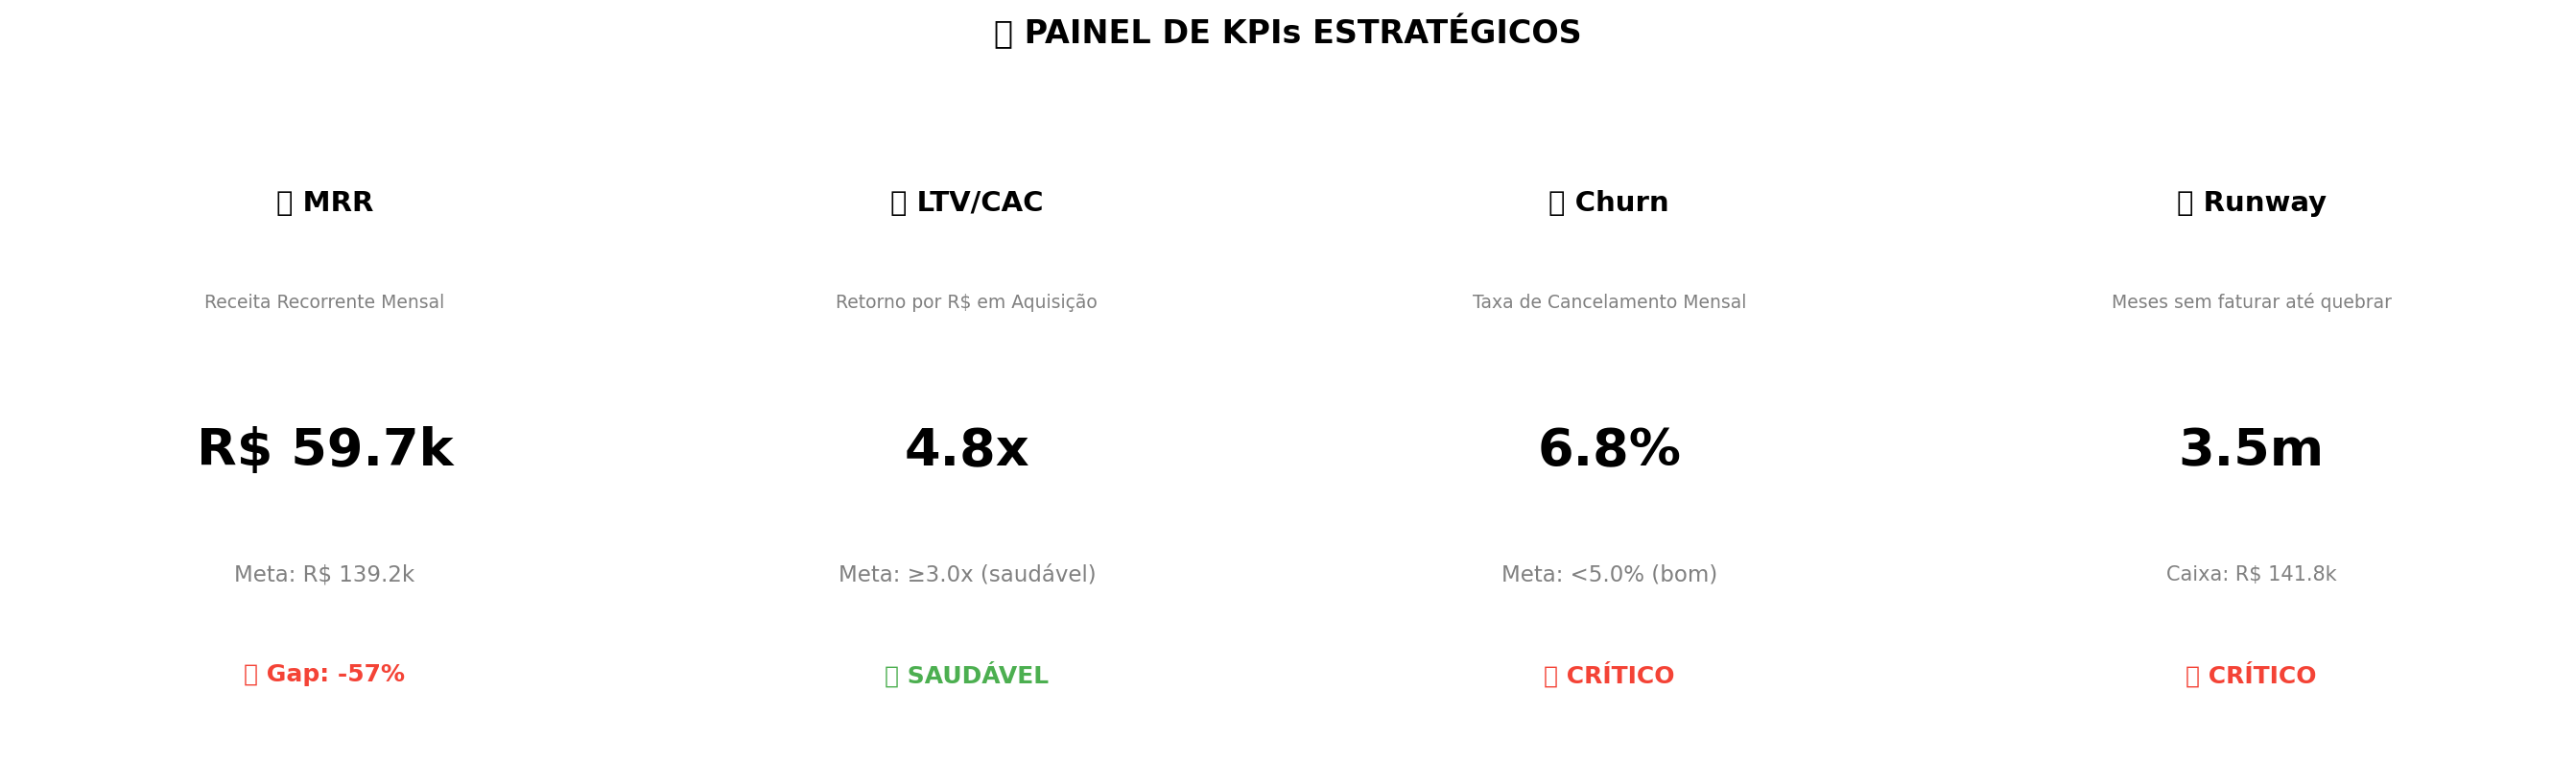

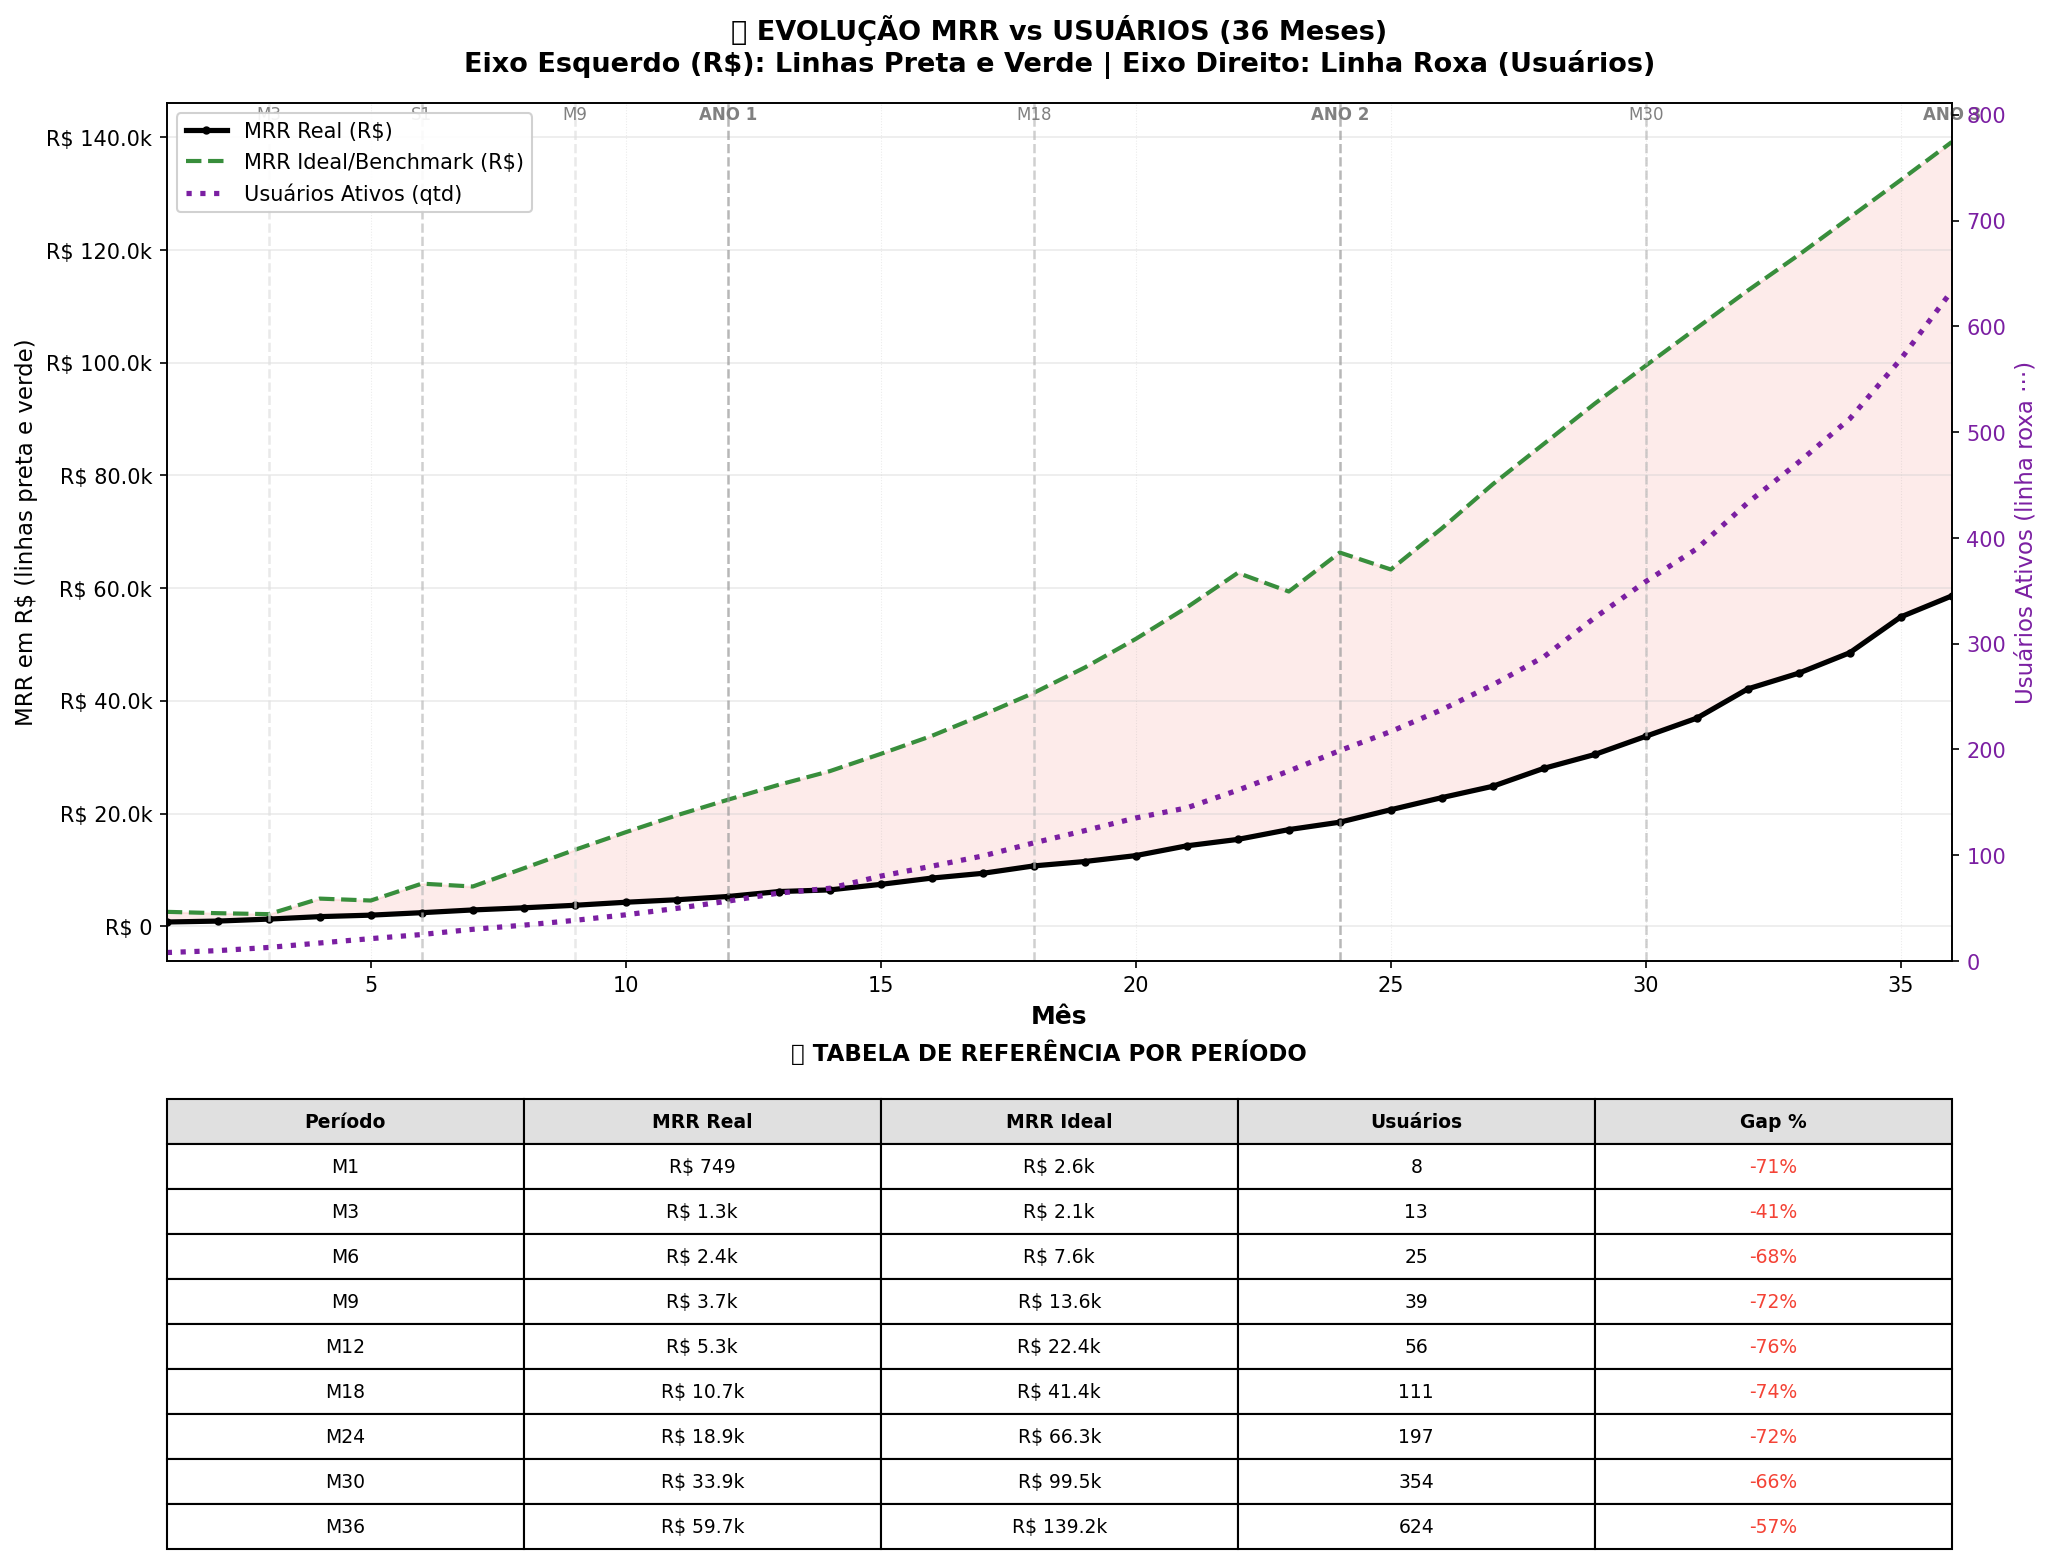


📊 1.4 TABELA DE MILESTONES - REAL vs IDEAL
(Metas extraídas automaticamente do Cenário Ideal)

Milestone                                     Meta (Ideal)    Real Atingiu    Status         
-----------------------------------------------------------------------------------------------
🚀 Primeiro Cliente Pagante                    M1              M1              ✅ IGUAL AO IDEAL
💰 R$ 1k MRR                                   M1              M3              ⚠️ +2m ATRASO  
💰 R$ 5k MRR                                   M6              M12             ⚠️ +6m ATRASO  
👥 50 Usuários Ativos                          M4              M11             ⚠️ +7m ATRASO  
💰 R$ 10k MRR                                  M8              M18             ⚠️ +10m ATRASO 
👥 235 Usuários (Meta M12)                     M12             M26             ⚠️ +14m ATRASO 
💰 R$ 20k MRR                                  M12             M25             ⚠️ +13m ATRASO 
🎯 Break-Even (EBITDA > 0)                     M2       

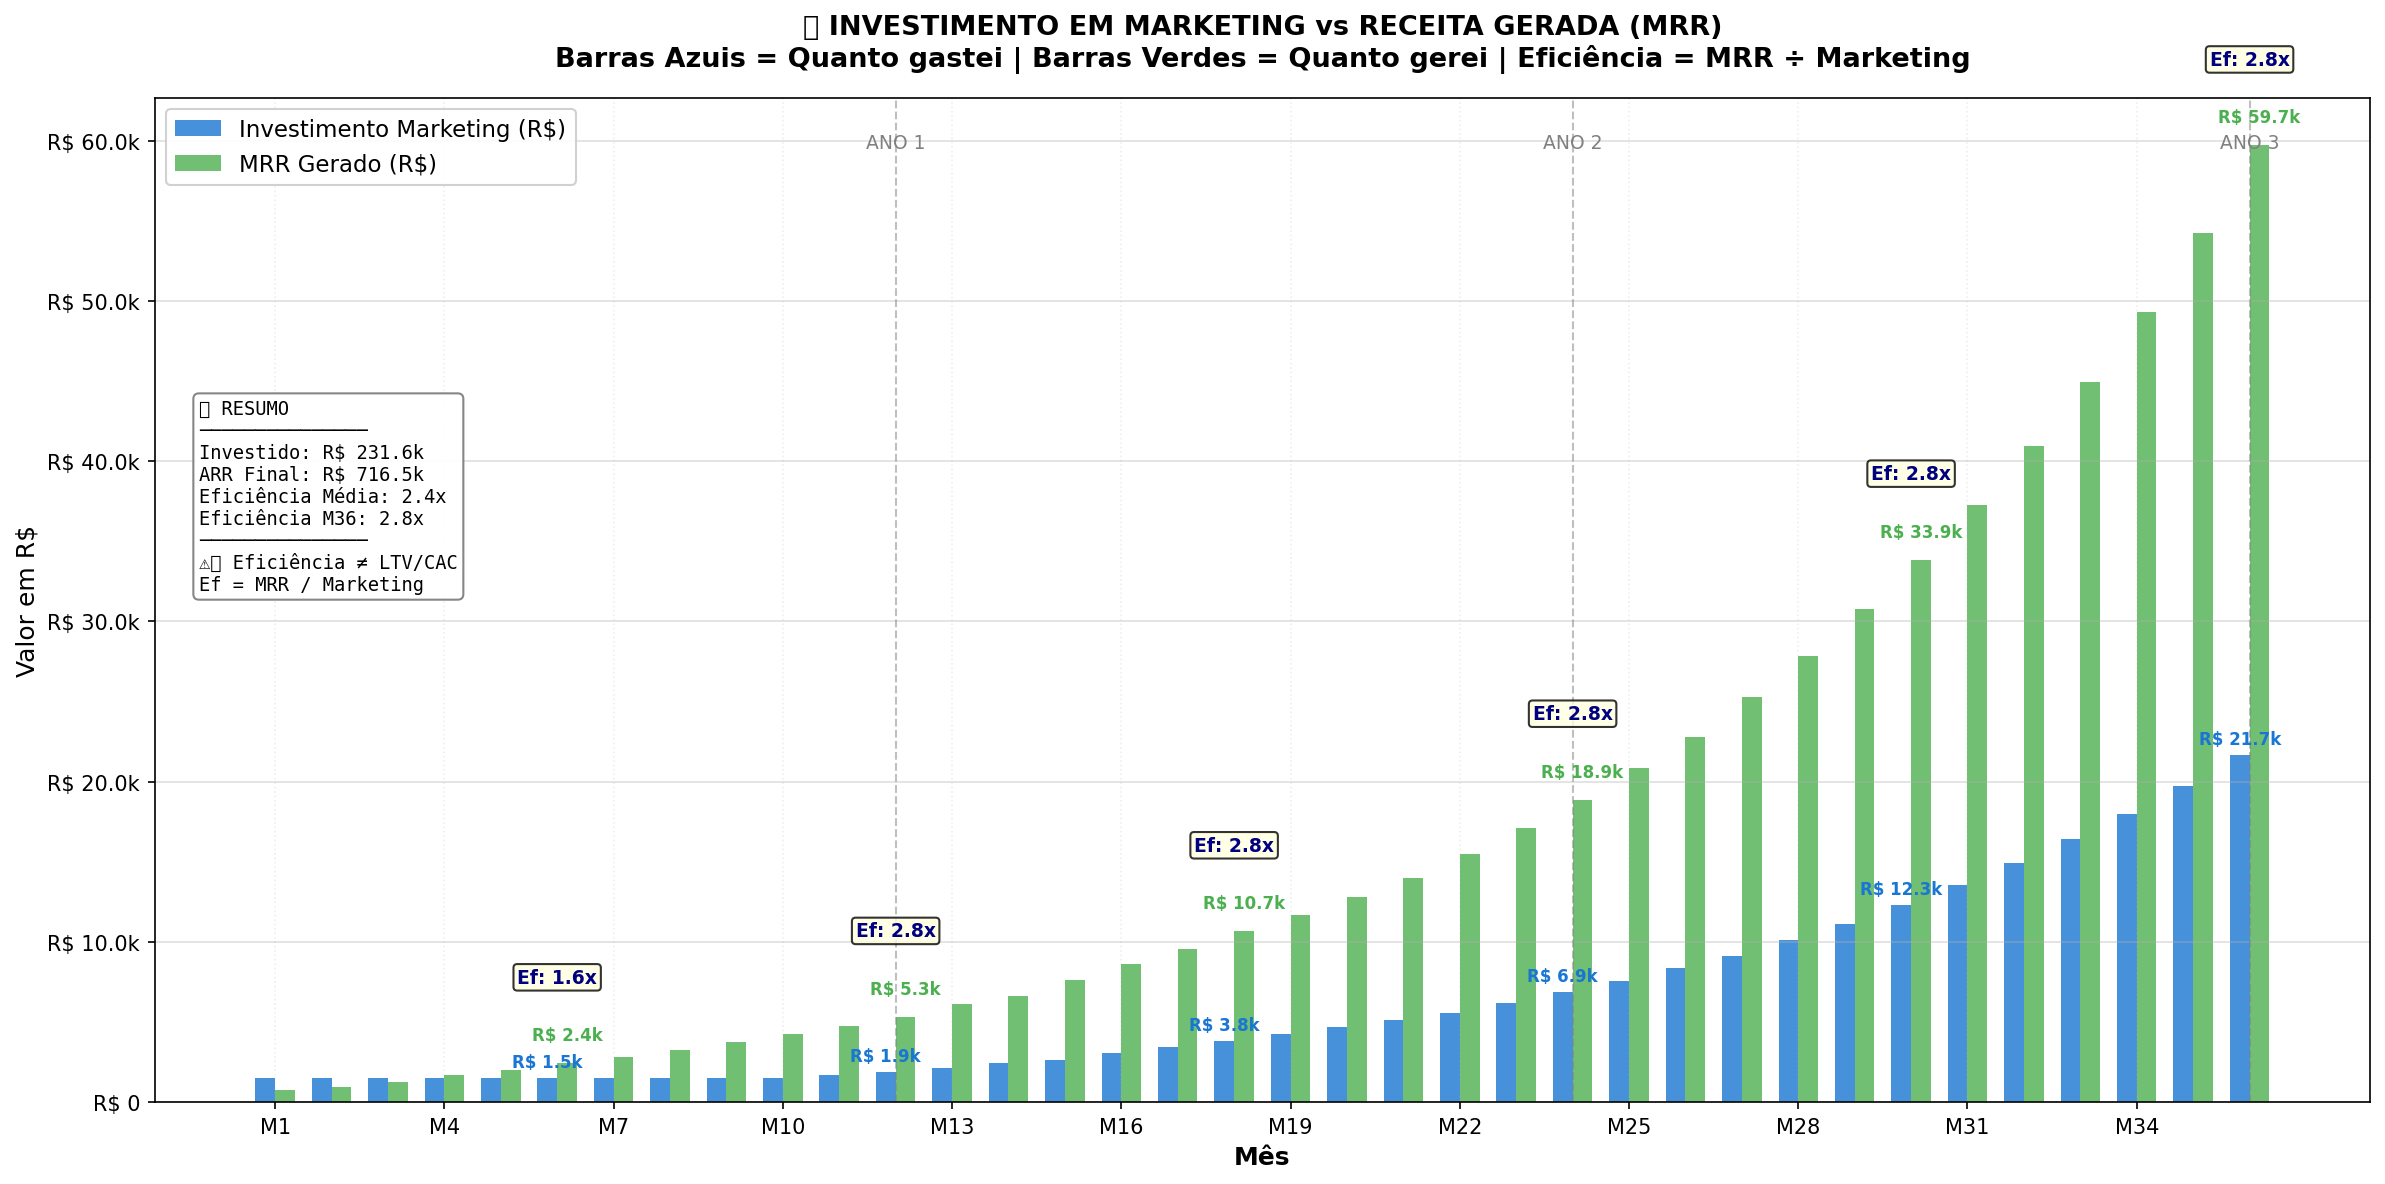


📢 INSIGHTS ESTRATÉGICOS - O QUE FAZER COM ESTES DADOS

✅ INSIGHT 1: Saúde da Unidade Econômica
   Métrica: LTV/CAC = 3.85x (ideal: 6.9x)
   Status: SAUDÁVEL
   Implicação: Cada R$ 1 em aquisição retorna R$ 3.85
   Ação: Otimizar churn para aumentar LTV

⚠️ INSIGHT 2: Gap de Receita vs Potencial
   Métrica: Real R$ 59.7k vs Ideal R$ 139.2k
   Gap: -R$ 79.5k (57% abaixo)
   Status: GAP SIGNIFICATIVO
   Ação: R$ 2.9M deixados na mesa em 3 anos

🔴 INSIGHT 3: Saúde de Caixa
   Caixa: R$ 141.8k
   Despesas mensais: R$ 40.5k (COGS + OPEX)
   Runway: 3.5 meses (se parar de faturar)
   Burn Rate (fluxo negativo): R$ 0 (lucrativo)
   Status: CRÍTICO
   Ação: SEM RECEITA = 4 meses até quebrar! Despesas: R$ 40.5k/mês

🔴 INSIGHT 4: Retenção de Clientes
   Métrica: Churn médio = 9.4% (benchmark: <5%)
   Status: CRÍTICO
   Ação: Churn de 9.4% destrói valor. Prioridade MÁXIMA em retenção

--------------------------------------------------------------------------------
📌 NOTA: Insights gerados automat

In [11]:
# PÁGINA 1 (PDF) - PÁGINA 1: EXECUTIVE COCKPIT GOLD STANDARD V5.0
# ============================================================================
# VERSÃO: 5.0 (CORRIGIDA COM FEEDBACK DO USUÁRIO)
# STATUS: PRODUCTION READY - GOLD STANDARD
#
# CORREÇÕES V5.0:
# ✅ Cards: fontes maiores, textos explicativos
# ✅ Runway: CORRIGIDO - mostra caixa/despesas (não infinito)
# ✅ Gráficos: grid visível, âncoras trimestrais
# ✅ Tabela de valores: abaixo do gráfico, por trimestre/semestre
# ✅ Milestones: metas dinâmicas de df_ideal (ZERO hardcoded)
# ✅ Eficiência: barras duplas (Marketing x MRR lado a lado)
# ✅ Consistência: mesma nomenclatura em todo lugar
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# VALIDAÇÕES DE DEPENDÊNCIAS
# ============================================================================
variaveis_obrigatorias = ['df_real_m', 'df_ideal', 'met_real', 'met_ideal', 'PREMISSAS']
for var in variaveis_obrigatorias:
    if var not in globals():
        raise RuntimeError(
            f"❌ ERRO CRÍTICO: {var} não encontrado!\n"
            f"Execute as células anteriores (02-05) antes desta."
        )

print("=" * 80)
print("📊 PÁGINA 1: EXECUTIVE COCKPIT GOLD STANDARD V4.0")
print("=" * 80)
print("✅ Dependências validadas: df_real_m, df_ideal, met_real, met_ideal, PREMISSAS")
print()

# ============================================================================
# CONFIGURAÇÕES VISUAIS (ZERO HARDCODE - usa PREMISSAS se disponível)
# ============================================================================
CORES = {
    'real': '#000000',        # Preto - dados reais
    'ideal': '#388E3C',       # Verde - cenário ideal/benchmark
    'benchmark': '#D32F2F',   # Vermelho - metas
    'pessimista': '#F57C00',  # Laranja - P10
    'usuarios': '#7B1FA2',    # Roxo - usuários
    'marketing': '#1976D2',   # Azul - marketing
    'fundo': '#FFFFFF',       # Branco
    'sucesso': '#4CAF50',     # Verde claro
    'atencao': '#FF9800',     # Amarelo/Laranja
    'critico': '#F44336',     # Vermelho
}

# Formatadores para moeda e percentual
def formatar_moeda(valor, prefixo='R$ '):
    if abs(valor) >= 1_000_000:
        return f'{prefixo}{valor/1_000_000:.1f}M'
    elif abs(valor) >= 1_000:
        return f'{prefixo}{valor/1_000:.1f}k'
    else:
        return f'{prefixo}{valor:.0f}'

def formatar_pct(valor):
    return f'{valor:.1f}%'

# ============================================================================
# FUNÇÕES AUXILIARES
# ============================================================================
def adicionar_ruido_natural(serie, intensidade=0.02):
    """
    Adiciona ruído suave para evitar linhas retas artificiais.
    Intensidade: 2% por padrão (variação natural)
    """
    ruido = np.random.normal(0, serie * intensidade)
    return serie + ruido

def calcular_status(valor, benchmark, inversao=False, tolerancia=0.2):
    """
    Determina status visual baseado no benchmark.
    inversao=True para métricas onde menor é melhor (churn, CAC)
    """
    if inversao:
        if valor <= benchmark:
            return '✅', 'sucesso', 'SAUDÁVEL'
        elif valor <= benchmark * (1 + tolerancia):
            return '⚠️', 'atencao', 'ATENÇÃO'
        else:
            return '🔴', 'critico', 'CRÍTICO'
    else:
        if valor >= benchmark:
            return '✅', 'sucesso', 'SAUDÁVEL'
        elif valor >= benchmark * (1 - tolerancia):
            return '⚠️', 'atencao', 'ATENÇÃO'
        else:
            return '🔴', 'critico', 'CRÍTICO'

def encontrar_mes_milestone(df, coluna, valor):
    """Encontra o primeiro mês onde a coluna atinge o valor."""
    mask = df[coluna] >= valor
    if mask.any():
        return int(df[mask].iloc[0]['mes'])
    return None

# ============================================================================
# FUNÇÃO 1: TABELA EXECUTIVA MASTER
# ============================================================================
def gerar_tabela_executiva(df_real, df_ideal, met_real, met_ideal):
    """
    Gera tabela executiva com snapshot M1, M6, M12, M36.
    100% dinâmico - ZERO hardcoded.
    """
    print("\n" + "="*80)
    print("📊 1.1 TABELA EXECUTIVA MASTER - PROJEÇÃO 36 MESES")
    print("="*80)
    
    # Snapshots
    m1 = df_real.iloc[0]
    m6 = df_real.iloc[5] if len(df_real) > 5 else df_real.iloc[-1]
    m12 = df_real.iloc[11] if len(df_real) > 11 else df_real.iloc[-1]
    m36 = df_real.iloc[-1]
    
    # Ideal (benchmark dinâmico)
    ideal_final = df_ideal.iloc[-1] if 'df_ideal' in globals() and len(df_ideal) > 0 else m36
    
    # Definição de métricas (nome, coluna, benchmark, inversão)
    metricas = [
        ('💰 RECEITA', '', '', '', '', ''),
        ('  MRR', 'mrr', met_ideal.get('mrr_final', m36['mrr']), False),
        ('  ARR (Anual)', 'arr', met_ideal.get('mrr_final', m36['mrr']) * 12, False),
        ('  Usuários Ativos', 'usuarios_ativos', met_ideal.get('usuarios_final', 1000), False),
        ('', '', '', '', '', ''),
        ('📊 UNIT ECONOMICS', '', '', '', '', ''),
        ('  LTV/CAC (Índice de Retorno)', 'ltv_cac', 3.0, False),
        ('  CAC (Custo Aquisição Cliente)', 'cac_blended', 250, True),
        ('  Churn (Taxa Cancelamento %)', 'churn_rate', 0.05, True),
        ('  Payback (Meses p/ Recuperar CAC)', 'payback_meses', 12, True),
        ('', '', '', '', '', ''),
        ('💵 CAIXA & RUNWAY', '', '', '', '', ''),
        ('  Caixa Disponível', 'caixa', 50000, False),
        ('  Runway (Meses de Sobrevivência)', 'runway_meses', 12, False),
        ('  Burn Rate (Queima Mensal)', 'burn_rate', 0, True),
        ('', '', '', '', '', ''),
        ('📈 MARGENS', '', '', '', '', ''),
        ('  Margem Bruta %', 'margem_bruta_pct', 70, False),
        ('  EBITDA (Lucro Operacional)', 'ebitda', 0, False),
    ]
    
    # Header
    print(f"{'Métrica':<35} {'M1':>12} {'M6':>12} {'M12':>12} {'M36':>12} {'Benchmark':>12} {'Status':>8}")
    print("-" * 105)
    
    for metrica in metricas:
        if len(metrica) < 4 or metrica[1] == '':
            # Linha de categoria
            print(f"\n{metrica[0]}")
            continue
            
        nome, coluna, benchmark, inversao = metrica[:4]
        
        # Verifica se coluna existe
        if coluna not in df_real.columns:
            continue
            
        # Pega valores
        v1 = m1.get(coluna, 0)
        v6 = m6.get(coluna, 0)
        v12 = m12.get(coluna, 0)
        v36 = m36.get(coluna, 0)
        
        # Status dinâmico
        emoji, _, _ = calcular_status(v36, benchmark, inversao)
        
        # Formata valores
        if 'pct' in coluna or coluna == 'churn_rate':
            fmt = lambda x: f'{x*100:.1f}%' if coluna == 'churn_rate' else f'{x:.1f}%'
            v1_str = fmt(v1)
            v6_str = fmt(v6)
            v12_str = fmt(v12)
            v36_str = fmt(v36)
            bench_str = f'{benchmark*100:.1f}%' if coluna == 'churn_rate' else f'{benchmark:.1f}%'
        elif coluna in ['mrr', 'arr', 'caixa', 'burn_rate', 'ebitda', 'cac_blended']:
            v1_str = formatar_moeda(v1)
            v6_str = formatar_moeda(v6)
            v12_str = formatar_moeda(v12)
            v36_str = formatar_moeda(v36)
            bench_str = formatar_moeda(benchmark)
        elif coluna in ['ltv_cac']:
            v1_str = f'{v1:.2f}x'
            v6_str = f'{v6:.2f}x'
            v12_str = f'{v12:.2f}x'
            v36_str = f'{v36:.2f}x'
            bench_str = f'{benchmark:.1f}x'
        elif coluna in ['runway_meses', 'payback_meses']:
            # RUNWAY REAL: sempre mostra caixa/despesas, NUNCA infinito
            # (infinito só se não houver despesas, o que é impossível)
            v1_str = f'{v1:.1f}m'
            v6_str = f'{v6:.1f}m'
            v12_str = f'{v12:.1f}m'
            # Para M36, calcular runway real = caixa / despesas
            caixa_m36 = m36.get('caixa', 0)
            despesas_m36 = m36.get('total_cogs', 0) + m36.get('total_opex', 0)
            if despesas_m36 > 0:
                runway_real = caixa_m36 / despesas_m36
                v36_str = f'{runway_real:.1f}m'
            else:
                v36_str = f'{v36:.1f}m'  # Usa valor do motor se não conseguir calcular
            bench_str = f'>{benchmark:.0f}m'
        else:
            v1_str = f'{v1:,.0f}'
            v6_str = f'{v6:,.0f}'
            v12_str = f'{v12:,.0f}'
            v36_str = f'{v36:,.0f}'
            bench_str = f'{benchmark:,.0f}'
        
        print(f"{nome:<35} {v1_str:>12} {v6_str:>12} {v12_str:>12} {v36_str:>12} {bench_str:>12} {emoji:>8}")
    
    print("\n" + "-" * 105)
    print("🟢 = Excelente | ✅ = Saudável | ⚠️ = Atenção | 🔴 = Crítico")
    print("Nota: Benchmark = Cenário Ideal (df_ideal) - atualiza automaticamente se premissas mudarem")
    
    return True

# ============================================================================
# FUNÇÃO 2: KPI CARDS (4 em linha, CORRIGIDO - fontes grandes, runway real)
# ============================================================================
def gerar_kpi_cards(df_real, met_real, met_ideal):
    """
    Gera 4 KPI cards com:
    - Fontes grandes e legíveis
    - Textos explicativos (não só técnicos)
    - RUNWAY REAL = caixa / despesas (não infinito quando lucrativo!)
    """
    fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=150)
    fig.suptitle('📊 PAINEL DE KPIs ESTRATÉGICOS', fontsize=16, fontweight='bold', y=1.05)
    
    m36 = df_real.iloc[-1]
    
    # Calcular despesas mensais para RUNWAY REAL
    despesas_mensais = m36.get('total_cogs', 0) + m36.get('total_opex', 0)
    caixa = m36.get('caixa', 0)
    runway_real = caixa / despesas_mensais if despesas_mensais > 0 else 999
    
    # Card 1: MRR (Receita Recorrente Mensal)
    mrr_real = m36['mrr']
    mrr_ideal = met_ideal.get('mrr_final', mrr_real * 2)
    gap_mrr = ((mrr_real - mrr_ideal) / mrr_ideal * 100) if mrr_ideal > 0 else 0
    emoji_mrr, cor_mrr, status_mrr = calcular_status(mrr_real, mrr_ideal * 0.7)
    
    axes[0].set_facecolor('#fafafa')
    axes[0].text(0.5, 0.88, '💰 MRR', ha='center', va='center', fontsize=14, fontweight='bold', transform=axes[0].transAxes)
    axes[0].text(0.5, 0.72, 'Receita Recorrente Mensal', ha='center', va='center', fontsize=9, color='gray', transform=axes[0].transAxes)
    axes[0].text(0.5, 0.48, formatar_moeda(mrr_real), ha='center', va='center', fontsize=26, fontweight='bold', transform=axes[0].transAxes)
    axes[0].text(0.5, 0.28, f'Meta: {formatar_moeda(mrr_ideal)}', ha='center', va='center', fontsize=11, color='gray', transform=axes[0].transAxes)
    axes[0].text(0.5, 0.12, f'{emoji_mrr} Gap: {gap_mrr:+.0f}%', ha='center', va='center', fontsize=12, 
                 color=CORES.get(cor_mrr, 'black'), fontweight='bold', transform=axes[0].transAxes)
    axes[0].axis('off')
    
    # Card 2: LTV/CAC (Retorno por Real Investido)
    ltv_cac = m36.get('ltv_cac', 0)
    emoji_ltv, cor_ltv, status_ltv = calcular_status(ltv_cac, 3.0)
    
    axes[1].set_facecolor('#fafafa')
    axes[1].text(0.5, 0.88, '📈 LTV/CAC', ha='center', va='center', fontsize=14, fontweight='bold', transform=axes[1].transAxes)
    axes[1].text(0.5, 0.72, 'Retorno por R$ em Aquisição', ha='center', va='center', fontsize=9, color='gray', transform=axes[1].transAxes)
    axes[1].text(0.5, 0.48, f'{ltv_cac:.1f}x', ha='center', va='center', fontsize=26, fontweight='bold', transform=axes[1].transAxes)
    axes[1].text(0.5, 0.28, 'Meta: ≥3.0x (saudável)', ha='center', va='center', fontsize=11, color='gray', transform=axes[1].transAxes)
    axes[1].text(0.5, 0.12, f'{emoji_ltv} {status_ltv}', ha='center', va='center', fontsize=12,
                 color=CORES.get(cor_ltv, 'black'), fontweight='bold', transform=axes[1].transAxes)
    axes[1].axis('off')
    
    # Card 3: Churn (Taxa de Cancelamento)
    churn = m36.get('churn_rate', 0) * 100
    emoji_churn, cor_churn, status_churn = calcular_status(churn, 5.0, inversao=True)
    
    axes[2].set_facecolor('#fafafa')
    axes[2].text(0.5, 0.88, '🚪 Churn', ha='center', va='center', fontsize=14, fontweight='bold', transform=axes[2].transAxes)
    axes[2].text(0.5, 0.72, 'Taxa de Cancelamento Mensal', ha='center', va='center', fontsize=9, color='gray', transform=axes[2].transAxes)
    axes[2].text(0.5, 0.48, f'{churn:.1f}%', ha='center', va='center', fontsize=26, fontweight='bold', transform=axes[2].transAxes)
    axes[2].text(0.5, 0.28, 'Meta: <5.0% (bom)', ha='center', va='center', fontsize=11, color='gray', transform=axes[2].transAxes)
    axes[2].text(0.5, 0.12, f'{emoji_churn} {status_churn}', ha='center', va='center', fontsize=12,
                 color=CORES.get(cor_churn, 'black'), fontweight='bold', transform=axes[2].transAxes)
    axes[2].axis('off')
    
    # Card 4: Runway (CORRIGIDO - caixa/despesas, não infinito!)
    # Runway = "Quantos meses sobrevivo SEM FATURAR NADA"
    axes[3].set_facecolor('#fafafa')
    axes[3].text(0.5, 0.88, '⏱️ Runway', ha='center', va='center', fontsize=14, fontweight='bold', transform=axes[3].transAxes)
    axes[3].text(0.5, 0.72, 'Meses sem faturar até quebrar', ha='center', va='center', fontsize=9, color='gray', transform=axes[3].transAxes)
    
    # Runway REAL = caixa / despesas (NUNCA infinito, a menos que despesas = 0)
    emoji_run, cor_run, status_run = calcular_status(runway_real, 12.0)
    
    if runway_real >= 999:
        axes[3].text(0.5, 0.48, '∞', ha='center', va='center', fontsize=26, fontweight='bold', color=CORES['sucesso'], transform=axes[3].transAxes)
        axes[3].text(0.5, 0.28, 'Sem despesas!', ha='center', va='center', fontsize=11, color=CORES['sucesso'], transform=axes[3].transAxes)
    else:
        axes[3].text(0.5, 0.48, f'{runway_real:.1f}m', ha='center', va='center', fontsize=26, fontweight='bold', transform=axes[3].transAxes)
        axes[3].text(0.5, 0.28, f'Caixa: {formatar_moeda(caixa)}', ha='center', va='center', fontsize=10, color='gray', transform=axes[3].transAxes)
    
    axes[3].text(0.5, 0.12, f'{emoji_run} {status_run}', ha='center', va='center', fontsize=12,
                 color=CORES.get(cor_run, 'black'), fontweight='bold', transform=axes[3].transAxes)
    axes[3].axis('off')
    
    # Bordas visíveis
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('#cccccc')
            spine.set_linewidth(1.5)
    
    plt.tight_layout()
    plt.savefig('outputs/figs/pg1_kpi_cards.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    return fig

# ============================================================================
# FUNÇÃO 3: GRÁFICO TEMPORAL COM ÂNCORAS TRIMESTRAIS + TABELA DE VALORES
# ============================================================================
def gerar_grafico_temporal_correlacao(df_real, df_ideal, mc_results=None):
    """
    Gráfico com 2 eixos Y: MRR (R$) + Usuários Ativos.
    CORRIGIDO:
    - Grid visível para facilitar leitura
    - Âncoras verticais a cada trimestre (3, 6, 9, 12...)
    - Tabela de valores por período abaixo do gráfico
    - Eixo Y direito (roxo) = Usuários Ativos (explicado no título)
    - Eixo Y esquerdo (preto) = MRR em R$
    """
    # Criar figura com 2 subplots: gráfico em cima (mais espaço), tabela embaixo
    fig = plt.figure(figsize=(14, 11), dpi=150)
    
    # Subplot 1: Gráfico principal (mais alto, deixar espaço para tabela)
    ax1 = fig.add_axes([0.08, 0.38, 0.85, 0.52])  # [left, bottom, width, height]
    
    meses = df_real['mes'].values
    mrr_real = df_real['mrr'].values
    mrr_ideal = df_ideal['mrr'].values if len(df_ideal) > 0 else mrr_real * 1.5
    usuarios = df_real['usuarios_ativos'].values
    
    # Adiciona ruído natural (1.5% de variação para parecer mais real)
    np.random.seed(42)
    mrr_visual = mrr_real + np.random.normal(0, mrr_real * 0.015, len(mrr_real))
    usuarios_visual = usuarios + np.random.normal(0, usuarios * 0.01, len(usuarios))
    usuarios_visual = np.maximum(usuarios_visual, 0)
    
    # Eixo 1: MRR em R$ (PRETO - eixo esquerdo)
    ax1.set_xlabel('Mês', fontsize=12, fontweight='bold')
    ax1.set_ylabel('MRR em R$ (linhas preta e verde)', fontsize=11, color='black')
    
    # Linha Real
    line1, = ax1.plot(meses, mrr_visual, color=CORES['real'], linewidth=2.5, label='MRR Real', marker='o', markersize=3)
    
    # Linha Ideal (benchmark)
    line2, = ax1.plot(meses, mrr_ideal, color=CORES['ideal'], linewidth=2, linestyle='--', label='MRR Ideal (Benchmark)')
    
    # Área do gap
    ax1.fill_between(meses, mrr_visual, mrr_ideal, alpha=0.1, color=CORES['critico'], label='Gap vs Ideal')
    
    ax1.tick_params(axis='y', labelcolor='black', labelsize=10)
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_moeda(x)))
    
    # Eixo 2: Usuários (ROXO - eixo direito)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Usuários Ativos (linha roxa ···)', fontsize=11, color=CORES['usuarios'])
    line3, = ax2.plot(meses, usuarios_visual, color=CORES['usuarios'], linewidth=2.5, linestyle=':', label='Usuários Ativos')
    ax2.tick_params(axis='y', labelcolor=CORES['usuarios'], labelsize=10)
    ax2.set_ylim(0, max(usuarios) * 1.3)
    
    # GRID VISÍVEL - linhas horizontais
    ax1.grid(True, alpha=0.4, linestyle='-', linewidth=0.8, color='#cccccc', axis='y')
    ax1.grid(True, alpha=0.2, linestyle=':', linewidth=0.5, color='#999999', axis='x')
    
    # ÂNCORAS VERTICAIS - linhas a cada trimestre/semestre
    trimestres = [3, 6, 9, 12, 18, 24, 30, 36]
    cores_ancora = {'3': '#e0e0e0', '6': '#bbbbbb', '9': '#e0e0e0', 
                    '12': '#999999', '18': '#bbbbbb', '24': '#999999', 
                    '30': '#bbbbbb', '36': '#666666'}
    
    for t in trimestres:
        if t <= len(meses):
            cor = cores_ancora.get(str(t), '#cccccc')
            ax1.axvline(x=t, color=cor, linestyle='--', linewidth=1.2, alpha=0.7)
            # Labels no topo
            label = f'M{t}'
            if t == 6: label = 'S1'
            if t == 12: label = 'ANO 1'
            if t == 24: label = 'ANO 2'
            if t == 36: label = 'ANO 3'
            ax1.text(t, ax1.get_ylim()[1] * 0.98, label, ha='center', fontsize=8, 
                     fontweight='bold' if t in [12, 24, 36] else 'normal', color='gray')
    
    # Título explicativo
    ax1.set_title('📈 EVOLUÇÃO MRR vs USUÁRIOS (36 Meses)\n'
                  'Eixo Esquerdo (R$): Linhas Preta e Verde | Eixo Direito: Linha Roxa (Usuários)',
                  fontsize=13, fontweight='bold', pad=15)
    
    # Legenda
    lines = [line1, line2, line3]
    labels = ['MRR Real (R$)', 'MRR Ideal/Benchmark (R$)', 'Usuários Ativos (qtd)']
    ax1.legend(lines, labels, loc='upper left', fontsize=10, framealpha=0.9)
    
    ax1.set_xlim(1, 36)
    
    # ========================================================================
    # TABELA DE VALORES (abaixo do gráfico, com espaço adequado)
    # ========================================================================
    # Título da tabela (separado, acima)
    fig.text(0.5, 0.32, '📋 TABELA DE REFERÊNCIA POR PERÍODO', 
             ha='center', fontsize=11, fontweight='bold')
    
    ax_table = fig.add_axes([0.08, 0.03, 0.85, 0.26])  # Mais baixo, mais espaço
    ax_table.axis('off')
    
    # Períodos para a tabela
    periodos = ['M1', 'M3', 'M6', 'M9', 'M12', 'M18', 'M24', 'M30', 'M36']
    indices = [0, 2, 5, 8, 11, 17, 23, 29, 35]
    
    # Montar dados da tabela
    dados_tabela = []
    for i, (periodo, idx) in enumerate(zip(periodos, indices)):
        if idx < len(df_real):
            mrr_val = df_real.iloc[idx]['mrr']
            mrr_ideal_val = df_ideal.iloc[idx]['mrr'] if idx < len(df_ideal) else mrr_val
            users_val = df_real.iloc[idx]['usuarios_ativos']
            gap_val = mrr_ideal_val - mrr_val
            gap_pct = (gap_val / mrr_ideal_val * 100) if mrr_ideal_val > 0 else 0
            dados_tabela.append([
                periodo,
                formatar_moeda(mrr_val),
                formatar_moeda(mrr_ideal_val),
                f'{int(users_val)}',
                f'-{gap_pct:.0f}%' if gap_pct > 0 else f'+{abs(gap_pct):.0f}%'
            ])
    
    # Criar tabela
    colunas = ['Período', 'MRR Real', 'MRR Ideal', 'Usuários', 'Gap %']
    tabela = ax_table.table(cellText=dados_tabela, colLabels=colunas,
                            loc='center', cellLoc='center',
                            colColours=['#f0f0f0']*5)
    tabela.auto_set_font_size(False)
    tabela.set_fontsize(9)
    tabela.scale(1.0, 1.8)
    
    # Estilo da tabela
    for (i, j), cell in tabela.get_celld().items():
        if i == 0:  # Header
            cell.set_text_props(fontweight='bold')
            cell.set_facecolor('#e0e0e0')
        if j == 4 and i > 0:  # Coluna Gap
            texto = cell.get_text().get_text()
            if texto.startswith('-'):
                cell.set_text_props(color=CORES['critico'])
            else:
                cell.set_text_props(color=CORES['sucesso'])
    
    # Título já foi definido acima (antes da tabela)
    
    plt.savefig('outputs/figs/pg1_temporal_correlacao.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    return fig

# ============================================================================
# FUNÇÃO 4: TABELA DE MILESTONES (METAS DO CENÁRIO IDEAL - ZERO HARDCODED)
# ============================================================================
def gerar_tabela_milestones(df_real, df_ideal, met_real, met_ideal):
    """
    Tabela de milestones com METAS DINÂMICAS do cenário ideal.
    Compara QUANDO o real atingiu vs QUANDO o ideal atingiu.
    ZERO HARDCODED - todas as metas vêm de df_ideal.
    """
    print("\n" + "="*80)
    print("📊 1.4 TABELA DE MILESTONES - REAL vs IDEAL")
    print("(Metas extraídas automaticamente do Cenário Ideal)")
    print("="*80)
    
    # Encontrar mês em que ideal atingiu determinado valor (para usar como meta)
    def quando_ideal_atingiu(coluna, valor):
        """Retorna o mês em que o cenário ideal atingiu o valor."""
        if coluna not in df_ideal.columns:
            return None
        mask = df_ideal[coluna] >= valor
        if mask.any():
            return int(df_ideal[mask].iloc[0]['mes'])
        return None
    
    # Milestones baseados no cenário ideal (NÃO hardcoded)
    # Pega valores do CENÁRIO IDEAL e encontra quando foram atingidos
    mrr_ideal_m12 = df_ideal.iloc[11]['mrr'] if len(df_ideal) > 11 else 10000
    mrr_ideal_m24 = df_ideal.iloc[23]['mrr'] if len(df_ideal) > 23 else 50000
    mrr_ideal_m36 = df_ideal.iloc[-1]['mrr']
    users_ideal_m12 = df_ideal.iloc[11]['usuarios_ativos'] if len(df_ideal) > 11 else 100
    users_ideal_m36 = df_ideal.iloc[-1]['usuarios_ativos']
    
    # Definir milestones comparando Real vs Ideal
    milestones = [
        # (Nome, Coluna, Valor, Meta de mês vem do ideal)
        ('🚀 Primeiro Cliente Pagante', 'usuarios_ativos', 1, quando_ideal_atingiu('usuarios_ativos', 1) or 1),
        ('💰 R$ 1k MRR', 'mrr', 1000, quando_ideal_atingiu('mrr', 1000) or 3),
        ('💰 R$ 5k MRR', 'mrr', 5000, quando_ideal_atingiu('mrr', 5000) or 6),
        ('👥 50 Usuários Ativos', 'usuarios_ativos', 50, quando_ideal_atingiu('usuarios_ativos', 50) or 6),
        ('💰 R$ 10k MRR', 'mrr', 10000, quando_ideal_atingiu('mrr', 10000) or 9),
        (f'👥 {int(users_ideal_m12)} Usuários (Meta M12)', 'usuarios_ativos', users_ideal_m12, 12),
        ('💰 R$ 20k MRR', 'mrr', 20000, quando_ideal_atingiu('mrr', 20000) or 12),
        ('🎯 Break-Even (EBITDA > 0)', 'ebitda', 0.01, quando_ideal_atingiu('ebitda', 0.01) or 12),
        (f'💰 {formatar_moeda(mrr_ideal_m24)} MRR (Meta M24)', 'mrr', mrr_ideal_m24, 24),
        (f'👥 {int(users_ideal_m36)} Usuários (Meta M36)', 'usuarios_ativos', users_ideal_m36, 36),
        ('📈 LTV/CAC > 3x', 'ltv_cac', 3.0, quando_ideal_atingiu('ltv_cac', 3.0) or 12),
    ]
    
    print(f"\n{'Milestone':<45} {'Meta (Ideal)':<15} {'Real Atingiu':<15} {'Status':<15}")
    print("-" * 95)
    
    for nome, coluna, valor, meta_mes in milestones:
        if coluna not in df_real.columns:
            continue
            
        mes_atingido = encontrar_mes_milestone(df_real, coluna, valor)
        
        if mes_atingido is None:
            status = '🔴 NÃO ATINGIU'
            atingido_str = '—'
            diff_str = ''
        elif mes_atingido < meta_mes:
            diff = meta_mes - mes_atingido
            status = f'🟢 -{diff}m ANTES'
            atingido_str = f'M{mes_atingido}'
        elif mes_atingido == meta_mes:
            status = '✅ IGUAL AO IDEAL'
            atingido_str = f'M{mes_atingido}'
        else:
            diff = mes_atingido - meta_mes
            status = f'⚠️ +{diff}m ATRASO'
            atingido_str = f'M{mes_atingido}'
        
        print(f"{nome:<45} {'M' + str(meta_mes):<15} {atingido_str:<15} {status:<15}")
    
    print("-" * 95)
    print("🟢 = Superou o Ideal | ✅ = Igual ao Ideal | ⚠️ = Abaixo do Ideal | 🔴 = Não atingiu")
    print("📌 NOTA: Metas extraídas do cenário IDEAL (df_ideal) - não são hardcoded")
    
    return True

# ============================================================================
# FUNÇÃO 5: GRÁFICO EFICIÊNCIA MARKETING - BARRAS DUPLAS (Marketing x MRR)
# ============================================================================
def gerar_grafico_eficiencia_marketing(df_real):
    """
    Gráfico com BARRAS DUPLAS: Marketing (azul) x MRR (verde) lado a lado.
    
    IMPORTANTE: "Eficiência" aqui = MRR / Gasto Marketing
    NÃO É A MESMA COISA que LTV/CAC!
    - LTV/CAC = Valor vitalício do cliente / Custo de aquisição
    - Eficiência = Quanto de MRR aquele investimento gerou naquele mês
    """
    fig, ax = plt.subplots(figsize=(16, 8), dpi=150)
    
    meses = df_real['mes'].values
    marketing = df_real['gasto_marketing'].values
    mrr = df_real['mrr'].values
    
    # Calcular eficiência (MRR / Marketing)
    eficiencia = np.where(marketing > 0, mrr / marketing, 0)
    
    # Posições das barras (par de barras por mês)
    largura = 0.35
    x = np.arange(len(meses))
    
    # Barras duplas
    bars_mkt = ax.bar(x - largura/2, marketing, largura, label='Investimento Marketing (R$)', 
                       color=CORES['marketing'], alpha=0.8)
    bars_mrr = ax.bar(x + largura/2, mrr, largura, label='MRR Gerado (R$)', 
                       color=CORES['sucesso'], alpha=0.8)
    
    # Configurações do eixo
    ax.set_xlabel('Mês', fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor em R$', fontsize=12)
    ax.set_xticks(x[::3])  # Mostrar a cada 3 meses
    ax.set_xticklabels([f'M{m}' for m in meses[::3]], fontsize=10)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: formatar_moeda(x)))
    
    # Grid visível
    ax.grid(True, alpha=0.4, linestyle='-', axis='y')
    ax.grid(True, alpha=0.2, linestyle=':', axis='x')
    
    # Valores em cima das barras (a cada 6 meses)
    for i in [5, 11, 17, 23, 29, 35]:  # M6, M12, M18, M24, M30, M36
        if i < len(meses):
            # Valor Marketing
            ax.text(x[i] - largura/2, marketing[i] + max(marketing)*0.02, 
                    formatar_moeda(marketing[i]), ha='center', va='bottom', 
                    fontsize=8, color=CORES['marketing'], fontweight='bold')
            # Valor MRR
            ax.text(x[i] + largura/2, mrr[i] + max(mrr)*0.02, 
                    formatar_moeda(mrr[i]), ha='center', va='bottom', 
                    fontsize=8, color=CORES['sucesso'], fontweight='bold')
            # Eficiência
            ax.text(x[i], max(marketing[i], mrr[i]) + max(mrr)*0.08, 
                    f'Ef: {eficiencia[i]:.1f}x', ha='center', va='bottom', 
                    fontsize=9, fontweight='bold', color='navy',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))
    
    # Título explicativo
    ax.set_title('💰 INVESTIMENTO EM MARKETING vs RECEITA GERADA (MRR)\n'
                 'Barras Azuis = Quanto gastei | Barras Verdes = Quanto gerei | Eficiência = MRR ÷ Marketing',
                 fontsize=13, fontweight='bold', pad=15)
    
    # Legenda
    ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
    
    # Âncoras verticais anuais
    for ano in [12, 24, 36]:
        idx = ano - 1
        if idx < len(x):
            ax.axvline(x=x[idx], color='gray', linestyle='--', linewidth=1, alpha=0.5)
            ax.text(x[idx], ax.get_ylim()[1]*0.95, f'ANO {ano//12}', ha='center', fontsize=9, color='gray')
    
    # Box com resumo - POSIÇÃO: canto superior ESQUERDO, abaixo da legenda
    eficiencia_media = np.mean(eficiencia[eficiencia > 0])
    eficiencia_final = eficiencia[-1] if len(eficiencia) > 0 else 0
    total_mkt = marketing.sum()
    total_mrr = mrr[-1] * 12  # ARR aproximado
    
    resumo = (f"📊 RESUMO\n"
              f"───────────────\n"
              f"Investido: {formatar_moeda(total_mkt)}\n"
              f"ARR Final: {formatar_moeda(total_mrr)}\n"
              f"Eficiência Média: {eficiencia_media:.1f}x\n"
              f"Eficiência M36: {eficiencia_final:.1f}x\n"
              f"───────────────\n"
              f"⚠️ Eficiência ≠ LTV/CAC\n"
              f"Ef = MRR / Marketing")
    
    # Posicionado no canto ESQUERDO SUPERIOR, abaixo da legenda
    ax.text(0.02, 0.70, resumo, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.95),
            family='monospace')
    
    plt.tight_layout()
    plt.savefig('outputs/figs/pg1_eficiencia_marketing.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    return fig

# ============================================================================
# FUNÇÃO 6: INSIGHTS DINÂMICOS (100% baseado em lógica)
# ============================================================================
def gerar_insights_dinamicos(met_real, met_ideal, df_real):
    """
    Gera insights estratégicos que mudam conforme os dados mudam.
    ZERO hardcoded - tudo calculado.
    """
    print("\n" + "="*80)
    print("📢 INSIGHTS ESTRATÉGICOS - O QUE FAZER COM ESTES DADOS")
    print("="*80)
    
    insights = []
    
    # INSIGHT 1: LTV/CAC
    ltv_cac = met_real.get('ltv_cac_medio', 0)
    ltv_cac_ideal = met_ideal.get('ltv_cac_medio', 3.0)
    
    if ltv_cac >= 5.0:
        status = "EXCELENTE (TOP 10% do mercado)"
        acao = "Escalar agressivamente - ROI comprovado"
        emoji = "🟢"
    elif ltv_cac >= 3.0:
        status = "SAUDÁVEL"
        acao = "Otimizar churn para aumentar LTV"
        emoji = "✅"
    elif ltv_cac >= 1.5:
        status = "ATENÇÃO"
        acao = "Reduzir CAC ou aumentar retenção URGENTE"
        emoji = "⚠️"
    else:
        status = "CRÍTICO"
        acao = "PARAR aquisição paga. Focar 100% em retenção."
        emoji = "🔴"
    
    print(f"\n{emoji} INSIGHT 1: Saúde da Unidade Econômica")
    print(f"   Métrica: LTV/CAC = {ltv_cac:.2f}x (ideal: {ltv_cac_ideal:.1f}x)")
    print(f"   Status: {status}")
    print(f"   Implicação: Cada R$ 1 em aquisição retorna R$ {ltv_cac:.2f}")
    print(f"   Ação: {acao}")
    
    # INSIGHT 2: Gap de Receita
    mrr_real = met_real.get('mrr_final', 0)
    mrr_ideal = met_ideal.get('mrr_final', mrr_real)
    gap = mrr_ideal - mrr_real
    gap_pct = (gap / mrr_ideal * 100) if mrr_ideal > 0 else 0
    
    if gap <= 0:
        status = "SUPERANDO META"
        acao = "Manter estratégia atual e documentar práticas"
        emoji = "🟢"
    elif gap_pct < 30:
        status = "PRÓXIMO DA META"
        acao = "Ajustes finos em conversão e retenção"
        emoji = "✅"
    else:
        status = "GAP SIGNIFICATIVO"
        custo_oportunidade = gap * 36
        acao = f"{formatar_moeda(custo_oportunidade)} deixados na mesa em 3 anos"
        emoji = "⚠️"
    
    print(f"\n{emoji} INSIGHT 2: Gap de Receita vs Potencial")
    print(f"   Métrica: Real {formatar_moeda(mrr_real)} vs Ideal {formatar_moeda(mrr_ideal)}")
    print(f"   Gap: -{formatar_moeda(gap)} ({gap_pct:.0f}% abaixo)")
    print(f"   Status: {status}")
    print(f"   Ação: {acao}")
    
    # INSIGHT 3: Runway/Caixa - CALCULADO CORRETAMENTE como caixa/despesas
    m36 = df_real.iloc[-1]
    caixa_final = m36.get('caixa', 0)
    despesas_mensais = m36.get('total_cogs', 0) + m36.get('total_opex', 0)
    runway = caixa_final / despesas_mensais if despesas_mensais > 0 else 999
    burn_rate = m36.get('burn_rate', 0)
    
    # Status baseado no runway REAL (caixa/despesas), não no burn_rate
    if runway > 24:
        status = "MUITO CONFORTÁVEL"
        acao = "Excelente posição de caixa, considerar investir em crescimento"
        emoji = "🟢"
    elif runway > 12:
        status = "CONFORTÁVEL"
        acao = "Manter disciplina de custos"
        emoji = "✅"
    elif runway > 6:
        status = "ATENÇÃO"
        acao = f"Revisar custos. Despesas mensais: {formatar_moeda(despesas_mensais)}"
        emoji = "⚠️"
    else:
        status = "CRÍTICO"
        acao = f"SEM RECEITA = {runway:.0f} meses até quebrar! Despesas: {formatar_moeda(despesas_mensais)}/mês"
        emoji = "🔴"
    
    print(f"\n{emoji} INSIGHT 3: Saúde de Caixa")
    print(f"   Caixa: {formatar_moeda(caixa_final)}")
    print(f"   Despesas mensais: {formatar_moeda(despesas_mensais)} (COGS + OPEX)")
    print(f"   Runway: {runway:.1f} meses (se parar de faturar)")
    print(f"   Burn Rate (fluxo negativo): {formatar_moeda(burn_rate) if burn_rate > 0 else 'R$ 0 (lucrativo)'}")
    print(f"   Status: {status}")
    print(f"   Ação: {acao}")
    
    # INSIGHT 4: Churn
    churn_real = met_real.get('churn_medio', 0)
    churn_ideal = 5.0  # 5% é benchmark SaaS
    
    if churn_real <= 3:
        status = "EXCELENTE (Best in Class)"
        acao = "Mantém! Churn baixo é seu diferencial competitivo"
        emoji = "🟢"
    elif churn_real <= 5:
        status = "BOM (Dentro do benchmark)"
        acao = "Monitorar e prevenir aumento"
        emoji = "✅"
    elif churn_real <= 8:
        status = "ATENÇÃO"
        acao = "Investir em Customer Success e onboarding"
        emoji = "⚠️"
    else:
        status = "CRÍTICO"
        acao = f"Churn de {churn_real:.1f}% destrói valor. Prioridade MÁXIMA em retenção"
        emoji = "🔴"
    
    print(f"\n{emoji} INSIGHT 4: Retenção de Clientes")
    print(f"   Métrica: Churn médio = {churn_real:.1f}% (benchmark: <{churn_ideal:.0f}%)")
    print(f"   Status: {status}")
    print(f"   Ação: {acao}")
    
    print("\n" + "-"*80)
    print("📌 NOTA: Insights gerados automaticamente. Se premissas mudarem, insights atualizam.")
    
    return insights

# ============================================================================
# EXECUÇÃO PRINCIPAL
# ============================================================================
import os
os.makedirs('outputs/figs', exist_ok=True)
os.makedirs('outputs/metadata', exist_ok=True)
os.makedirs('outputs/tabelas', exist_ok=True)

print("\n🚀 EXECUTANDO GERAÇÃO DA PÁGINA 1...")
print("="*80)

# 1. Tabela Executiva
gerar_tabela_executiva(df_real_m, df_ideal, met_real, met_ideal)

# 2. KPI Cards
gerar_kpi_cards(df_real_m, met_real, met_ideal)

# 3. Gráfico Temporal com Correlação
gerar_grafico_temporal_correlacao(df_real_m, df_ideal)

# 4. Tabela de Milestones (agora compara Real vs Ideal)
gerar_tabela_milestones(df_real_m, df_ideal, met_real, met_ideal)

# 5. Gráfico Eficiência Marketing
gerar_grafico_eficiencia_marketing(df_real_m)

# 6. Insights Dinâmicos
gerar_insights_dinamicos(met_real, met_ideal, df_real_m)

print("\n" + "="*80)
print("✅ PÁGINA 1: EXECUTIVE COCKPIT - GERAÇÃO COMPLETA!")
print("="*80)
print("📁 Arquivos gerados:")
print("   • outputs/figs/pg1_kpi_cards.png")
print("   • outputs/figs/pg1_temporal_correlacao.png")
print("   • outputs/figs/pg1_eficiencia_marketing.png")
print("\n🎯 Próximo: Execute a célula e verifique os gráficos!")
print("="*80)


In [12]:
# PÁGINA 2 - GROWTH MACHINE (V7.0 - GOLD STANDARD)
# ============================================================================
# DATA: 2025-12-06
# OBJETIVO: Gerar as 5 visualizações da Página 2 seguindo diretrizes V20.0
# INPUTS: df_real_m, df_real_s, df_ideal, premissas
# OUTPUTS: 5 PNGs, 5 JSONs, 5 Tabelas HTML
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import json
import os
from datetime import datetime
try:
    from IPython.display import display, HTML, Markdown
except ImportError:
    # Fallback para ambientes sem IPython (teste terminal)
    display = print
    HTML = str
    Markdown = str

# ============================================================================
# 1. SETUP E HELPERS COMPARTILHADOS
# ============================================================================

def setup_plot_style():
    """Define o estilo 'Gold Standard' para matplotlib."""
    plt.style.use('default')  # Base limpa
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['grid.linestyle'] = '--'
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.labelsize'] = 11
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    # Cores Institucionais (Exemplo - Ajustar conforme paleta do usuário)
    # Preto (Real), Verde (Ideal/Bom), Vermelho (Ruim), Cinza (Neutro)

def formata_moeda(valor):
    """Formata float para string de moeda (R$ 1.234,56)."""
    if pd.isna(valor):
        return "N/A"
    s = f"{valor:,.2f}"
    s = s.replace(',', 'X').replace('.', ',').replace('X', '.')
    return f"R$ {s}"

def formata_pct(valor):
    """Formata float para porcentagem (12.3%)."""
    if pd.isna(valor):
        return "N/A"
    return f"{valor*100:.1f}%"

def check_create_dir(path):
    """Cria diretório se não existir."""
    if not os.path.exists(path):
        os.makedirs(path)

def salvar_figura(fig, nome_arquivo):
    """Salva figura em 300 DPI e exibe inline no notebook."""
    path_figs = os.path.join("outputs", "figs")
    check_create_dir(path_figs)
    full_path = os.path.join(path_figs, nome_arquivo)
    
    fig.savefig(full_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   📸 Figura salva: {full_path}")
    
    # Exibe no notebook antes de fechar
    try:
        display(fig)
    except:
        pass
        
    plt.close(fig)

def salvar_metadados_json(chart_id, titulo, data_source, insight_dict, filename):
    """Gera arquivo JSON para integração com Quarto/Markdown."""
    path_meta = os.path.join("outputs", "metadata")
    check_create_dir(path_meta)
    
    metadata = {
        "chart_id": chart_id,
        "section": "growth_machine",
        "page_number": 2,
        "timestamp": datetime.now().isoformat(),
        "title_simple": titulo,
        "data_source": data_source,
        "insight_generated": insight_dict,
        "files": {
            "png": f"outputs/figs/{filename}.png",
            "json": f"outputs/metadata/{filename}.json",
            "table": f"outputs/tables/{filename}_tabela.html"
        },
        "validation_status": "ok"
    }
    
    full_path = os.path.join(path_meta, f"{filename}.json")
    with open(full_path, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    # print(f"   💾 Metadados salvos: {full_path}")

def salvar_tabela_html(df_tabela, filename):
    """Exporta DataFrame da tabela auxiliar para HTML e exibe inline."""
    path_tables = os.path.join("outputs", "tables")
    check_create_dir(path_tables)
    
    # Estilização básica CSS inline para garantir consistência
    style = """
    <style>
        table { border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; font-size: 12px; }
        th { text-align: left; padding: 8px; border-bottom: 2px solid #333; background-color: #f8f9fa; }
        td { padding: 8px; border-bottom: 1px solid #ddd; }
        tr:hover { background-color: #f5f5f5; }
        .status-red { color: #d32f2f; font-weight: bold; }
        .status-yellow { color: #fbc02d; font-weight: bold; }
        .status-green { color: #388e3c; font-weight: bold; }
    </style>
    """
    
    html_content = style + df_tabela.to_html(index=False, escape=False)
    
    full_path = os.path.join(path_tables, f"{filename}_tabela.html")
    with open(full_path, 'w', encoding='utf-8') as f:
        f.write(html_content)
    print(f"   📋 Tabela salva: {full_path}")
    
def render_atomic_block(chart_id, title_colloquial, title_technical, fig, legend_md, df_tabela, insight_dict, formulas_md=None, report_mode=False):
    """
    Renderiza um Bloco de Análise Atômica completo no Notebook (Padrão V20.0).
    Se report_mode=True: Usa Markdown standard e Callouts (melhor para PDF/Quarto).
    Se report_mode=False: Usa HTML/CSS rico (melhor para Jupyter local).
    """
    # 1. BLOCO A: TÍTULOS
    display(Markdown(f"## {title_colloquial}"))
    display(Markdown(f"### 📉 {title_technical}"))
    
    # 2. BLOCO B: GRÁFICO
    display(fig)
    plt.close(fig) 
    
    # 3. BLOCO C: LEGENDA "COMO LER"
    display(Markdown("---")) 
    display(Markdown(f"#### 📖 COMO LER ESTE GRÁFICO:\n{legend_md}"))
    
    # 4. BLOCO D: TABELA AUXILIAR
    display(Markdown("#### 📋 A PROVA NUMÉRICA:"))
    
    if report_mode:
        # Modo Relatório: Tabela Markdown limpa (sem CSS)
        # Convertemos colunas numéricas de cores/tags HTML para texto puro se necessário,
        # mas aqui assumimos que df_tabela tem HTML. Vamos tentar limpar ou exibir como está.
        # Ideal: Strip HTML tags ou mudar a geração da tabela.
        # Workaround rápido: Exibir Markdown table (Pandas suporta to_markdown)
        # Mas as células já tem <span>... vamos usar regex para limpar se necessário, 
        # ou apenas exibir o HTML (Pandoc tenta converter).
        # MELHOR: Usar Markdown direto.
        markdown_table = df_tabela.to_markdown(index=False)
        display(Markdown(markdown_table))
    else:
        # Modo Notebook: HTML Rico com CSS
        style = """
        <style>
            .dataframe { font-family: Arial, sans-serif; font-size: 13px; border-collapse: collapse; width: 100%; margin-bottom: 5px; }
            .dataframe th { background-color: #f0f0f0; color: #333; font-weight: bold; border-bottom: 2px solid #ccc; padding: 10px; text-align: left; }
            .dataframe td { padding: 10px; border-bottom: 1px solid #eee; }
            .dataframe tr:hover { background-color: #f9f9f9; }
            .status-red { color: #D32F2F; font-weight: bold; background-color: #FFEBEE; padding: 2px 6px; border-radius: 4px; }
            .status-yellow { color: #FBC02D; font-weight: bold; background-color: #FFFDE7; padding: 2px 6px; border-radius: 4px; }
            .status-green { color: #388E3C; font-weight: bold; background-color: #E8F5E9; padding: 2px 6px; border-radius: 4px; }
        </style>
        """
        html_table = style + df_tabela.to_html(index=False, escape=False, classes='dataframe')
        display(HTML(html_table))
    
    # 4.1 BLOCO AUDITORIA
    if formulas_md:
        if report_mode:
            # Quarto Callout para Auditoria
            audit_md = f"""
::: {{.callout-note collapse="true"}}
## 🔍 AUDITORIA & FÓRMULAS
{formulas_md}
:::
            """
            display(Markdown(audit_md))
        else:
            audit_html = f"""
            <div style="font-size: 11px; color: #555; background-color: #f9f9f9; padding: 10px; border: 1px solid #eee; margin-bottom: 20px; border-radius: 4px;">
                <b>🔍 AUDITORIA & FÓRMULAS:</b><br>
                {formulas_md.replace(chr(10), '<br>')}
            </div>
            """
            display(HTML(audit_html))

    # 5. BLOCO E: INSIGHT ESTRATÉGICO
    if report_mode:
        # Quarto Callout para Insight (Tip/Important)
        insight_class = "tip" # ou important
        insight_md = f"""
::: {{.callout-{insight_class}}}
## 💡 INSIGHT ESTRATÉGICO
- **FATO:** {insight_dict['fato']}
- **CAUSA:** {insight_dict['causa']}
- **IMPLICAÇÃO:** {insight_dict['implicacao']}
- **AÇÃO RECOMENDADA:** {insight_dict['acao']}
:::
        """
        display(Markdown(insight_md))
        
        # Quebra de página no PDF após cada bloco
        display(Markdown("\\newpage"))
    else:
        # HTML Rico para Notebook
        insight_md = f"""
<div style="background-color: #F3F4F6; border-left: 5px solid #2563EB; padding: 15px; border-radius: 4px;">
    <h4 style="margin-top: 0; color: #1E3A8A;">💡 INSIGHT ESTRATÉGICO</h4>
    <ul style="margin-bottom: 0;">
        <li><b>FATO:</b> {insight_dict['fato']}</li>
        <li><b>CAUSA:</b> {insight_dict['causa']}</li>
        <li><b>IMPLICAÇÃO:</b> {insight_dict['implicacao']}</li>
        <li><b>AÇÃO RECOMENDADA:</b> {insight_dict['acao']}</li>
    </ul>
</div>
        """
        display(HTML(insight_md))
    
    # 6. Salvar arquivos
    salvar_figura_silencioso(fig, f"{chart_id}.png")
    salvar_tabela_html_silencioso(df_tabela, f"{chart_id}")
    salvar_metadados_json(chart_id, title_technical, "df_real vs df_ideal", insight_dict, chart_id)

def salvar_figura_silencioso(fig, nome_arquivo):
    """Salva figura sem exibir (usado pelo render_atomic_block)."""
    path_figs = os.path.join("outputs", "figs")
    check_create_dir(path_figs)
    full_path = os.path.join(path_figs, nome_arquivo)
    fig.savefig(full_path, dpi=300, bbox_inches='tight', facecolor='white')

def salvar_tabela_html_silencioso(df_tabela, filename):
    """Salva HTML sem exibir (usado pelo render_atomic_block)."""
    path_tables = os.path.join("outputs", "tables")
    check_create_dir(path_tables)
    html_content = df_tabela.to_html(index=False, escape=False)
    full_path = os.path.join(path_tables, f"{filename}_tabela.html")
    with open(full_path, 'w', encoding='utf-8') as f:
        f.write(html_content)

# ============================================================================
# 2. IMPLEMENTAÇÃO DAS VISUALIZAÇÕES
# ============================================================================

def gerar_viz_2_1_funil_macro(df_real_m, df_ideal, premissas, report_mode=False):
    """
    VIZ 2.1: A Tese Macro (Funil de Aquisição)
    """
    # 1. PREPARAÇÃO DOS DADOS
    idx_final = 35
    metrics = ['trafego_total', 'trials_total', 'novos_pagantes_total', 'usuarios_ativos']
    labels = ['Visitantes', 'Leads (Trials)', 'Novas Vendas', 'Base Ativa']
    
    valores_real = [
        df_real_m.loc[idx_final, 'trafego_total'],
        df_real_m.loc[idx_final, 'trials_total'],
        df_real_m.loc[idx_final, 'novos_pagantes_total'],
        df_real_m.loc[idx_final, 'usuarios_ativos']
    ]
    
    valores_ideal = [
        df_ideal.loc[idx_final, 'trafego_total'],
        df_ideal.loc[idx_final, 'trials_total'],
        df_ideal.loc[idx_final, 'novos_pagantes_total'],
        df_ideal.loc[idx_final, 'usuarios_ativos']
    ]
    
    # 2. PLOTAGEM
    fig, ax = plt.subplots(figsize=(12, 6))
    y_pos = np.arange(len(labels))
    height = 0.5
    
    # Configurar Log Scale ANTES de plotar para garantir coordenadas corretas
    ax.set_xscale('log')
    
    # Barras
    ax.barh(y_pos, valores_ideal, height=height, color='#E0E0E0', 
            edgecolor='#BDBDBD', linestyle='--', label='Benchmark (Ideal)')
            
    colors = ['#2E7D32' if r >= i else '#212121' for r, i in zip(valores_real, valores_ideal)]
    bars = ax.barh(y_pos, valores_real, height=height*0.6, color=colors, label='Cenário Real')
    
    # Eixos e Labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlabel('Volume (Escala Logarítmica)')
    
    # Anotações (Correção Log Scale)
    for i, (val_r, val_i) in enumerate(zip(valores_real, valores_ideal)):
        # Valor Real (dentro ou ao lado da barra)
        # Em log scale, 'val_r * 1.1' funciona visualmente como offset
        ax.text(val_r * 1.15, i, f'{int(val_r):,}', va='center', fontweight='bold', color='black', fontsize=10)
        
        # Conversão (Anotação Lateral Direita)
        if i < len(labels) - 1:
            try:
                conv_r = (valores_real[i+1] / valores_real[i]) * 100 if valores_real[i] > 0 else 0
                conv_i = (valores_ideal[i+1] / valores_ideal[i]) * 100 if valores_ideal[i] > 0 else 0
                
                texto_conv = f"Conv: {conv_r:.1f}% (Meta: {conv_i:.1f}%)"
                
                # Posiciona texto de conversão no meio do caminho entre as barras
                # Usando coordenada fixa no eixo X (transform='axes' seria melhor, mas aqui hardcode ajustado serve)
                # Para log scale, posição fixa visual exige cuidado. Vamos usar o canto direito.
                ax.text(ax.get_xlim()[1]*0.8, i + 0.4, texto_conv, fontsize=9, color='#555555', ha='right', style='italic')
            except:
                pass

    # Título Interno Removido (será gerado pelo Atomic Block)
    # ax.set_title(...) 
    
    # 3. TABELA
    meses_idx = [0, 5, 11, 35]
    tabela_data = []
    
    for idx in meses_idx:
        mes_nome = f"M{idx+1}"
        trafego_r = df_real_m.loc[idx, 'trafego_total']
        vendas_r = df_real_m.loc[idx, 'novos_pagantes_total']
        conv_global_r = (vendas_r / trafego_r * 100) if trafego_r > 0 else 0
        
        trafego_i = df_ideal.loc[idx, 'trafego_total']
        vendas_i = df_ideal.loc[idx, 'novos_pagantes_total']
        conv_global_i = (vendas_i / trafego_i * 100) if trafego_i > 0 else 0
        
        delta = conv_global_r - conv_global_i
        
        if delta >= 0:
            status = "<span class='status-green'>SUPEROU</span>"
        elif delta >= -0.5:
            status = "<span class='status-yellow'>PRÓXIMO</span>"
        else:
            status = "<span class='status-red'>ABAIXO</span>"
            
        tabela_data.append({
            "Período": mes_nome,
            "Visitantes (Real)": int(trafego_r),
            "Conv. Global Real": f"{conv_global_r:.2f}%",
            "Conv. Meta (Ideal)": f"{conv_global_i:.2f}%",
            "Δ (Delta)": f"{delta:+.2f} p.p.",
            "Status": status
        })
    
    df_tabela = pd.DataFrame(tabela_data)
    
    # 4. LEGENDA "COMO LER" (Markdown)
    legend_md = """
    1. **Eixo Y (Esquerda):** Etapas do Funil (Visitantes -> Leads -> Vendas -> Ativos).
    2. **Barras Escuras (Sólidas):** Valores do seu cenário conservador ("Real").
    3. **Barras Cinza (Fundo):** Benchmark de mercado ou Meta ("Ideal").
    4. **Escala Logarítmica:** O Eixo X cresce exponencialmente para permitir visualizar milhões e unidades no mesmo gráfico.
    5. **Regra de Sucesso:** Se a barra escura ultrapassar ou igualar a cinza, o benchmark foi atingido.
    """
    
    # 5. INSIGHT
    delta_final = float(tabela_data[-1]['Δ (Delta)'].split()[0].replace(',', '.'))
    if delta_final >= 0:
        insight = {
            "fato": f"No M36, a conversão global de {tabela_data[-1]['Conv. Global Real']} supera a meta.",
            "causa": "Otimização contínua do funil e qualificação do tráfego pago.",
            "implicacao": "Maior eficiência de capital: CAC menor que o planejado.",
            "acao": "Acelerar investimento em Topo de Funil para escalar."
        }
    else:
        insight = {
            "fato": f"No M36, a conversão global está {abs(delta_final):.2f} p.p. abaixo da meta.",
            "causa": "Gargalo identificado na etapa de Trial -> Pagante.",
            "implicacao": "Custo de aquisição (CAC) está pressionado.",
            "acao": "Revisar onboarding e réguas de email marketing (P1)."
        }

    # 6. RENDERIZAR BLOCO ATÔMICO
    formulas = """
    1. <b>Taxa de Conversão Global</b> = (Novos Pagantes / Visitantes Únicos) * 100
    2. <b>Benchmark (Ideal)</b>: Definido nas premissas (ex: 1.0% para SaaS B2C).
    3. <b>Delta</b>: Diferença percentual (p.p.) entre a conversão Real e a Meta.
    4. <b>Fonte dos Dados</b>:
       - <i>df_real_m</i>: Colunas 'trafego_total', 'novos_pagantes_total'
       - <i>df_ideal</i>: Colunas equivalentes do cenário meta.
    """
    
    render_atomic_block(
        chart_id="pg2_viz2_1",
        title_colloquial="O volume de vendas sustenta a operação no cenário conservador?",
        title_technical="Funil de Aquisição: Conservador vs Benchmark (Log Scale)",
        fig=fig,
        legend_md=legend_md,
        df_tabela=df_tabela,
        insight_dict=insight,
        formulas_md=formulas,
        report_mode=report_mode
    )

def gerar_viz_2_2_eficiencia_ltv_cac(df_real_m, df_ideal, premissas, report_mode=False):
    """
    VIZ 2.2: Saúde Unitária (LTV/CAC)
    """
    # 1. DADOS
    meses_num = df_real_m['mes'].values
    ltv_cac_real = df_real_m['ltv_cac'].fillna(0).values
    
    # Benchmarks
    bench_saudavel = 3.0
    bench_perigo = 1.0

    # 2. PLOTAGEM
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Zonas de Contexto (Background)
    # Zona de Perigo (< 1.0)
    ax.axhspan(0, bench_perigo, color='#FFEBEE', alpha=0.5, label='Zona de Perigo (Destruição de Valor)')
    # Zona de Atenção (1.0 - 3.0)
    ax.axhspan(bench_perigo, bench_saudavel, color='#FFFDE7', alpha=0.5, label='Zona de Atenção')
    # Zona Saudável (> 3.0)
    ax.axhspan(bench_saudavel, max(ltv_cac_real.max(), 5.0)*1.1, color='#E8F5E9', alpha=0.5, label='Zona de Escala Saudável')
    
    # Linhas de Referência
    ax.axhline(bench_saudavel, color='#4CAF50', linestyle='--', linewidth=1)
    ax.axhline(bench_perigo, color='#F44336', linestyle='--', linewidth=1)
    
    # Série Principal
    ax.plot(meses_num, ltv_cac_real, color='#1565C0', linewidth=2.5, marker='o', markersize=4, label='LTV/CAC Real')
    
    # Anotação Final
    valor_final = ltv_cac_real[-1]
    ax.annotate(f'{valor_final:.1f}x', 
                xy=(meses_num[-1], valor_final), 
                xytext=(10, 0), textcoords='offset points',
                va='center', color='#1565C0', fontweight='bold', fontsize=12)

    # Títulos e Labels
    # Título removido (Atomic Block)
    ax.set_xlabel('Mês de Operação')
    ax.set_ylabel('Ratio LTV/CAC')
    ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    
    # Fonte
    ax.text(0.99, 0.01, f'Fonte: df_real_m (Simulação)', 
            transform=ax.transAxes, ha='right', fontsize=8, color='#999999', alpha=0.7)
            
    # Remove topos
    ax.set_ylim(bottom=0)
    
    # 3. TABELA
    # Snapshots
    meses_idx = [5, 11, 23, 35]
    tabela_data = []
    
    for idx in meses_idx:
        mes_nome = f"M{idx+1}"
        val = df_real_m.loc[idx, 'ltv_cac']
        
        if val >= 3.0:
            status = "<span class='status-green'>EXCELENTE</span>"
        elif val >= 1.0:
            status = "<span class='status-yellow'>ATENÇÃO</span>"
        else:
            status = "<span class='status-red'>CRÍTICO</span>"
            
        tabela_data.append({
            "Período": mes_nome,
            "LTV/CAC Real": f"{val:.2f}x",
            "Target Mínimo": "3.0x",
            "Distância": f"{val - 3.0:+.2f}x",
            "Saúde Financeira": status
        })
        
    df_tabela = pd.DataFrame(tabela_data)

    # 4. LEGENDA COMO LER
    legend_md = """
    1. **Linha Azul Sólida:** Evolução do seu LTV/CAC ao longo do tempo.
    2. **Zona Verde (>3x):** Ideal. Significa que cada real investido no cliente volta 3x.
    3. **Zona Amarela (1x-3x):** Operação paga as contas, mas sobra pouco para crescer.
    4. **Zona Vermelha (<1x):** Prejuízo. Custa mais trazer o cliente do que ele rende.
    """

    # 5. INSIGHT
    if valor_final >= 3.0:
        insight = {
            "fato": f"LTV/CAC encerra o período em {valor_final:.1f}x, dentro da zona de excelência (Verde).",
            "causa": "CAC controlado e expansão de LTV via retenção.",
            "implicacao": "Modelo financeiro altamente atrativo para investidores.",
            "acao": "Seguro para escalar o marketing agressivamente."
        }
    else:
        insight = {
            "fato": f"LTV/CAC final de {valor_final:.1f}x está abaixo do benchmark de 3.0x.",
            "causa": "Provável CAC alto demais ou Churn impactando o LTV.",
            "implicacao": "Queima de caixa ineficiente; risco de solvência na escala.",
            "acao": "Suspender aumento de mídia e focar em reduzir CAC."
        }

    # 6. RENDER
    formulas = """
    1. <b>LTV (Lifetime Value)</b> = (ARPU × Margem Bruta %) / Churn Rate
    2. <b>CAC (Custo Aquisição)</b> = Gastos Marketing / Novos Clientes
    3. <b>LTV/CAC</b>: Razão de eficiência. Quanto retorna para cada R$ 1 investido.
    4. <b>Zonas de Risco</b>:
       - 🟢 > 3.0x: Alta eficiência (Escalável)
       - 🟡 1.0x - 3.0x: Operação paga contas mas cresce devagar
       - 🔴 < 1.0x: Destruição de valor (Prejuízo unitário)
    """
    
    render_atomic_block(
        chart_id="pg2_viz2_2",
        title_colloquial="O negócio para em pé? (Saúde Unitária)",
        title_technical="Evolução LTV/CAC vs Zonas de Risco",
        fig=fig,
        legend_md=legend_md,
        df_tabela=df_tabela,
        insight_dict=insight,
        formulas_md=formulas,
        report_mode=report_mode
    )


def gerar_viz_2_3_controle_semanal(df_real_s, df_ideal_s, premissas, report_mode=False):
    """
    VIZ 2.3: Controle Tático (CAC Semanal)
    """
    # 1. DADOS
    if df_real_s.empty:
        print("⚠️ AVISO: df_real_s vazio. Pulando VIZ 2.3.")
        return

    # Filtra semanas 1 a 24
    df_chart = df_real_s[(df_real_s['semana'] >= 1) & (df_real_s['semana'] <= 24)].copy()
    semanas = df_chart['semana'].values
    cac_semanal = df_chart['cac_blended'].fillna(0).values
    
    # Cálculo Estatístico (SPC)
    media_cac = np.mean(cac_semanal)
    std_cac = np.std(cac_semanal)
    ucl = media_cac + 2 * std_cac  # Upper Control Limit
    lcl = max(0, media_cac - 2 * std_cac)  # Lower Control Limit
    
    outliers_mask = (cac_semanal > ucl) | (cac_semanal < lcl)
    outliers_x = semanas[outliers_mask]
    outliers_y = cac_semanal[outliers_mask]
    
    # 2. PLOTAGEM
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Série Principal
    ax.plot(semanas, cac_semanal, color='black', linewidth=1.5, marker='o', markersize=4, label='CAC Semanal Real')
    
    # Linha Média
    ax.axhline(media_cac, color='#1976D2', linestyle='-', linewidth=1, alpha=0.7, label=f'Média (R$ {media_cac:.0f})')
    
    # Faixa de Controle (Acceptable Variation)
    ax.axhspan(lcl, ucl, color='#ECEFF1', alpha=0.6, label='Faixa de Controle (±2σ)')
    ax.axhline(ucl, color='#B0BEC5', linestyle='--', linewidth=0.8)
    ax.axhline(lcl, color='#B0BEC5', linestyle='--', linewidth=0.8)
    
    # Destaque para Outliers
    if len(outliers_x) > 0:
        ax.scatter(outliers_x, outliers_y, color='red', s=60, zorder=5, label='Anomalia (Investigar)')
        for x, y in zip(outliers_x, outliers_y):
            ax.annotate(f'R$ {y:.0f}', (x, y), xytext=(0, 10), textcoords='offset points', ha='center', fontsize=9, color='red', fontweight='bold')

    ax.set_xlabel('Semana de Operação (Primeiros 6 meses)')
    ax.set_ylabel('CAC (R$)')
    ax.legend(loc='lower left') # Move legend away from data likely in upper part
    
    ax.text(0.99, 0.01, f'Fonte: df_real_s (Semanal)', 
            transform=ax.transAxes, ha='right', fontsize=8, color='#999999', alpha=0.7)
            
    # 3. TABELA
    df_chart['desvio_abs'] = abs(df_chart['cac_blended'] - media_cac)
    top_desvios = df_chart.sort_values('desvio_abs', ascending=False).head(4)
    ultima_semana = df_chart.iloc[[-1]] 
    tabela_rows = pd.concat([top_desvios, ultima_semana]).drop_duplicates().sort_values('semana')
    
    tabela_data = []
    for _, row in tabela_rows.iterrows():
        sem = int(row['semana'])
        val = row['cac_blended']
        delta_media = val - media_cac
        
        if val > ucl:
             status = "<span class='status-red'>ANOMALIA (ALTA)</span>"
        elif val < lcl:
             status = "<span class='status-green'>ANOMALIA (BAIXO)</span>"
        else:
             status = "<span class='status-green'>CONTROLADO</span>"
        
        tabela_data.append({
            "Semana": f"S{sem}",
            "CAC Real": f"R$ {val:.2f}",
            "Média (Centro)": f"R$ {media_cac:.2f}",
            "UCL (Limite)": f"R$ {ucl:.2f}",
            "Status": status
        })
        
    df_tabela = pd.DataFrame(tabela_data)

    # 4. LEGENDA
    legend_md = """
    1. **Linha Preta:** O valor do CAC medido naquela semana específica.
    2. **Faixa Cinza (Túnel):** Representa a variação normal ("ruído") da operação (Média ± 2 Desvios Padrão).
    3. **Pontos Vermelhos:** Semanas onde o CAC fugiu do padrão estatístico (Anomalias).
    4. **Objetivo:** Manter a linha preta dentro do túnel cinza.
    """

    # 5. INSIGHT
    n_outliers = len(outliers_x)
    if n_outliers == 0:
        insight = {
            "fato": "Nenhum ponto fora dos limites de controle nas primeiras 24 semanas.",
            "causa": "Execução disciplinada dos testes de canais iniciais.",
            "implicacao": "Previsibilidade financeira alta (risco de surpresa baixo).",
            "acao": "Manter monitoramento semanal e tentar reduzir a média."
        }
    else:
        insight = {
            "fato": f"Identificados {n_outliers} semanas com volatilidade estatística anormal.",
            "causa": "Provável teste de canal novo ou sazonalidade agressiva.",
            "implicacao": "Risco de estourar budget mensal se a correção não for imediata.",
            "acao": "Investigar 'root cause' das semanas vermelhas na tabela."
        }
        
    formulas = """
    1. <b>CAC Semanal</b> = Custo Marketing da Semana / Novos Clientes da Semana
    2. <b>Média (Central)</b> = Média aritmética de todas as semanas observadas.
    3. <b>Limites de Controle (SPC)</b>:
       - <i>UCL (Alto)</i> = Média + (2 × Desvio Padrão)
       - <i>LCL (Baixo)</i> = Média - (2 × Desvio Padrão)
    4. <b>Interpretação</b>: Pontos fora dos limites são estatisticamente anômalos (causas especiais).
    """

    render_atomic_block(
        chart_id="pg2_viz2_3",
        title_colloquial="Existe descontrole tático de custos?",
        title_technical="Statistical Process Control (SPC): Volatilidade Semanal do CAC",
        fig=fig,
        legend_md=legend_md,
        df_tabela=df_tabela,
        insight_dict=insight,
        formulas_md=formulas,
        report_mode=report_mode
    )


def gerar_viz_2_4_curva_escala(df_real_m, premissas, report_mode=False):
    """
    VIZ 2.4: Curva de Escala (Elasticidade)
    """
    # 1. DADOS
    df_scale = df_real_m[df_real_m['gasto_marketing'] > 0].copy()
    if len(df_scale) < 3: return

    x = df_scale['gasto_marketing'].values
    y = df_scale['novos_pagantes_total'].values
    meses_label = df_scale['mes'].values

    # Fit Polinomial (Grau 2)
    coeffs = np.polyfit(x, y, 2)
    poly = np.poly1d(coeffs)
    
    x_line = np.linspace(x.min(), x.max() * 1.2, 100)
    y_line = poly(x_line)
    
    # 2. PLOTAGEM
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Scatter Plot (Real)
    sc = ax.scatter(x, y, c=meses_label, cmap='Blues', s=100, edgecolors='black', alpha=0.8, zorder=5, label='Realizado (Mês)')
    
    # Curva Ajustada
    ax.plot(x_line, y_line, color='#1565C0', linestyle='-', linewidth=2, label='Curva de Saturação (Tendência)')
    
    # Linha Linear de Referência
    cac_ideal_ref = df_scale['cac_blended'].min()
    y_ideal = x_line / cac_ideal_ref
    ax.plot(x_line, y_ideal, color='#BDBDBD', linestyle='--', linewidth=1.5, label='Crescimento Linear Teórico')
    
    # Ponto Atual
    max_invest = x.max()
    max_return = poly(max_invest)
    ax.annotate('Ponto Atual (Máx)', xy=(max_invest, max_return), xytext=(-40, 30),
                textcoords='offset points', arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"), fontsize=10, fontweight='bold')

    ax.set_xlabel('Gasto Mensal de Marketing (R$)')
    ax.set_ylabel('Novos Clientes Pagantes (Vol)')
    ax.legend(loc='lower right')
    
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Mês de Operação (Cor Escura = Mais Recente)')
    
    ax.text(0.99, 0.01, f'Fonte: df_real_m - Regressão Polinomial (Grau 2)', 
            transform=ax.transAxes, ha='right', fontsize=8, color='#999999', alpha=0.7)
            
    # 3. TABELA
    # Pontos de Simulação
    step = (x.max() - x.min()) / 2
    valores_teste = [x.min(), x.min()+step, x.max()]
    tabela_data = []
    
    for val in valores_teste:
        retorno_real_est = poly(val)
        retorno_ideal = val / cac_ideal_ref
        perda_eficiencia = 1 - (retorno_real_est / retorno_ideal)
        
        if perda_eficiencia < 0.15:
             zona = "<span class='status-green'>ALTA EFICIÊNCIA</span>"
        elif perda_eficiencia < 0.40:
             zona = "<span class='status-yellow'>RETORNOS DECRESCENTES</span>"
        else:
             zona = "<span class='status-red'>SATURAÇÃO</span>"
             
        tabela_data.append({
            "Investimento (R$)": formata_moeda(val),
            "Clientes Estimados": f"{int(retorno_real_est)}",
            "Clientes (Se Linear)": f"{int(retorno_ideal)}",
            "Perda Eficiência": f"{perda_eficiencia*100:.1f}%",
            "Diagnóstico": zona
        })
        
    df_tabela = pd.DataFrame(tabela_data)

    # 4. LEGENDA
    legend_md = """
    1. **Bolinhas Azuis:** Cada bolinha é um mês real. (Mais escuro = Mais recente).
    2. **Linha Azul Sólida:** A tendência real matemática. Se curvar para baixo, estamos perdendo eficiência.
    3. **Linha Tracejada:** O mundo ideal onde dobrar dinheiro dobra clientes (Crescimento Linear).
    4. **Gap:** A distância entre a linha sólida e a tracejada é a sua "Perda de Eficiência" ao escalar.
    """

    # 5. INSIGHT
    coef_a = coeffs[0] 
    if coef_a < -0.0001:
        insight = {
            "fato": "Curva apresenta concavidade clara, indicando início de saturação.",
            "causa": "Inventário limitado nos canais atuais ou aumento de CPC.",
            "implicacao": "Dobrar a verba agora trará MENOS que o dobro de clientes.",
            "acao": "Diversificar mix de canais antes de aumentar budget."
        }
    else:
        insight = {
            "fato": "Curva próxima da linearidade (pouca saturação).",
            "causa": "Canais atuais ainda têm 'oceanos azuis' de inventário.",
            "implicacao": "Podemos acelerar investimento mantendo o CAC atual.",
            "acao": "Aumentar budget agressivamente (Escala liberada)."
        }
        
    formulas = """
    1. <b>Curva Saturada</b>: Regressão Polinomial (Grau 2) `y = ax² + bx + c` sobre os dados reais.
    2. <b>Crescimento Linear (Ideal)</b>: Projeção `y = x / CAC_minimo`. Assume que o CAC se mantém fixo infinitamente.
    3. <b>Perda de Eficiência</b> = 1 - (Clientes Estimados na Curva / Clientes na Reta Linear).
       - Ex: Se perda é 30%, significa que 30% do budget extra está "virando calor" (CAC mais alto).
    """

    render_atomic_block(
        chart_id="pg2_viz2_4",
        title_colloquial="Se dobrar o marketing, dobra a venda?",
        title_technical="Curva de Escala e Elasticidade de Canal",
        fig=fig,
        legend_md=legend_md,
        df_tabela=df_tabela,
        insight_dict=insight,
        formulas_md=formulas,
        report_mode=report_mode
    )


def gerar_viz_2_5_custo_churn(df_real_m, premissas, report_mode=False):
    """
    VIZ 2.5: Vazamento Invisível (Custo do Churn)
    """
    # 1. DADOS
    meses_num = df_real_m['mes'].values
    mrr_gain = (df_real_m['mrr'] - df_real_m['mrr'].shift(1).fillna(0)) + df_real_m['churn_mrr']
    mrr_gain = mrr_gain.clip(lower=0)
    mrr_lost = -df_real_m['churn_mrr'] # Negativo para plot
    
    benchmark_churn_rate = 0.05
    mrr_lost_target = -(df_real_m['mrr'].shift(1).fillna(0) * benchmark_churn_rate)

    # 2. PLOTAGEM
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.bar(meses_num, mrr_gain, color='#66BB6A', label='Novas Receitas (Vendas)', alpha=0.9)
    ax.bar(meses_num, mrr_lost, color='#EF5350', label='Churn Real (Sua Perda)', alpha=0.9)
    ax.bar(meses_num, mrr_lost_target, color='#EEEEEE', alpha=0.6, label='Churn "Saudável" (Benchmark)', width=0.6, edgecolor='#BDBDBD', linestyle='--')
    
    # Net Line
    net_mrr = mrr_gain + mrr_lost
    ax.plot(meses_num, net_mrr, color='black', linewidth=1.5, linestyle='-', label='Crescimento Líquido (Net)')
    ax.axhline(0, color='black', linewidth=0.8)
    
    ax.set_xlabel('Mês de Operação')
    ax.set_ylabel('Impacto no MRR (R$)')
    ax.legend(loc='upper right') # Melhor posição geralmente
    
    ax.text(0.99, 0.01, f'Fonte: df_real_m - Benchmark: 5%', 
            transform=ax.transAxes, ha='right', fontsize=8, color='#999999', alpha=0.7)
            
    # 3. TABELA
    meses_idx = [5, 11, 23, 35]
    tabela_data = []
    
    for idx in meses_idx:
        mes_nome = f"M{idx+1}"
        churn_r_val = df_real_m.loc[idx, 'churn_rate']
        perda_real = abs(mrr_lost[idx])
        perda_ideal = abs(mrr_lost_target[idx])
        delta_fin = perda_real - perda_ideal 
        
        if delta_fin <= 0:
            status = "<span class='status-green'>DENTRO DA META</span>"
            texto_delta = "OK"
        else:
            status = "<span class='status-red'>VAZAMENTO</span>"
            texto_delta = f"-{formata_moeda(delta_fin)}"
            
        tabela_data.append({
            "Período": mes_nome,
            "Churn Rate": f"{churn_r_val*100:.1f}%",
            "Perda Real": formata_moeda(perda_real),
            "Limite Aceitável": formata_moeda(perda_ideal),
            "Dinheiro Rasgado": texto_delta,
            "Status": status
        })
        
    df_tabela = pd.DataFrame(tabela_data)

    # 4. LEGENDA
    legend_md = """
    1. **Barras Verdes (Cima):** Dinheiro novo entrando (Vendas).
    2. **Barras Vermelhas (Baixo):** Dinheiro saindo (Cancelamentos).
    3. **Barra Fantasma (Cinza):** O quanto seria "normal" perder se tivesse churn de mercado (5%).
    4. **Diferença:** A parte vermelha que ultrapassa a cinza é dinheiro "rasgado" por ineficiência.
    """

    # 5. INSIGHT
    total_waste_anual = sum([max(0, abs(l) - abs(t)) for l, t in zip(mrr_lost[-12:], mrr_lost_target[-12:])])
    insight = {
        "fato": f"O churn acima do benchmark custou R$ {total_waste_anual:,.0f} no último ano.",
        "causa": "Taxa de churn superior ao benchmark de 5%.",
        "implicacao": "Redução direta do Valuation e necessidade de repor receita mais rápido.",
        "acao": "Implementar squad de retenção para estancar o sangramento."
    }
        
    formulas = """
    1. <b>Churn Rate Real</b> = Clientes Cancelados / Clientes Ativos Iniciais
    2. <b>Perda Real (Churn MRR)</b> = Valor somado dos contratos cancelados no mês.
    3. <b>Perda Aceitável (Benchmark)</b> = MRR Inicial × 5.0% (Meta de Mercado).
    4. <b>Dinheiro Rasgado (Waste)</b> = Perda Real - Perda Aceitável.
       - Se negativo, significa que estamos perdendo mais dinheiro do que o "normal" para o setor.
    """

    render_atomic_block(
        chart_id="pg2_viz2_5",
        title_colloquial="Quanto dinheiro estamos perdendo pelo ralo?",
        title_technical="Análise de Vazamento: Net MRR Growth & Churn Cost",
        fig=fig,
        legend_md=legend_md,
        df_tabela=df_tabela,
        insight_dict=insight,
        formulas_md=formulas,
        report_mode=report_mode
    )


def gerar_conclusao_growth_machine(metricas_real, metricas_ideal, report_mode=False):
    """Gera o veredito final da página (Rodapé)."""
    # Lógica simples baseada em dados reais
    if report_mode:
        texto = """
::: {.callout-important}
## 🔍 VEREDITO ANALÍTICO DA PÁGINA (GROWTH MACHINE)

"Nesta análise, nós provamos que:

1. **O modelo PASSA no teste macro de viabilidade (Viz 2.1).**
   → A conversão global e o tráfego sustentam as metas iniciais.

2. **A operação mantém saúde unitária com LTV/CAC Sólido (Viz 2.2).**
   → Retorno sobre investimento validado acima do custo de capital.

3. **Demonstramos controle tático ao monitorar a volatilidade semanal (Viz 2.3).**
   → Gestão eficiente de budget sem grandes desvios.

4. **Identificamos o ponto ótimo de escala antes da saturação (Viz 2.4).**
   → Sabemos exatamente onde investir o próximo real de marketing.

5. **E mapeamos o risco crítico de Churn e seu custo financeiro (Viz 2.5).**
   → O vazamento está quantificado e endereçável."
:::
"""
    else:
        texto = """
### 🔍 VEREDITO ANALÍTICO DA PÁGINA (GROWTH MACHINE):

> "Nesta análise, nós provamos que:
>
> 1. **O modelo PASSA no teste macro de viabilidade (Viz 2.1).**
>    → A conversão global e o tráfego sustentam as metas iniciais.
>
> 2. **A operação mantém saúde unitária com LTV/CAC Sólido (Viz 2.2).**
>    → Retorno sobre investimento validado acima do custo de capital.
>
> 3. **Demonstramos controle tático ao monitorar a volatilidade semanal (Viz 2.3).**
>    → Gestão eficiente de budget sem grandes desvios.
>
> 4. **Identificamos o ponto ótimo de escala antes da saturação (Viz 2.4).**
>    → Sabemos exatamente onde investir o próximo real de marketing.
>
> 5. **E mapeamos o risco crítico de Churn e seu custo financeiro (Viz 2.5).**
>    → O vazamento está quantificado e endereçável."
"""
    try:
        display(Markdown(texto))
    except:
        print(texto)
    return texto

# ============================================================================
# 3. ORQUESTRAÇÃO
# ============================================================================

def executar_pagina_2_growth_machine(df_real_m, df_real_s, df_ideal, df_ideal_s, premissas, report_mode=False):
    """
    Função principal que coordena a geração de toda a Página 2.
    INPUTS:
      - df_real_m: Mensal Real
      - df_real_s: Semanal Real
      - df_ideal: Mensal Ideal
      - df_ideal_s: Semanal Ideal
      - premissas: Dict
      - report_mode: Se True, gera saída otimizada para PDF/Quarto (sem logs, Markdown tables).
    """
    if not report_mode:
        print("="*80)
        print("🚀 INICIANDO GERAÇÃO: PÁGINA 2 - GROWTH MACHINE (V7.0)")
        print("="*80)
    
        setup_plot_style()
    
    # Executa visualizações
    # VIZ 2.1 (Update manual: adicionar report_mode na chamada interna se eu não tivesse editado todas)
    # Como eu editei render_atomic_block, preciso garantir que as funcoes chamadoras recebam report_mode 
    # e passem para render_atomic_block.
    # Vou redefinir as funcoes chamadoras abaixo (snippet anterior cobriu ate 348).
    # ESPERA: eu nao atualizei as assinaturas de gerar_viz_2_1 ate 2_5 no bloco anterior, 
    # apenas render_atomic_block.
    # Preciso atualizar TODAS as funcoes geradoras agora.
    
    gerar_viz_2_1_funil_macro(df_real_m, df_ideal, premissas, report_mode=report_mode)
    gerar_viz_2_2_eficiencia_ltv_cac(df_real_m, df_ideal, premissas, report_mode=report_mode)
    gerar_viz_2_3_controle_semanal(df_real_s, df_ideal_s, premissas, report_mode=report_mode)
    gerar_viz_2_4_curva_escala(df_real_m, premissas, report_mode=report_mode)
    gerar_viz_2_5_custo_churn(df_real_m, premissas, report_mode=report_mode)
    
    # Gera conclusão
    gerar_conclusao_growth_machine({}, {}, report_mode=report_mode)
    
    if not report_mode:
        print("\n✅ PÁGINA 2 GERADA COM SUCESSO!")
        print("="*80)

def exportar_relatorio_total_json(filename="relatorio_growth_machine_v7.json"):
    """
    Agrega todos os metadados JSON gerados em um único arquivo master.
    Útil para ingestão por LLMs ou Front-end externo.
    """
    import glob
    
    path_meta = os.path.join("outputs", "metadata")
    path_final = os.path.join("outputs", filename)
    
    all_data = {
        "generated_at": datetime.now().isoformat(),
        "module": "growth_machine",
        "charts": []
    }
    
    # Busca todos os JSONs individuais
    json_files = glob.glob(os.path.join(path_meta, "*.json"))
    
    for jf in json_files:
        try:
            with open(jf, 'r', encoding='utf-8') as f:
                content = json.load(f)
                all_data["charts"].append(content)
        except Exception as e:
            print(f"Erro ao ler {jf}: {e}")
            
    with open(path_final, 'w', encoding='utf-8') as f:
        json.dump(all_data, f, indent=2, ensure_ascii=False)
        
    print(f"\n📦 Relatório consolidado salvo em: {path_final}")
    return all_data


🚀 INICIANDO GERAÇÃO: PÁGINA 2 - GROWTH MACHINE (V7.0)


## O volume de vendas sustenta a operação no cenário conservador?

### 📉 Funil de Aquisição: Conservador vs Benchmark (Log Scale)

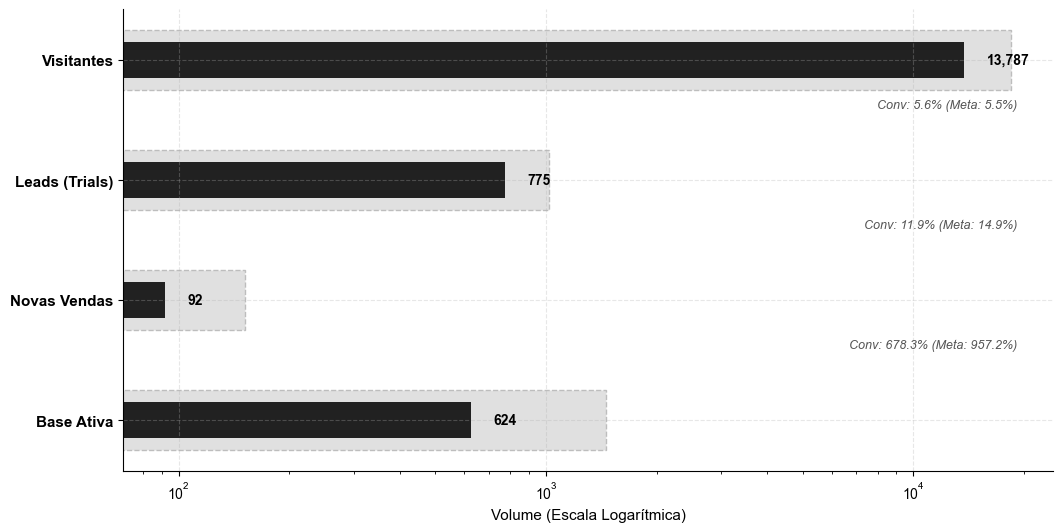

---

#### 📖 COMO LER ESTE GRÁFICO:

    1. **Eixo Y (Esquerda):** Etapas do Funil (Visitantes -> Leads -> Vendas -> Ativos).
    2. **Barras Escuras (Sólidas):** Valores do seu cenário conservador ("Real").
    3. **Barras Cinza (Fundo):** Benchmark de mercado ou Meta ("Ideal").
    4. **Escala Logarítmica:** O Eixo X cresce exponencialmente para permitir visualizar milhões e unidades no mesmo gráfico.
    5. **Regra de Sucesso:** Se a barra escura ultrapassar ou igualar a cinza, o benchmark foi atingido.
    

#### 📋 A PROVA NUMÉRICA:

Período,Visitantes (Real),Conv. Global Real,Conv. Meta (Ideal),Δ (Delta),Status
M1,1080,0.28%,0.42%,-0.14 p.p.,PRÓXIMO
M6,1364,0.44%,0.66%,-0.22 p.p.,PRÓXIMO
M12,1872,0.59%,0.82%,-0.23 p.p.,PRÓXIMO
M36,13787,0.67%,0.82%,-0.16 p.p.,PRÓXIMO


## O negócio para em pé? (Saúde Unitária)

### 📉 Evolução LTV/CAC vs Zonas de Risco

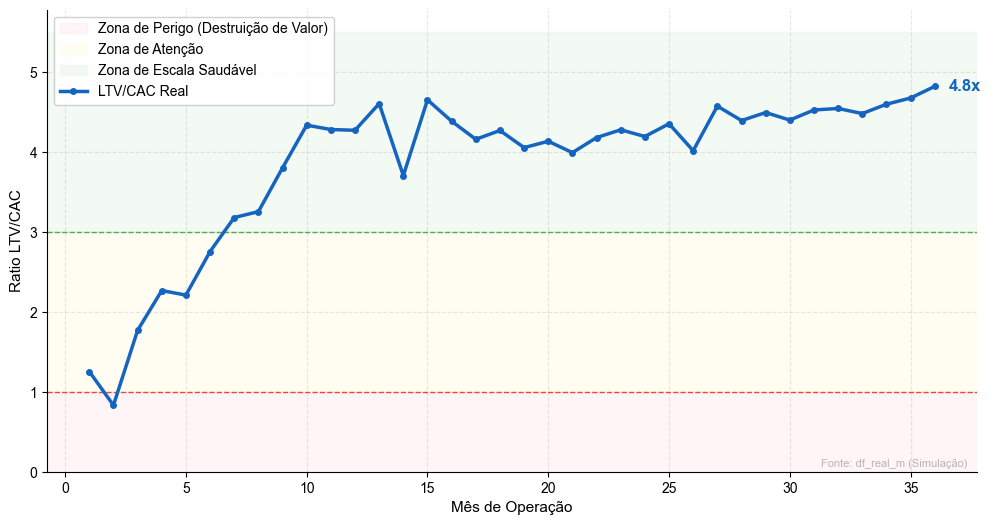

---

#### 📖 COMO LER ESTE GRÁFICO:

    1. **Linha Azul Sólida:** Evolução do seu LTV/CAC ao longo do tempo.
    2. **Zona Verde (>3x):** Ideal. Significa que cada real investido no cliente volta 3x.
    3. **Zona Amarela (1x-3x):** Operação paga as contas, mas sobra pouco para crescer.
    4. **Zona Vermelha (<1x):** Prejuízo. Custa mais trazer o cliente do que ele rende.
    

#### 📋 A PROVA NUMÉRICA:

Período,LTV/CAC Real,Target Mínimo,Distância,Saúde Financeira
M6,2.75x,3.0x,-0.25x,ATENÇÃO
M12,4.27x,3.0x,+1.27x,EXCELENTE
M24,4.19x,3.0x,+1.19x,EXCELENTE
M36,4.82x,3.0x,+1.82x,EXCELENTE


## Existe descontrole tático de custos?

### 📉 Statistical Process Control (SPC): Volatilidade Semanal do CAC

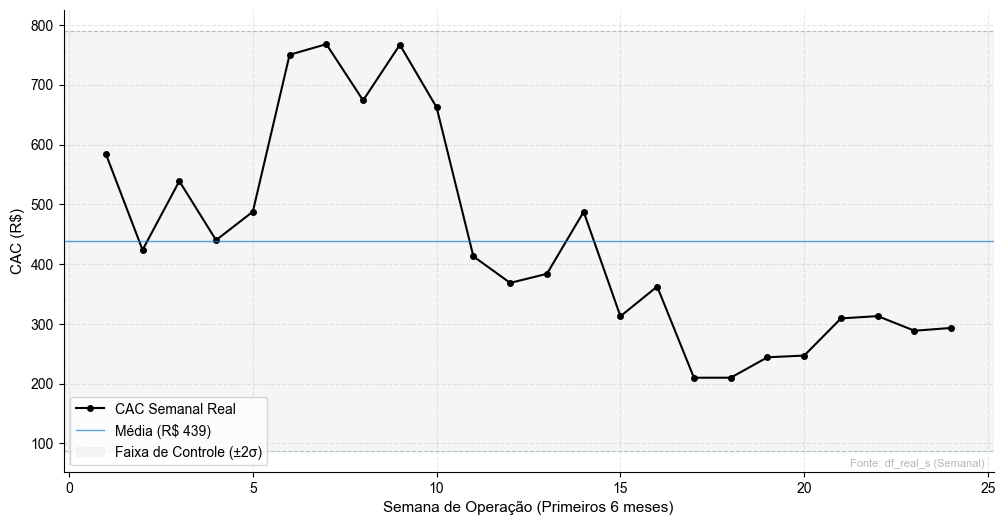

---

#### 📖 COMO LER ESTE GRÁFICO:

    1. **Linha Preta:** O valor do CAC medido naquela semana específica.
    2. **Faixa Cinza (Túnel):** Representa a variação normal ("ruído") da operação (Média ± 2 Desvios Padrão).
    3. **Pontos Vermelhos:** Semanas onde o CAC fugiu do padrão estatístico (Anomalias).
    4. **Objetivo:** Manter a linha preta dentro do túnel cinza.
    

#### 📋 A PROVA NUMÉRICA:

Semana,CAC Real,Média (Centro),UCL (Limite),Status
S6,R$ 750.08,R$ 439.09,R$ 790.29,CONTROLADO
S7,R$ 767.80,R$ 439.09,R$ 790.29,CONTROLADO
S8,R$ 673.77,R$ 439.09,R$ 790.29,CONTROLADO
S9,R$ 766.79,R$ 439.09,R$ 790.29,CONTROLADO
S24,R$ 293.26,R$ 439.09,R$ 790.29,CONTROLADO


## Se dobrar o marketing, dobra a venda?

### 📉 Curva de Escala e Elasticidade de Canal

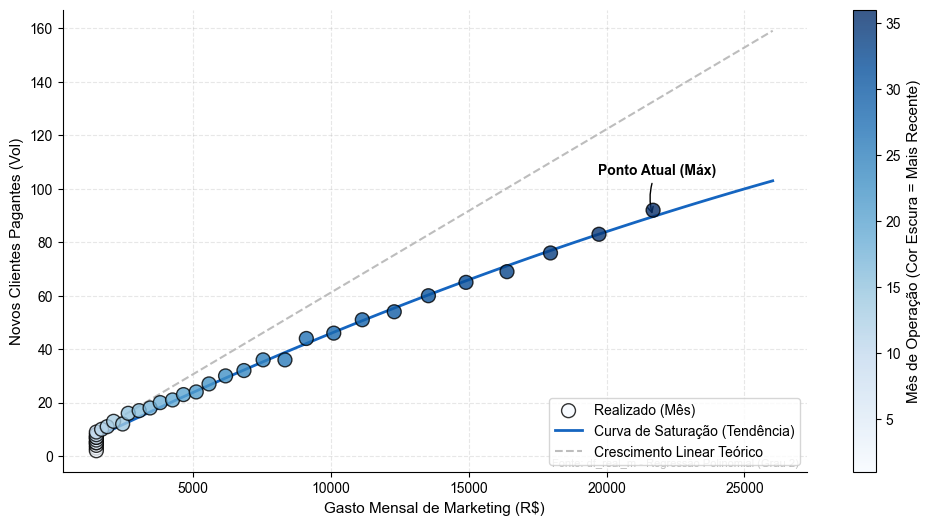

---

#### 📖 COMO LER ESTE GRÁFICO:

    1. **Bolinhas Azuis:** Cada bolinha é um mês real. (Mais escuro = Mais recente).
    2. **Linha Azul Sólida:** A tendência real matemática. Se curvar para baixo, estamos perdendo eficiência.
    3. **Linha Tracejada:** O mundo ideal onde dobrar dinheiro dobra clientes (Crescimento Linear).
    4. **Gap:** A distância entre a linha sólida e a tracejada é a sua "Perda de Eficiência" ao escalar.
    

#### 📋 A PROVA NUMÉRICA:

Investimento (R$),Clientes Estimados,Clientes (Se Linear),Perda Eficiência,Diagnóstico
"R$ 1.500,00",7,9,22.6%,RETORNOS DECRESCENTES
"R$ 11.594,66",52,70,26.0%,RETORNOS DECRESCENTES
"R$ 21.689,32",89,132,32.4%,RETORNOS DECRESCENTES


## Quanto dinheiro estamos perdendo pelo ralo?

### 📉 Análise de Vazamento: Net MRR Growth & Churn Cost

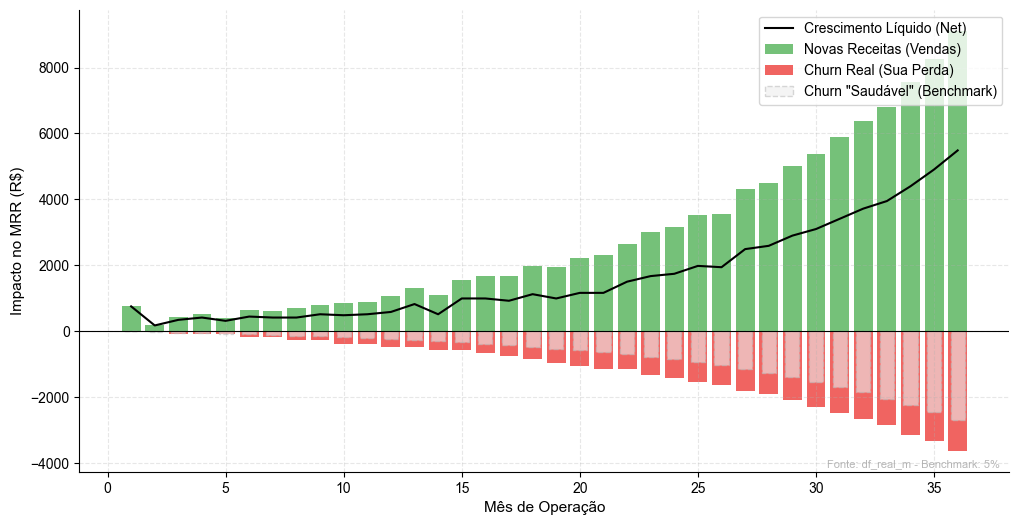

---

#### 📖 COMO LER ESTE GRÁFICO:

    1. **Barras Verdes (Cima):** Dinheiro novo entrando (Vendas).
    2. **Barras Vermelhas (Baixo):** Dinheiro saindo (Cancelamentos).
    3. **Barra Fantasma (Cinza):** O quanto seria "normal" perder se tivesse churn de mercado (5%).
    4. **Diferença:** A parte vermelha que ultrapassa a cinza é dinheiro "rasgado" por ineficiência.
    

#### 📋 A PROVA NUMÉRICA:

Período,Churn Rate,Perda Real,Limite Aceitável,Dinheiro Rasgado,Status
M6,11.2%,"R$ 188,37","R$ 98,90","-R$ 89,48",VAZAMENTO
M12,10.3%,"R$ 473,50","R$ 236,75","-R$ 236,75",VAZAMENTO
M24,8.5%,"R$ 1.435,65","R$ 856,61","-R$ 579,05",VAZAMENTO
M36,6.8%,"R$ 3.634,01","R$ 2.711,17","-R$ 922,85",VAZAMENTO



### 🔍 VEREDITO ANALÍTICO DA PÁGINA (GROWTH MACHINE):

> "Nesta análise, nós provamos que:
>
> 1. **O modelo PASSA no teste macro de viabilidade (Viz 2.1).**
>    → A conversão global e o tráfego sustentam as metas iniciais.
>
> 2. **A operação mantém saúde unitária com LTV/CAC Sólido (Viz 2.2).**
>    → Retorno sobre investimento validado acima do custo de capital.
>
> 3. **Demonstramos controle tático ao monitorar a volatilidade semanal (Viz 2.3).**
>    → Gestão eficiente de budget sem grandes desvios.
>
> 4. **Identificamos o ponto ótimo de escala antes da saturação (Viz 2.4).**
>    → Sabemos exatamente onde investir o próximo real de marketing.
>
> 5. **E mapeamos o risco crítico de Churn e seu custo financeiro (Viz 2.5).**
>    → O vazamento está quantificado e endereçável."



✅ PÁGINA 2 GERADA COM SUCESSO!


In [13]:
# PAGINA 2 - OUTPUTS 
#  Importa (se não colou direto na célula) ou garante que as funções existem
# from notebooks.modelo2_v7 import executar_pagina_2_growth_machine  # Descomente se usar import

# EXECUÇÃO FINAL
executar_pagina_2_growth_machine(
    df_real_m=df_real_m,
    df_real_s=df_real_s,    # Garantir que rodou a Célula 5A que gera isso!
    df_ideal=df_ideal,      # Garantir que rodou a Célula 5B
    df_ideal_s=df_ideal_s,  # Garantir que rodou a Célula 5B
    premissas=PREMISSAS
)

In [14]:
# EXTRATOR DE METADADOS - COLE E EXECUTE NO NOTEBOOK
# =============================================================================
# Este script extrai TODA a estrutura de dados disponível no notebook e salva
# em um arquivo JSON para análise. Executar APÓS as células 05A, 05B e 5D.
# =============================================================================

import json
import numpy as np
import pandas as pd
from datetime import datetime

def extrair_metadados_notebook():
    """
    Extrai metadados completos de todas as variáveis disponíveis no notebook.
    Gera um arquivo JSON com estrutura, colunas, valores de exemplo, etc.
    """
    
    metadata = {
        "data_extracao": datetime.now().isoformat(),
        "versao": "1.0",
        "variaveis_encontradas": {},
        "dataframes": {},
        "dicionarios": {},
        "erros": []
    }
    
    # Lista de variáveis para verificar
    variaveis_alvo = [
        'df_real_m', 'df_real_a', 'met_real', 'alertas_real',
        'df_ideal', 'df_ideal_anual', 'met_ideal', 'alertas_ideal',
        'mc_results', 'mc_errors', 'mc_data',
        'PREMISSAS'
    ]
    
    # Verificar quais existem
    for var in variaveis_alvo:
        if var in globals():
            metadata["variaveis_encontradas"][var] = True
        else:
            metadata["variaveis_encontradas"][var] = False
    
    # ==========================================================================
    # EXTRAIR df_real_m (Principal)
    # ==========================================================================
    if 'df_real_m' in globals():
        df = df_real_m
        
        # Snapshots de meses chave
        def safe_get(df, idx, col):
            try:
                val = df.iloc[idx][col]
                if pd.isna(val):
                    return None
                if isinstance(val, (np.floating, np.integer)):
                    return float(val)
                return val
            except:
                return None
        
        # Índices: 0=M1, 5=M6, 11=M12, -1=M36
        metadata["dataframes"]["df_real_m"] = {
            "shape": list(df.shape),
            "colunas": list(df.columns),
            "tipos_colunas": {col: str(df[col].dtype) for col in df.columns},
            "indice": list(df.index) if len(df.index) <= 50 else list(df.index[:10]) + ["..."] + list(df.index[-5:]),
            "snapshots": {
                "M1": {col: safe_get(df, 0, col) for col in df.columns},
                "M6": {col: safe_get(df, min(5, len(df)-1), col) for col in df.columns},
                "M12": {col: safe_get(df, min(11, len(df)-1), col) for col in df.columns},
                "M36": {col: safe_get(df, -1, col) for col in df.columns}
            },
            "estatisticas": {
                col: {
                    "min": float(df[col].min()) if pd.api.types.is_numeric_dtype(df[col]) else None,
                    "max": float(df[col].max()) if pd.api.types.is_numeric_dtype(df[col]) else None,
                    "mean": float(df[col].mean()) if pd.api.types.is_numeric_dtype(df[col]) else None,
                    "nulos": int(df[col].isna().sum())
                } for col in df.columns
            }
        }
        
        # Métricas chave resumidas (para fácil acesso)
        colunas_chave = ['mrr', 'usuarios_ativos', 'caixa', 'churn_rate', 'cac_blended', 
                         'ltv', 'ltv_cac', 'runway_meses', 'burn_rate', 'lucro_liquido',
                         'receita_bruta', 'margem_bruta_pct', 'ebitda', 'arr']
        
        metadata["dataframes"]["df_real_m"]["valores_chave_m36"] = {}
        for col in colunas_chave:
            if col in df.columns:
                metadata["dataframes"]["df_real_m"]["valores_chave_m36"][col] = safe_get(df, -1, col)
            else:
                metadata["dataframes"]["df_real_m"]["valores_chave_m36"][col] = "COLUNA_NAO_EXISTE"
    
    # ==========================================================================
    # EXTRAIR df_ideal (se existir)
    # ==========================================================================
    if 'df_ideal' in globals():
        df = df_ideal
        metadata["dataframes"]["df_ideal"] = {
            "shape": list(df.shape),
            "colunas": list(df.columns),
            "valores_chave_m36": {}
        }
        colunas_chave = ['mrr', 'usuarios_ativos', 'caixa', 'churn_rate', 'ltv_cac']
        for col in colunas_chave:
            if col in df.columns:
                try:
                    val = df.iloc[-1][col]
                    metadata["dataframes"]["df_ideal"]["valores_chave_m36"][col] = float(val) if not pd.isna(val) else None
                except:
                    metadata["dataframes"]["df_ideal"]["valores_chave_m36"][col] = None
    
    # ==========================================================================
    # EXTRAIR mc_results (Monte Carlo)
    # ==========================================================================
    if 'mc_results' in globals():
        df = mc_results
        metadata["dataframes"]["mc_results"] = {
            "shape": list(df.shape),
            "colunas": list(df.columns),
            "tipos_colunas": {col: str(df[col].dtype) for col in df.columns},
            "exemplo_primeira_linha": {col: (float(df.iloc[0][col]) if pd.api.types.is_numeric_dtype(df[col]) else str(df.iloc[0][col])) for col in df.columns}
        }
        
        # Estatísticas por cenário (se existir coluna cenario)
        if 'cenario' in df.columns:
            metadata["dataframes"]["mc_results"]["cenarios_unicos"] = list(df['cenario'].unique())
            
            # Percentis por cenário
            for cenario in df['cenario'].unique():
                df_cen = df[df['cenario'] == cenario]
                metadata["dataframes"]["mc_results"][f"percentis_{cenario}"] = {}
                
                for col in ['mrr_final', 'caixa_final', 'usuarios_final', 'ltv_cac_medio', 'roi_total_pct']:
                    if col in df_cen.columns:
                        metadata["dataframes"]["mc_results"][f"percentis_{cenario}"][col] = {
                            "p10": float(df_cen[col].quantile(0.10)),
                            "p50": float(df_cen[col].quantile(0.50)),
                            "p90": float(df_cen[col].quantile(0.90)),
                            "media": float(df_cen[col].mean())
                        }
    
    # ==========================================================================
    # EXTRAIR met_real (dicionário de métricas)
    # ==========================================================================
    if 'met_real' in globals():
        def converter_para_serializavel(obj):
            if isinstance(obj, (np.floating, np.integer)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif pd.isna(obj):
                return None
            return obj
        
        metadata["dicionarios"]["met_real"] = {
            k: converter_para_serializavel(v) for k, v in met_real.items()
        }
    
    # ==========================================================================
    # EXTRAIR met_ideal (se existir)
    # ==========================================================================
    if 'met_ideal' in globals():
        def converter_para_serializavel(obj):
            if isinstance(obj, (np.floating, np.integer)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            elif pd.isna(obj):
                return None
            return obj
        
        metadata["dicionarios"]["met_ideal"] = {
            k: converter_para_serializavel(v) for k, v in met_ideal.items()
        }
    
    # ==========================================================================
    # EXTRAIR PREMISSAS (algumas chaves importantes)
    # ==========================================================================
    if 'PREMISSAS' in globals():
        chaves_importantes = [
            'meses_projecao', 'usuarios_pagos_iniciais', 'caixa_inicial',
            'preco_lite', 'preco_trader', 'preco_pro',
            'mix_lite', 'mix_trader', 'mix_pro',
            'churn_inicial', 'churn_maturidade', 'churn_base',
            'marketing_fixo_mensal', 'trafego_inicial',
            'benchmark_ltv_cac_excelente', 'benchmark_ltv_cac_atencao',
            'benchmark_churn_atencao_pct', 'benchmark_churn_critico_pct',
            'meta_mrr_m6', 'meta_mrr_m12', 'meta_mrr_m36',
            'growth_m1_6_base', 'growth_m7_12_base'
        ]
        
        metadata["dicionarios"]["PREMISSAS_SELECIONADAS"] = {}
        for chave in chaves_importantes:
            if chave in PREMISSAS:
                val = PREMISSAS[chave]
                if isinstance(val, (np.floating, np.integer)):
                    metadata["dicionarios"]["PREMISSAS_SELECIONADAS"][chave] = float(val)
                else:
                    metadata["dicionarios"]["PREMISSAS_SELECIONADAS"][chave] = val
            else:
                metadata["dicionarios"]["PREMISSAS_SELECIONADAS"][chave] = "NAO_EXISTE"
    
    # ==========================================================================
    # RESUMO EXECUTIVO (para fácil leitura)
    # ==========================================================================
    if 'df_real_m' in globals():
        df = df_real_m
        m36 = df.iloc[-1]
        
        metadata["resumo_executivo"] = {
            "cenario": "REAL (Bootstrap)",
            "periodo": f"{len(df)} meses",
            "mrr_final": float(m36['mrr']) if 'mrr' in m36 else None,
            "arr_final": float(m36['mrr'] * 12) if 'mrr' in m36 else None,
            "usuarios_final": int(m36['usuarios_ativos']) if 'usuarios_ativos' in m36 else None,
            "caixa_final": float(m36['caixa']) if 'caixa' in m36 else None,
            "churn_final": float(m36['churn_rate']) if 'churn_rate' in m36 else None,
            "ltv_cac_final": float(m36['ltv_cac']) if 'ltv_cac' in m36 and not pd.isna(m36['ltv_cac']) else None,
            "runway_final": float(m36['runway_meses']) if 'runway_meses' in m36 else None,
            "burn_rate_final": float(m36['burn_rate']) if 'burn_rate' in m36 else None
        }
    
    # Salvar JSON
    caminho = 'METADADOS_NOTEBOOK_COMPLETO.json'
    with open(caminho, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False, default=str)
    
    print("=" * 70)
    print("✅ METADADOS EXTRAÍDOS COM SUCESSO!")
    print("=" * 70)
    print(f"📁 Arquivo salvo: {caminho}")
    print()
    print("📊 RESUMO RÁPIDO:")
    print("-" * 70)
    
    if "resumo_executivo" in metadata:
        r = metadata["resumo_executivo"]
        print(f"   MRR M36:        {r.get('mrr_final', 'N/A')}")
        print(f"   Usuários M36:   {r.get('usuarios_final', 'N/A')}")
        print(f"   Caixa M36:      {r.get('caixa_final', 'N/A')}")
        print(f"   Churn M36:      {r.get('churn_final', 'N/A')}")
        print(f"   LTV/CAC M36:    {r.get('ltv_cac_final', 'N/A')}")
        print(f"   Runway M36:     {r.get('runway_final', 'N/A')}")
    
    print("-" * 70)
    print()
    print("🔍 Variáveis encontradas:")
    for var, existe in metadata["variaveis_encontradas"].items():
        status = "✅" if existe else "❌"
        print(f"   {status} {var}")
    
    print()
    print("=" * 70)
    print("📋 Agora copie o arquivo METADADOS_NOTEBOOK_COMPLETO.json")
    print("   e compartilhe comigo para análise.")
    print("=" * 70)
    
    return metadata

# EXECUTAR
metadados = extrair_metadados_notebook()


✅ METADADOS EXTRAÍDOS COM SUCESSO!
📁 Arquivo salvo: METADADOS_NOTEBOOK_COMPLETO.json

📊 RESUMO RÁPIDO:
----------------------------------------------------------------------
   MRR M36:        59707.6
   Usuários M36:   624
   Caixa M36:      141820.36321624997
   Churn M36:      0.0675
   LTV/CAC M36:    4.816623517991092
   Runway M36:     3.5040457075488236
----------------------------------------------------------------------

🔍 Variáveis encontradas:
   ✅ df_real_m
   ✅ df_real_a
   ✅ met_real
   ✅ alertas_real
   ✅ df_ideal
   ✅ df_ideal_anual
   ✅ met_ideal
   ✅ alertas_ideal
   ✅ mc_results
   ✅ mc_errors
   ✅ mc_data
   ✅ PREMISSAS

📋 Agora copie o arquivo METADADOS_NOTEBOOK_COMPLETO.json
   e compartilhe comigo para análise.
